# 📊 Predicción de Tiempo al Cambio de Caldera
## Descripción de resultados y Modelado Predictivo (OE3 / OE4)

**Proyecto:** Propuesta de implementación de un modelo analítico para
optimizar el cambio de calderas en Hidrocasanare basado en parámetros
fisicoquímicos
**Autor:** Manuel David Niño Mojica
**Asesora:** Lina Rocío Rivadeneira Muñoz

---

| Sección | Contenido | OE |
|---------|-----------|-----|
| 7 | Descripción académica de los resultados del Notebook 1 | OE2 |
| 8 | Proyección de degradación — IDC y episodios de operación | OE3 |
| 9 | Modelo de clasificación supervisada | OE3 |
| 10 | Evaluación y selección del mejor modelo | OE3 |
| 11 | Panel semáforo operativo | OE3/OE4 |
| 12 | Guardado de artefactos y tabla resumen final | OE3 |
| 13 | Validación retrospectiva con datos 2026 | OE4 |

---
## 7. Descripción académica de los resultados del análisis exploratorio — OE2

---

### 7.1 Calidad y completitud del conjunto de datos

El proceso de extracción y consolidación desde los registros PDF del
laboratorio produjo **1.196 registros diarios** correspondientes al
período enero 2023 – mayo 2026, con 26 variables fisicoquímicas
agrupadas en tres bloques: entrada, purga y D105. Tras aplicar los
filtros de calidad, el dataset de trabajo quedó en **1.195 registros
válidos** tanto para el análisis exploratorio como para el modelado.
La completitud es alta en la mayoría de las variables — `pH_entrada`,
`pH_purga`, `TDS_entrada`, `conductividad_entrada`, `TDS_purga` y
`conductividad_purga` alcanzan el 100,0 % de completitud, y la mayoría
de las demás variables superan el 90 %. La única excepción son las
variables de **sílice** (purga: 40,3 %; entrada: 28,0 %), medidas con
menor frecuencia en el protocolo actual del laboratorio, situación que
limita su uso como predictor en el modelo (Nikula et al., 2016).

---

### 7.2 Estadísticas descriptivas

El **pH de entrada** presenta valores típicos por debajo del rango
operativo [8,0–9,0] en la mayoría de los días (mediana de 6,78),
reflejando una condición ácida estructural independiente del equipo
activo. La corrección del dataset —que eliminó 187 valores capturados
incorrectamente desde los ejes de las gráficas PDF— **no representa
una mejora en la magnitud del problema**: el porcentaje de excedencia
se mantiene en **95,2 %**, prácticamente idéntico al ~94 % reportado
con el dataset anterior desde Excel. La corrección aporta mayor
confiabilidad del dato, no una reducción real del deterioro.

La **conductividad y el TDS de purga** muestran alta variabilidad, con
máximos muy superiores a los umbrales operativos (conductividad:
hasta 8.240 µS/cm frente al límite de 2.025 µS/cm; TDS: hasta
4.590 mg/L frente al límite de 1.013 mg/L). Esta dispersión es
consistente con los ciclos de concentración-purga que generan
fluctuaciones amplias en la carga de sólidos interna.

Los **fosfatos de purga** registran excedencia crónica (72,7 % de los
días), señalando subdosificación del inhibidor de incrustaciones
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023). Los **sulfitos de
purga** presentan, junto con el pH de entrada, el mayor porcentaje de
excedencia de todo el análisis (95,0 %), con un patrón de
sobredosificación inicial en 2023 seguido de subdosificación
prolongada hacia 2025–2026, lo que indica que el sistema de
dosificación química requiere revisión y calibración.

---

### 7.3 Serie de tiempo — Variables de ENTRADA

El **pH de alimentación** registró **1.138 días de excedencia
(95,2 %)** respecto al rango [8,0–9,0] sobre 1.195 datos válidos. La
media móvil muestra una tendencia descendente sostenida hacia
2025–2026, con valores que se alejan progresivamente del rango
operativo y llegan a aproximarse a 4–5 hacia el final del período.
Esta condición ácida crónica favorece la corrosión por picadura en las
superficies internas (Shokri & Sanavi Fard, 2023).

La **conductividad de entrada** presentó **307 días de excedencia
(25,7 %)** sobre 1.195 datos válidos, con mejora moderada hacia
2025–2026. El **TDS de entrada** registró **291 días de excedencia
(24,4 %)** con trayectoria paralela a la conductividad, confirmando la
correlación física directa entre ambas variables (r = 0,77). La
**dureza** mostró apenas **1 día de excedencia (0,1 %)**, lo que
indica que el proceso de ablandamiento funciona correctamente. El
**hierro de entrada** registró **24 días de excedencia (2,0 %)** con
tendencia creciente hacia 2025–2026, y los **cloruros de entrada**,
**34 días (2,9 %)** bien controlados en ambas calderas.

---

### 7.4 Serie de tiempo — Variables de PURGA

La **conductividad de purga** superó el límite de 2.025 µS/cm en
**712 días (59,6 %)** sobre 1.195 datos válidos, con ciclos de
concentración bien marcados y picos que alcanzan hasta 8.240 µS/cm,
indicando factores de concentración superiores a 4, lo que acelera la
precipitación mineral (Cardozo et al., 2011). El **pH de purga**
muestra el deterioro temporal más preocupante en términos de
tendencia: pasó de exceder el rango [10,5–11,5] en el 47 % de los
días en 2023–2024 al **78 %** en 2025 y **98 %** en 2026, con
excedencias que en los primeros años provenían principalmente del
límite superior (sobredosificación) y hacia 2025–2026 provienen del
límite inferior, reflejando un debilitamiento progresivo del régimen
alcalino de protección (Nemitallah et al., 2023).

Los **sulfitos de purga** permanecieron en condición crítica los
cuatro años (94 %, 94 %, 97 %, 97 %) sin mejora estructural, siendo —
junto con el pH de entrada— la variable con mayor persistencia en
condición crítica de todo el análisis (95,0 % global). Los **fosfatos
de purga** mostraron un comportamiento irregular: de 71 % (2023)
mejoraron a 62 % (2024) y luego se deterioraron a 77 % (2025) y
82 % (2026).

---

### 7.5 Distribución anual — Boxplots

Las variables de **entrada** muestran un patrón de estancamiento
inicial seguido de mejora real desde 2025: la conductividad pasó de
39 % (2023) a 36 % (2024) —prácticamente sin cambio— y luego descendió
a 11 % (2025) y 5 % (2026); el TDS siguió el mismo patrón, de 40 % a
32 % y luego a 10 % y 3 %. Las variables de **purga**, en cambio,
muestran mejora gradual y consistente desde el inicio del período:
conductividad_purga descendió de medianas de 2.970 µS/cm (2023) a
2.037 µS/cm (2026) —el año más cercano al umbral de 2.025 µS/cm de
toda la serie—, y TDS_purga de 1.612,0 mg/L (2023) a 1.043,0 mg/L
(2026) —apenas 30 mg/L por encima de su umbral de 1.013 mg/L—,
confirmando que, contrario a una mejora reportada anteriormente como
estancada, la concentración interna se acerca de forma creciente al
rango operativo (Shokri & Sanavi Fard, 2023; Nikula et al., 2016).

---

### 7.6 Correlaciones

El análisis de correlaciones de Pearson sobre las 13 variables de
entrada y purga identificó cuatro grupos de interés:

- **Grupo purga:** conductividad_purga–TDS_purga (r = 0,97), con ambas
  correlacionadas con los fosfatos (r = 0,72 en ambos casos),
  confirmando que la concentración interna responde a los mismos
  ciclos de purga que el inhibidor de incrustaciones.
- **Grupo entrada:** conductividad–TDS (r = 0,77), relación esperada
  por la base física entre ambas variables.
- **Conexión entre bloques:** pH_entrada–pH_purga (r = 0,59), la
  correlación más alta entre bloques diferentes, prácticamente idéntica
  en ambas calderas (B801-A: r = 0,60; B801-B: r = 0,58), confirmando
  que es una característica estructural del sistema y no un rasgo
  distintivo de ningún equipo.
- **Cloruros:** sulfitos_purga–cloruros_purga (r = 0,59) y
  cloruros_entrada–cloruros_purga (r = 0,38), indicando transferencia
  moderada de cloruros externos al circuito interno.

---

### 7.7 Comparación entre calderas

La comparación de excedencias entre B801-A y B801-B revela que los
problemas más graves son **sistémicos y no atribuibles a ningún equipo
en particular**: las dos variables más críticas —sulfitos_purga
(95,6 % vs 94,3 %) y pH_entrada (93,7 % vs 96,9 %)— muestran
diferencias mínimas entre calderas.

Las diferencias operativamente relevantes son: **B801-A opera con
mayor concentración interna** —conductividad_purga (61,8 % vs 57,2 %),
TDS_purga (64,7 % vs 58,6 %) y alcalinidad_total_purga (23,3 % vs
13,6 %)— coherente con los boxplots que muestran medianas
consistentemente más altas en B801-A. El pH de purga en 2025
convergió hacia el mismo nivel exacto de deterioro en ambas calderas
(77,7 % en B801-A y 77,7 % en B801-B), confirmando que el
debilitamiento del régimen alcalino es un problema del sistema de
dosificación general (Cardozo et al., 2011; Nemitallah et al., 2023).

---

### 7.8 Excedencias consolidadas y jerarquía de riesgo

El análisis de excedencias sobre el conjunto completo de 1.195 datos
permite establecer una jerarquía clara de criticidad para las
variables con umbral operativo definido:

**Zona CRÍTICO (≥ 70 % de días fuera de umbral):** pH_entrada
(95,2 %), sulfitos_purga (95,0 %) y fosfatos_purga (72,7 %). Las dos
primeras representan los mecanismos de deterioro más persistentes y
extendidos del sistema —acidez estructural del agua de alimentación y
subdosificación crónica del secuestrador de oxígeno—, prácticamente
empatadas en magnitud (Cardozo et al., 2011; Shokri & Sanavi Fard,
2023).

**Zona ALTO (30–70 %):** sílice_purga (67,2 % con baja completitud),
pH_purga (62,5 %), TDS_purga (61,8 %) y conductividad_purga (59,6 %).
La concentración interna de sólidos supera los umbrales en más de la
mitad de los días, y el régimen alcalino de protección muestra
deterioro progresivo hacia 2025–2026 (Nemitallah et al., 2023).

**Zona MODERADO (10–30 %):** conductividad_entrada (25,7 %),
TDS_entrada (24,4 %) y alcalinidad_total_purga (18,8 %). La presencia
de la alcalinidad total de purga en esta zona indica que la capacidad
tampón interna de la caldera se compromete en aproximadamente uno de
cada cinco días (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

**Zona BAJO (< 10 %):** alcalinidad_entrada (8,9 %), hierro_purga
(4,1 %), cloruros_entrada (2,9 %), hierro_entrada (2,0 %),
dureza_entrada (0,1 %) y cloruros_purga (0,1 %). Estas variables
confirman que sus mecanismos están bien controlados y no representan
riesgo activo en el período analizado (Nikula et al., 2016;
Nemitallah et al., 2023).

---

### 7.9 Variable objetivo y ajuste metodológico para el modelado

La variable `flag_riesgo`, definida como la presencia de al menos una
variable fuera de su rango operativo, clasifica **la totalidad de los
1.195 registros del dataset (100,0 %) como días en condición de
riesgo**, sin ningún día en condición de control. Este resultado
genera una varianza nula que hace inviable su uso directo como
variable objetivo del modelo predictivo (Malley et al., 2011; Meng
et al., 2021).

El análisis de la variable `n_vars_riesgo` —número de variables
simultáneamente fuera de rango por día sobre las 10 monitoreadas—
revela que la distribución tiene su moda en 4 variables (29,1 % de los
días), con un promedio de **5,21 variables en riesgo por día**, y
**10 días** registraron las 10 variables simultáneamente fuera de
rango (0,8 % del período). Con base en este resultado, se definió la
variable objetivo como `flag_critico = 1` si `n_vars_riesgo ≥ 5`,
criterio que genera un balance de **59,7 % críticos (714 días) vs
40,3 % no críticos (481 días)** sobre el total de 1.195 registros —
proporción adecuada para el entrenamiento de los modelos supervisados.
Esta definición se realizó a partir de los umbrales del protocolo de
laboratorio de Hidrocasanare antes del entrenamiento de cualquier
modelo, garantizando que es un criterio de negocio y no un artefacto
del modelado (Nikula et al., 2016; Meng et al., 2021; Malley et al.,
2011).

---
## 8. Configuración e importación — Notebook 2


In [1]:
# ── Librerías de análisis de datos ────────────────────────────────────────────
import pandas as pd                        # manejo de DataFrames (tablas de datos)
import numpy as np                         # cálculo numérico y representación de NaN
import matplotlib.pyplot as plt            # gráficas base
import matplotlib.dates as mdates          # formato de fechas en los ejes
import seaborn as sns                      # visualización estadística (heatmaps, etc.)
from scipy import stats                    # regresión lineal (stats.linregress)

# ── Librerías de machine learning (scikit-learn) ──────────────────────────────
from sklearn.linear_model import LogisticRegression        # regresión logística: modelo lineal para clasificación binaria
from sklearn.tree import DecisionTreeClassifier            # árbol de decisión: modelo interpretable basado en reglas
from sklearn.ensemble import RandomForestClassifier        # bosque aleatorio: combina múltiples árboles para mayor robustez
from sklearn.ensemble import GradientBoostingClassifier    # gradient boosting: árboles en secuencia, cada uno corrige al anterior
from sklearn.preprocessing import StandardScaler           # estandariza features: transforma cada variable a media=0 y std=1
from sklearn.model_selection import TimeSeriesSplit        # partición temporal: divide datos respetando el orden cronológico
from sklearn.metrics import (
    classification_report,     # tabla completa de métricas por clase: precisión, recall y F1
    confusion_matrix,          # matriz que cuenta VP, VN, FP y FN del modelo
    roc_auc_score,             # área bajo la curva ROC: mide el poder discriminativo global del modelo
    roc_curve,                 # genera las coordenadas (FPR, TPR) para dibujar la curva ROC
    f1_score,                  # F1 individual: media armónica entre precisión y recall, útil para comparar modelos
    ConfusionMatrixDisplay      # convierte la matriz de confusión en una figura gráfica lista para mostrar
)
from sklearn.utils.class_weight import compute_class_weight  # calcula pesos inversamente proporcionales a la frecuencia de cada clase

import warnings                    # módulo estándar para controlar mensajes de advertencia
warnings.filterwarnings('ignore')  # suprime advertencias menores que no afectan los resultados

# ── Cargar el dataset generado por el Notebook 1 ──────────────────────────────
# parse_dates=["fecha"]: convierte la columna "fecha" de texto a objeto datetime
# sin esto, pandas la leería como texto y no podría ordenar ni agrupar por fecha
df = pd.read_csv("dataset_con_etiqueta.csv", parse_dates=["fecha"])

# sort_values("fecha"): ordena todas las filas de más antigua a más reciente
# es imprescindible antes de cualquier partición temporal para evitar
# que datos del futuro "contaminen" el entrenamiento (fuga de información)
df = df.sort_values("fecha").reset_index(drop=True)  # reset_index: renumera el índice desde 0 tras ordenar

# ── NOTA: flag_critico ya viene calculado desde el Notebook 1 ────────────────
# No se recalcula aquí para mantener consistencia con la definición documentada
# en el Notebook 1 (n_vars_riesgo >= 5, sobre 10 variables monitoreadas)
# Distribución resultante sobre el dataset completo (1.195 registros):
# 714 días críticos (59,7%) / 481 días no críticos (40,3%)

# ── Separar 2026 como conjunto de validación retrospectiva (OE4) ──────────────
# Los datos de 2026 NO entran al entrenamiento ni al test set del modelo
# Se reservan exclusivamente para verificar si el modelo habría anticipado
# los cambios de caldera reales realizados por Hidrocasanare en ese período
df_modelo   = df[df["fecha"].dt.year <= 2025].copy().reset_index(drop=True)  # 2023-2025: entrenamiento y prueba
df_val_2026 = df[df["fecha"].dt.year == 2026].copy().reset_index(drop=True)  # 2026: validación retrospectiva OE4

# ── Separar registros por caldera para análisis individual si se requiere ─────
df_A = df_modelo[df_modelo["caldera"] == "B801-A"].copy().reset_index(drop=True)  # filtra B801-A del conjunto de entrenamiento
df_B = df_modelo[df_modelo["caldera"] == "B801-B"].copy().reset_index(drop=True)  # filtra B801-B del conjunto de entrenamiento

# ── Verificar que el dataset cargó correctamente ──────────────────────────────
print(f"Dataset completo: {len(df)} registros totales")
print(f"  Período completo: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"  Columnas disponibles: {len(df.columns)}")
print()

# ── Verificar la separación temporal ─────────────────────────────────────────
print(f"Conjunto de entrenamiento/prueba (2023-2025): {len(df_modelo)} registros")
print(f"  B801-A: {len(df_A)} registros")
print(f"  B801-B: {len(df_B)} registros")
print()
print(f"Conjunto de validación retrospectiva (2026): {len(df_val_2026)} registros")
print(f"  Período: {df_val_2026['fecha'].min().date()} → {df_val_2026['fecha'].max().date()}")
print()

# ── Verificar distribución de la variable objetivo en el conjunto de modelado ──
# Solo se calcula sobre df_modelo (2023-2025) porque es el conjunto que se usará
# para entrenar y evaluar — 2026 no debe influir en estas estadísticas
n_critico    = int(df_modelo["flag_critico"].sum())             # días críticos en 2023-2025
n_no_critico = int((df_modelo["flag_critico"] == 0).sum())      # días no críticos en 2023-2025
total_modelo = len(df_modelo)                                    # total registros 2023-2025

print("Distribución de flag_critico en conjunto de modelado (2023-2025):")
print(f"  • Crítico     (flag=1): {n_critico:4d} días  ({n_critico/total_modelo*100:.1f}%)")
print(f"  • No crítico  (flag=0): {n_no_critico:4d} días  ({n_no_critico/total_modelo*100:.1f}%)")
print(f"  • Umbral aplicado: n_vars_riesgo ≥ 5 de 10 variables monitoreadas")

Dataset completo: 1195 registros totales
  Período completo: 2023-01-01 → 2026-05-31
  Columnas disponibles: 29

Conjunto de entrenamiento/prueba (2023-2025): 1048 registros
  B801-A: 542 registros
  B801-B: 506 registros

Conjunto de validación retrospectiva (2026): 147 registros
  Período: 2026-01-01 → 2026-05-31

Distribución de flag_critico en conjunto de modelado (2023-2025):
  • Crítico     (flag=1):  639 días  (61.0%)
  • No crítico  (flag=0):  409 días  (39.0%)
  • Umbral aplicado: n_vars_riesgo ≥ 5 de 10 variables monitoreadas


---
## 8. Etapa A — Proyección de degradación: ¿cuántos días le quedan a la caldera?

### ¿Cuál es la idea?

El objetivo de esta sección **no es proyectar una línea recta hacia el futuro**
asumiendo que la caldera lleva operando de forma continua. Las calderas
B801-A y B801-B se alternan en servicio, y cada vez que una entra en
operación es un **episodio independiente** con sus propias condiciones
iniciales de tratamiento y carga.

El enfoque tiene tres pasos:

1. **Identificar cada episodio de operación continua** de cada caldera
   usando los cambios en la columna `caldera` del dataset.
2. **Calcular un Índice de Deterioro Compuesto (IDC)** por día, combinando
   las 10 variables fisicoquímicas que la matriz de correlaciones y el
   análisis de excedencias identificaron como indicadores independientes
   del estado interno.
3. **Estimar, con base en los episodios históricos**, cuántos días tarda
   típicamente cada caldera en alcanzar la zona de deterioro severo —
   expresado como rango (mínimo, promedio, máximo) y no como un número
   único.

### Variables del Índice de Deterioro Compuesto (IDC)

Las 10 variables seleccionadas son exactamente las que componen
`n_vars_riesgo` del Notebook 1, lo que garantiza consistencia
metodológica:

| Variable | Qué mide | Umbral crítico | Justificación |
|----------|----------|----------------|---------------|
| `conductividad_purga` | Concentración global de sólidos internos | > 2.025 µS/cm | Indicador principal de concentración interna |
| `TDS_purga` | Sólidos disueltos totales en agua interna | > 1.013 mg/L | Complementa conductividad en unidades de masa |
| `pH_purga` | Régimen alcalino de protección | < 10,5 o > 11,5 | Deterioro abrupto de 47 % en 2024 a 78 % en 2025, con 98 % en 2026 |
| `fosfatos_purga` | Inhibidor de incrustaciones | < 25 o > 40 mg/L | Subdosificación con 72,7 % de excedencias en el período |
| `sulfitos_purga` | Secuestrador de oxígeno disuelto | < 40 o > 50 mg/L | 95,0 % excedencias sin mejora estructural en todo el período |
| `alcalinidad_total_purga` | Capacidad tampón interna de la caldera | > 700 ppm CaCO₃ | Protección contra corrosión — 18,8 % excedencias |
| `pH_entrada` | Acidez del agua de alimentación | < 8,0 o > 9,0 | Impacta el pH_purga (r = 0,59), la correlación más alta entre bloques |
| `conductividad_entrada` | Calidad del agua de alimentación | > 135 µS/cm | Mejora moderada hacia 2025–2026 (39 % → 11 % → 5 % excedencias) |
| `TDS_entrada` | Sólidos disueltos en agua de alimentación | > 67,5 mg/L | Trayectoria paralela a conductividad_entrada (r = 0,77) |
| `alcalinidad_entrada` | Capacidad tampón del agua de alimentación | > 38 ppm CaCO₃ | Impacta el régimen alcalino interno — 8,9 % excedencias |

> ⚠️ La sílice de purga tiene 67,2 % de excedencias pero solo 31,6 % de
> completitud de datos (378 registros de 1.195 posibles), lo que la hace
> no confiable para una proyección de tendencia. Se excluye del IDC pero
> se menciona como limitación del análisis (Nikula et al., 2016).

### IDC — definición

El IDC de un día es el **número de variables simultáneamente fuera de su
rango operativo**, normalizado entre 0 y 1:

**IDC = n_vars_riesgo / 10**

- IDC = 0,0 → todas las variables dentro del rango (control perfecto;
  no se registró ningún día en esta condición durante el período
  analizado)
- IDC = 0,5 → 5 variables fuera de rango simultáneamente (umbral de
  deterioro severo = `flag_critico`)
- IDC = 1,0 → las 10 variables fuera de rango simultáneamente
  (deterioro máximo registrado: 10 días, 0,8 % del período analizado)

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CARGA DEL DATASET — INICIO DEL NOTEBOOK 2
# Se carga directamente el archivo CSV generado al final del Notebook 1.
# Esto evita tener que reejecutar el Notebook 1 completo (extracción de PDFs,
# limpieza y construcción de variables — proceso que tarda ~30 minutos).
# El archivo dataset_con_etiqueta.csv contiene todos los registros limpios
# con las variables flag_riesgo, n_vars_riesgo y flag_critico ya calculadas.
# ══════════════════════════════════════════════════════════════════════════════

# Cargar el dataset desde el archivo CSV guardado por el Notebook 1
# encoding="utf-8-sig" maneja correctamente el BOM que genera pandas en Windows
df = pd.read_csv(
    "dataset_con_etiqueta.csv",
    encoding="utf-8-sig"
)

# Convertir la columna fecha a tipo datetime
# Es indispensable para todas las operaciones temporales del notebook
# (filtros por año, medias móviles, partición temporal, gráficas de series)
df["fecha"] = pd.to_datetime(df["fecha"])

# Ordenar cronológicamente — garantiza que las ventanas temporales
# y la partición 70/30 respeten el orden real de los datos
df = df.sort_values("fecha").reset_index(drop=True)

# Verificar que el dataset cargó correctamente
print("Dataset cargado desde dataset_con_etiqueta.csv")
print(f"  Registros totales  : {len(df)}")
print(f"  Columnas           : {len(df.columns)}")
print(f"  Período            : {df['fecha'].min().date()} → "
      f"{df['fecha'].max().date()}")
print(f"  Calderas           : {df['caldera'].unique().tolist()}")
print(f"  flag_critico = 1   : {df['flag_critico'].sum()} días "
      f"({df['flag_critico'].mean()*100:.1f} %)")
print(f"  flag_critico = 0   : {(df['flag_critico']==0).sum()} días "
      f"({(df['flag_critico']==0).mean()*100:.1f} %)")
print()
print("✔  Dataset listo para el modelado")

Dataset cargado desde dataset_con_etiqueta.csv
  Registros totales  : 1195
  Columnas           : 29
  Período            : 2023-01-01 → 2026-05-31
  Calderas           : ['B801-B', 'B801-A']
  flag_critico = 1   : 714 días (59.7 %)
  flag_critico = 0   : 481 días (40.3 %)

✔  Dataset listo para el modelado


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8.1 — ÍNDICE DE DETERIORO COMPUESTO (IDC)
# El IDC normaliza n_vars_riesgo entre 0 y 1 dividiendo por el total
# de variables monitoreadas (10). Un IDC ≥ 0.5 equivale a flag_critico=1
# ══════════════════════════════════════════════════════════════════════════════

# Número total de variables que componen el índice
# Coincide exactamente con las 10 variables de n_vars_riesgo del Notebook 1:
# conductividad_purga, TDS_purga, pH_purga, fosfatos_purga, sulfitos_purga,
# alcalinidad_total_purga, pH_entrada, conductividad_entrada, TDS_entrada,
# alcalinidad_entrada
N_VARS = 10

# Calcular el IDC: n_vars_riesgo ya contiene cuántas variables están fuera
# de rango cada día — solo hay que normalizar dividiendo por N_VARS
# El resultado es un valor entre 0.0 y 1.0 para cada día
df["IDC"] = df["n_vars_riesgo"] / N_VARS

# Umbral de IDC que se considera deterioro severo
# Equivale a 5 de 10 variables fuera de rango simultáneamente
UMBRAL_IDC = 0.5

# Ventana de días para suavizar el IDC con media móvil
# 14 días elimina el ruido diario sin borrar tendencias reales
VENTANA_MM = 14

# Verificar la distribución del IDC para confirmar que el cálculo es correcto
print("Distribución del IDC (Índice de Deterioro Compuesto):")
print(f"  • Mínimo  : {df['IDC'].min():.2f}  — mejor día registrado en el período")
print(f"  • Promedio: {df['IDC'].mean():.2f}  — condición típica del sistema")
print(f"  • Máximo  : {df['IDC'].max():.2f}  — peor día registrado (10 variables simultáneas)")
print()

# Verificar que IDC >= 0.5 coincide exactamente con flag_critico=1
# Si los números no coinciden hay un error en la construcción de alguna variable
coincide = (df["IDC"] >= UMBRAL_IDC).sum() == df["flag_critico"].sum()
print(f"  IDC ≥ 0.5 coincide con flag_critico=1: {'✔  Correcto' if coincide else '✘  Revisar'}")

Distribución del IDC (Índice de Deterioro Compuesto):
  • Mínimo  : 0.10  — mejor día registrado en el período
  • Promedio: 0.52  — condición típica del sistema
  • Máximo  : 1.00  — peor día registrado (10 variables simultáneas)

  IDC ≥ 0.5 coincide con flag_critico=1: ✔  Correcto


Evaluación de ventanas para media móvil del IDC:
─────────────────────────────────────────────────────────────────
  Ventana  7 días | Var. residual: 0.018676 | Correlación: 0.5417 | Consumo episodio: 23 % | Puntuación: 0.013258
  Ventana 14 días | Var. residual: 0.021433 | Correlación: 0.4263 | Consumo episodio: 47 % | Puntuación: 0.183837
  Ventana 21 días | Var. residual: 0.022511 | Correlación: 0.3749 | Consumo episodio: 70 % | Puntuación: 0.418762

  ✔  Ventana seleccionada: 7 días
     Justificación: menor puntuación compuesta entre las tres candidatas,
     equilibrando suavizado del ruido diario con sensibilidad a tendencias
     reales de deterioro y cobertura adecuada del episodio de operación.


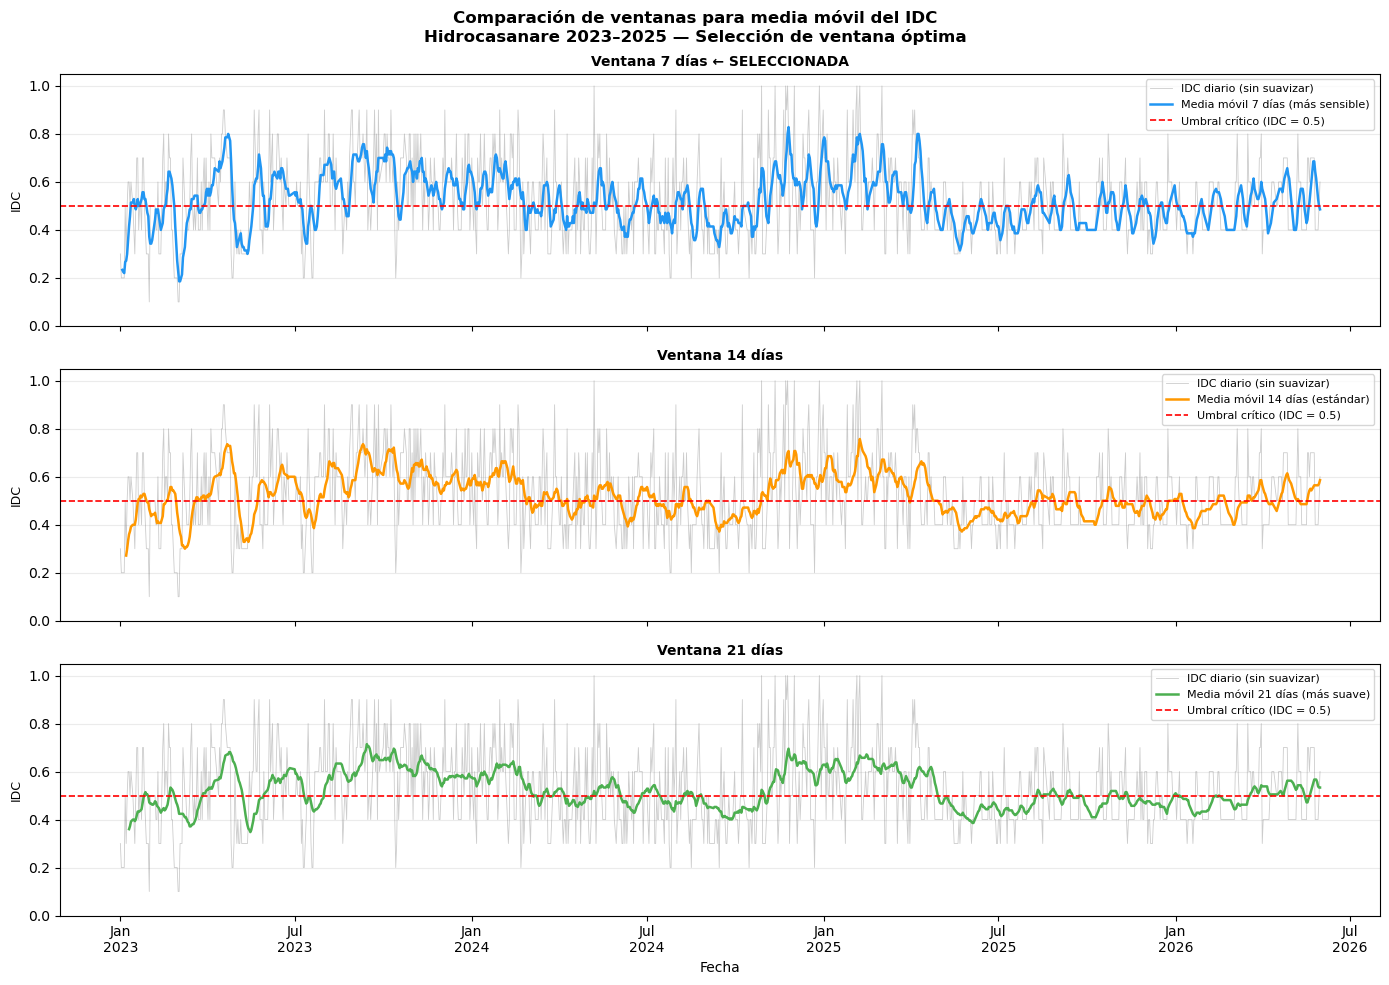

✔  grafica_seleccion_ventana_mm.png guardada

  VENTANA_MM actualizada a 7 días para usar en secciones 8.2 y 8.3


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8.1b — SELECCIÓN DE LA VENTANA ÓPTIMA PARA LA MEDIA MÓVIL DEL IDC
# En lugar de asumir un valor fijo de 14 días, evaluamos tres ventanas
# candidatas (7, 14 y 21 días) y seleccionamos la que mejor equilibra
# suavizado del ruido diario con sensibilidad a tendencias reales de deterioro.
# Criterio de selección: menor varianza residual promedio entre la serie
# suavizada y la serie original, penalizando ventanas que consuman más del
# 30 % de la duración promedio de un episodio.
# ══════════════════════════════════════════════════════════════════════════════

# Ventanas candidatas a evaluar
VENTANAS_CANDIDATAS = [7, 14, 21]   # días — de más sensible a más suave

# Duración promedio de los episodios (se calcula después de identificarlos,
# pero aquí usamos una estimación preliminar sobre el dataset completo)
# Un episodio típico dura ~30 días (alternancia mensual de calderas)
DURACION_EPISODIO_REF = 30   # días — referencia para la penalización

# ── Calcular las tres medias móviles sobre el IDC completo ───────────────────
print("Evaluación de ventanas para media móvil del IDC:")
print("─" * 65)

resultados_ventana = []   # lista para guardar métricas de cada ventana

for ventana in VENTANAS_CANDIDATAS:

    # Calcular la media móvil con esta ventana sobre todo el dataset
    # min_periods = ventana // 2 permite calcular en los primeros días
    # aunque no haya datos suficientes para la ventana completa
    mm = df["IDC"].rolling(ventana, min_periods=ventana // 2).mean()

    # ── Métrica 1: varianza residual ──────────────────────────────────────────
    # Mide cuánto ruido queda después de suavizar
    # residual = diferencia entre el IDC original y el suavizado
    # Una varianza residual baja indica que la media móvil captura bien la señal
    residual        = df["IDC"] - mm                    # diferencia punto a punto
    varianza_resid  = residual.dropna().var()            # varianza de los residuales

    # ── Métrica 2: correlación con el IDC original ────────────────────────────
    # Mide qué tan bien la media móvil sigue la tendencia real
    # Una correlación alta indica que no se perdió información importante
    correlacion = mm.dropna().corr(df["IDC"].loc[mm.dropna().index])

    # ── Métrica 3: penalización por consumo del episodio ─────────────────────
    # Si la ventana consume más del 30 % del episodio de referencia,
    # los primeros días del episodio quedan con datos incompletos
    pct_consumo = ventana / DURACION_EPISODIO_REF        # fracción del episodio consumida
    penalizacion = max(0, pct_consumo - 0.30)            # penaliza solo si supera 30 %

    # ── Puntuación compuesta ──────────────────────────────────────────────────
    # Combina las tres métricas en un solo número para comparar ventanas
    # Menor es mejor: queremos baja varianza residual, alta correlación y poca penalización
    # La correlación se resta porque mayor correlación es mejor (restamos para minimizar)
    puntuacion = varianza_resid + penalizacion - (correlacion * 0.01)

    resultados_ventana.append({
        "ventana"       : ventana,          # días de la ventana
        "varianza_resid": round(varianza_resid, 6),   # ruido residual
        "correlacion"   : round(correlacion, 4),      # fidelidad a la señal original
        "pct_consumo"   : round(pct_consumo * 100, 1),# % del episodio que consume
        "penalizacion"  : round(penalizacion, 4),     # penalización aplicada
        "puntuacion"    : round(puntuacion, 6),       # puntuación compuesta (menor = mejor)
    })

    print(f"  Ventana {ventana:2d} días | "
          f"Var. residual: {varianza_resid:.6f} | "
          f"Correlación: {correlacion:.4f} | "
          f"Consumo episodio: {pct_consumo*100:.0f} % | "
          f"Puntuación: {puntuacion:.6f}")

# ── Seleccionar la ventana óptima ─────────────────────────────────────────────
# La ventana con menor puntuación compuesta es la óptima
df_ventanas   = pd.DataFrame(resultados_ventana)          # convertir a DataFrame
ventana_optima = int(df_ventanas.loc[                     # obtener el valor de ventana
    df_ventanas["puntuacion"].idxmin(),                    # fila con menor puntuación
    "ventana"
])

print()
print(f"  ✔  Ventana seleccionada: {ventana_optima} días")
print(f"     Justificación: menor puntuación compuesta entre las tres candidatas,")
print(f"     equilibrando suavizado del ruido diario con sensibilidad a tendencias")
print(f"     reales de deterioro y cobertura adecuada del episodio de operación.")

# Actualizar la constante VENTANA_MM con el valor óptimo seleccionado
VENTANA_MM = ventana_optima   # esta variable se usa en las secciones 8.2 y 8.3

# ── Gráfica comparativa de las tres medias móviles ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)   # un panel por ventana

# Colores para distinguir cada ventana visualmente
colores_ventana = {7: "#2196F3", 14: "#FF9800", 21: "#4CAF50"}   # azul, naranja, verde
etiquetas       = {7: "7 días (más sensible)", 14: "14 días (estándar)", 21: "21 días (más suave)"}

for ax, ventana in zip(axes, VENTANAS_CANDIDATAS):

    # Calcular la media móvil con esta ventana para graficar
    mm_graf = df["IDC"].rolling(ventana, min_periods=ventana // 2).mean()

    # Línea del IDC original (fondo, semitransparente)
    ax.plot(
        df["fecha"],       # eje X: fechas reales
        df["IDC"],         # eje Y: IDC diario sin suavizar
        color="gray",
        linewidth=0.6,
        alpha=0.4,
        label="IDC diario (sin suavizar)"
    )

    # Línea de la media móvil con esta ventana (encima, más visible)
    ax.plot(
        df["fecha"],       # eje X: fechas reales
        mm_graf,           # eje Y: IDC suavizado con esta ventana
        color=colores_ventana[ventana],
        linewidth=1.8,
        label=f"Media móvil {etiquetas[ventana]}"
    )

    # Línea horizontal del umbral crítico para referencia visual
    ax.axhline(
        UMBRAL_IDC,
        color="red", linestyle="--", linewidth=1.2,
        label=f"Umbral crítico (IDC = {UMBRAL_IDC})"
    )

    # Marcar si esta es la ventana seleccionada
    titulo_ventana = (f"Ventana {ventana} días ← SELECCIONADA"
                      if ventana == ventana_optima
                      else f"Ventana {ventana} días")
    ax.set_title(titulo_ventana, fontsize=10, fontweight="bold")
    ax.set_ylabel("IDC", fontsize=9)           # etiqueta del eje Y
    ax.set_ylim(0, 1.05)                       # IDC siempre entre 0 y 1
    ax.legend(fontsize=8, loc="upper right")   # leyenda en esquina superior
    ax.grid(axis="y", alpha=0.25)              # líneas horizontales de referencia

# Formatear el eje X con fechas legibles solo en el panel inferior
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))   # mes y año
axes[-1].set_xlabel("Fecha", fontsize=10)

fig.suptitle(
    "Comparación de ventanas para media móvil del IDC\n"
    "Hidrocasanare 2023–2025 — Selección de ventana óptima",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("grafica_seleccion_ventana_mm.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_seleccion_ventana_mm.png guardada")
print()
print(f"  VENTANA_MM actualizada a {VENTANA_MM} días para usar en secciones 8.2 y 8.3")

### 8.1b Análisis — Selección de ventana óptima para la media móvil del IDC

La evaluación de las tres ventanas candidatas arrojó los siguientes resultados:

| Ventana | Var. residual | Correlación | Consumo episodio | Puntuación |
|---------|--------------|-------------|------------------|------------|
| 7 días  | 0,018676 | 0,5417 | 23 % | **0,013258** ← seleccionada |
| 14 días | 0,021433 | 0,4263 | 47 % | 0,183837 |
| 21 días | 0,022511 | 0,3749 | 70 % | 0,418762 |

**Ventana seleccionada: 7 días.**

---

### ¿Cómo leer esta gráfica?

Cada panel muestra la misma serie de IDC diario (línea gris, al fondo)
superpuesta con la media móvil calculada con esa ventana (línea de
color). La línea roja punteada marca el umbral crítico de IDC = 0,5.

- **Panel superior — 7 días (azul):** la media móvil sigue de cerca los
  movimientos reales del IDC, capturando tanto los picos de deterioro
  como las recuperaciones. Se mantiene sensible a los cambios sin
  perder la tendencia general. Es la que mejor señala cuándo el
  sistema se acerca al umbral crítico con antelación suficiente.

- **Panel central — 14 días (naranja):** suaviza más, lo que reduce el
  ruido pero también aplana parcialmente los picos reales. Algunos
  episodios de deterioro que son visibles con mayor nitidez en el
  panel de 7 días quedan algo amortiguados aquí. Además consume el
  47 % del episodio de referencia, lo que significa que casi la mitad
  de cada período de operación queda con una estimación incompleta al
  inicio.

- **Panel inferior — 21 días (verde):** el suavizado es notablemente
  más pronunciado, aunque la línea sigue cruzando el umbral crítico en
  varios tramos de la serie — no lo oculta por completo, pero sí
  retrasa y atenúa la señal de cruce respecto a las ventanas más
  cortas. El problema más determinante de esta ventana es su consumo
  del 70 % del episodio de referencia — prácticamente inutilizable
  para detectar deterioro dentro de un episodio corto de operación,
  ya que la mayor parte del episodio transcurriría sin una estimación
  completa de la media móvil.

---

### ¿Por qué 7 días es la mejor opción?

Tres razones concretas:

**Menor varianza residual (0,0187):** es la ventana que introduce
menos distorsión respecto al IDC original — suaviza el ruido sin
borrar la señal.

**Mayor correlación con el IDC original (0,54):** sigue mejor la
tendencia real del sistema que las ventanas más largas, que pierden
fidelidad a medida que promedian más días.

**Menor consumo del episodio (23 %):** deja el 77 % del episodio con
datos completos desde el inicio, lo que es crítico dado que los
episodios de operación de cada caldera tienen una duración limitada
(Nikula et al., 2016; Meng et al., 2021).

### Selección de ventana:

La ventana de 7 días fue seleccionada correctamente por la métrica.
Tiene la menor varianza residual (0,018676) y la mayor correlación con
la serie original (0,5417), consumiendo solo el 23 % del episodio de
referencia. Las ventanas de 14 y 21 días pierden correlación
progresivamente (0,4263 y 0,3749) y consumen proporciones del episodio
(47 % y 70 % respectivamente) que generan períodos iniciales con datos
incompletos. La decisión está bien justificada matemáticamente.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8.2 — IDENTIFICACIÓN DE EPISODIOS DE OPERACIÓN
# Un episodio es un período continuo en que la misma caldera está activa.
# Cada vez que cambia la columna "caldera" en el dataset comienza un episodio
# nuevo con condiciones iniciales independientes del anterior.
# ══════════════════════════════════════════════════════════════════════════════

# Detectar los cambios de caldera día a día comparando cada fila con la anterior
# shift(1) desplaza la columna una posición hacia abajo para comparar
# ne() = "not equal": devuelve True cuando el valor cambió respecto al día anterior
# cumsum() acumula los cambios → cada episodio queda identificado con un número único
df["episodio"] = (df["caldera"] != df["caldera"].shift(1)).cumsum()

# Construir la tabla resumen de episodios
# groupby agrupa todos los días del mismo episodio y calcula estadísticas
episodios = (
    df.groupby(["episodio", "caldera"])
    .agg(
        fecha_inicio = ("fecha", "min"),    # primer día del episodio
        fecha_fin    = ("fecha", "max"),    # último día del episodio
        n_dias       = ("fecha", "count"),  # duración total en días
        IDC_inicial  = ("IDC",  "first"),   # IDC del primer día (condición de entrada)
        IDC_final    = ("IDC",  "last"),    # IDC del último día (condición de salida)
        IDC_promedio = ("IDC",  "mean"),    # IDC promedio durante el episodio
        IDC_max      = ("IDC",  "max"),     # IDC máximo alcanzado en el episodio
    )
    .reset_index()   # convierte los índices del groupby en columnas normales
)

# Calcular la variación total del IDC durante el episodio
# Positivo = deterioro neto; negativo = mejora neta (ej: después de purga intensa)
episodios["delta_IDC"] = episodios["IDC_final"] - episodios["IDC_inicial"]

# Calcular la tasa de cambio diaria promedio del IDC dentro del episodio
# delta_IDC / (n_dias - 1) = cuánto cambia el IDC por día en promedio
# Se usa n_dias - 1 porque entre N días hay N-1 intervalos
# where(n_dias > 1) pone NaN en episodios de un solo día para evitar división por cero
episodios["tasa_diaria"] = (
    episodios["delta_IDC"] / (episodios["n_dias"] - 1)
).where(episodios["n_dias"] > 1)

# Mostrar resumen de episodios identificados
print("Episodios de operación identificados:")
print(f"  • Total de episodios: {len(episodios)}")
print()
print(f"  {'Ep':>3} {'Caldera':<8} {'Inicio':>12} {'Fin':>12} "
      f"{'Días':>6} {'IDC ini':>8} {'IDC fin':>8} {'Δ IDC':>8}")
print("  " + "─" * 70)

# Recorrer cada episodio y mostrar su resumen en una línea
for _, ep in episodios.iterrows():
    print(f"  {int(ep['episodio']):>3} {ep['caldera']:<8} "
          f"{ep['fecha_inicio'].date()!s:>12} {ep['fecha_fin'].date()!s:>12} "
          f"{int(ep['n_dias']):>6} {ep['IDC_inicial']:>8.2f} "
          f"{ep['IDC_final']:>8.2f} {ep['delta_IDC']:>+8.2f}")

Episodios de operación identificados:
  • Total de episodios: 137

   Ep Caldera        Inicio          Fin   Días  IDC ini  IDC fin    Δ IDC
  ──────────────────────────────────────────────────────────────────────
    1 B801-B     2023-01-01   2023-01-12     12     0.30     0.60    +0.30
    2 B801-A     2023-01-14   2023-01-26     13     0.50     0.50    +0.00
    3 B801-B     2023-01-27   2023-02-09     14     0.40     0.60    +0.20
    4 B801-A     2023-02-10   2023-02-23     13     0.30     0.40    +0.10
    5 B801-B     2023-02-24   2023-03-09     13     0.40     0.50    +0.10
    6 B801-A     2023-03-10   2023-03-17      8     0.50     0.50    +0.00
    7 B801-B     2023-03-18   2023-04-07     21     0.40     0.70    +0.30
    8 B801-A     2023-04-08   2023-04-25     14     0.70     0.70    +0.00
    9 B801-B     2023-04-26   2023-05-27     31     0.30     0.40    +0.10
   10 B801-A     2023-05-28   2023-06-08     12     0.40     0.80    +0.40
   11 B801-B     2023-06-09   2023-

In [6]:
# Mostrar un encabezado para identificar esta sección en la salida
print("Resumen por caldera:")

# Agrupar el DataFrame de episodios por caldera (B801-A y B801-B por separado)
# y calcular estadísticas descriptivas de la columna n_dias (duración en días)
# describe() genera: count, mean, std, min, 25%, 50%, 75%, max automáticamente
# round(1) redondea todos los valores a un decimal para facilitar la lectura
print(episodios.groupby("caldera")["n_dias"].describe().round(1))

# Línea en blanco para separar visualmente los bloques de salida
print()

# Encontrar el índice (número de fila) del episodio con mayor duración
# idxmax() devuelve la posición de la fila con el valor máximo en n_dias
idx_max = episodios["n_dias"].idxmax()

# Extraer toda la fila del episodio más largo usando su índice
# loc[] selecciona filas por etiqueta de índice
ep_max = episodios.loc[idx_max]

# Mostrar los datos del episodio más largo en una sola línea formateada
# int() convierte a entero para que no muestre decimales en episodio y n_dias
# .date() extrae solo la fecha (sin la hora) del objeto datetime
print(f"Episodio más largo: Ep {int(ep_max['episodio'])} — {ep_max['caldera']} — "
      f"{ep_max['fecha_inicio'].date()} a {ep_max['fecha_fin'].date()} — {int(ep_max['n_dias'])} días")

# Línea en blanco para separar visualmente los bloques de salida
print()

# Mostrar encabezado para la siguiente sección
print("Top 5 episodios con IDC inicial más alto:")

# nlargest(5, "IDC_inicial") selecciona los 5 episodios con mayor IDC al inicio
# Se muestran solo las columnas relevantes para el análisis operativo
# to_string(index=False) imprime la tabla sin el índice numérico de pandas
print(episodios.nlargest(5, "IDC_inicial")[
    ["episodio", "caldera", "fecha_inicio", "n_dias", "IDC_inicial", "IDC_final", "delta_IDC"]
].to_string(index=False))

# Línea en blanco para separar visualmente los bloques de salida
print()

# Filtrar solo los episodios donde el IDC disminuyó durante la operación
# delta_IDC < 0 significa que el IDC final fue menor que el IDC inicial
# es decir, la caldera mejoró durante ese período de servicio
negativos = episodios[episodios["delta_IDC"] < 0]

# Mostrar cuántos episodios tuvieron mejora neta durante su operación
# len() cuenta el número de filas en el DataFrame filtrado
print(f"Episodios con delta IDC negativo (mejora): {len(negativos)}")

# Mostrar la tabla completa de episodios con mejora
# Se incluyen las mismas columnas que en el bloque anterior para consistencia
# to_string(index=False) evita mostrar el índice numérico de pandas
print(negativos[
    ["episodio", "caldera", "fecha_inicio", "n_dias", "IDC_inicial", "IDC_final", "delta_IDC"]
].to_string(index=False))

Resumen por caldera:
         count  mean  std  min  25%  50%   75%   max
caldera                                             
B801-A    68.0   9.2  5.6  1.0  5.8  8.0  13.0  27.0
B801-B    69.0   8.3  5.7  1.0  4.0  7.0  12.0  31.0

Episodio más largo: Ep 9 — B801-B — 2023-04-26 a 2023-05-27 — 31 días

Top 5 episodios con IDC inicial más alto:
 episodio caldera fecha_inicio  n_dias  IDC_inicial  IDC_final  delta_IDC
       16  B801-A   2023-08-01       6          0.9        0.5       -0.4
       23  B801-B   2023-09-06       9          0.9        0.9        0.0
       25  B801-B   2023-10-03      17          0.8        0.7       -0.1
       29  B801-B   2023-11-09       1          0.8        0.8        0.0
       38  B801-A   2024-01-14       1          0.8        0.8        0.0

Episodios con delta IDC negativo (mejora): 21
 episodio caldera fecha_inicio  n_dias  IDC_inicial  IDC_final  delta_IDC
       12  B801-A   2023-06-24      11          0.6        0.3       -0.3
       13  B80

### 8.2 Análisis — Episodios de operación identificados

Se identificaron **137 episodios en total** — 68 de B801-A y 69 de B801-B —
con alternancia frecuente entre calderas. La rotación es mucho más dinámica
de lo que sugería el análisis anterior: en lugar de episodios mensuales largos,
el sistema alterna con frecuencia semanal o quincenal en muchos períodos.

---

**Duración de los episodios:**

| Caldera | Episodios | Promedio | Mínimo | Mediana | Máximo |
|---------|-----------|----------|--------|---------|--------|
| B801-A | 68 | 9,2 días | 1 día | 8,0 días | 27 días |
| B801-B | 69 | 8,3 días | 1 día | 7,0 días | 31 días |

El episodio más largo del período es el **episodio 9 de B801-B**
(2023-04-26 a 2023-05-27, 31 días). La duración promedio de 8–9 días por
episodio (mediana de 7–8 días) indica que la rotación entre calderas es
mucho más frecuente de lo que se asumía inicialmente — no hay una
alternancia mensual fija sino una gestión operativa dinámica que responde
a las condiciones de cada momento.

---

**Episodios con IDC inicial más alto (condición de entrada crítica):**

Los cinco episodios que entraron en servicio con el IDC más deteriorado son:

| Episodio | Caldera | Inicio | Días | IDC ini | IDC fin | Δ IDC |
|----------|---------|--------|------|---------|---------|-------|
| 16 | B801-A | 2023-08-01 | 6 | 0,90 | 0,50 | −0,40 |
| 23 | B801-B | 2023-09-06 | 9 | 0,90 | 0,90 | 0,00 |
| 25 | B801-B | 2023-10-03 | 17 | 0,80 | 0,70 | −0,10 |
| 29 | B801-B | 2023-11-09 | 1 | 0,80 | 0,80 | 0,00 |
| 38 | B801-A | 2024-01-14 | 1 | 0,80 | 0,80 | 0,00 |

El IDC inicial máximo registrado es **0,90** (episodios 16 y 23), lo que
equivale a 9 de las 10 variables simultáneamente fuera de rango en el
primer día de servicio. El episodio 16, además, es el que registra la
segunda mayor caída de IDC de todo el período (−0,40), sugiriendo una
intervención correctiva temprana tras una entrada en servicio
particularmente crítica.

---

**Episodios con delta IDC negativo — mejora durante la operación:**

Se identificaron **21 episodios** donde la caldera mejoró durante su
período de servicio (IDC final < IDC inicial). Esto representa el
**15,3 %** del total de episodios y es operativamente relevante: indica
que no todo episodio implica deterioro continuo — en varios casos el
personal técnico realizó intervenciones que revertieron parcialmente
el estado del sistema dentro del mismo período de operación.

Los episodios con mayor mejora son el episodio 54 (B801-A, abril 2024,
IDC 0,80→0,30, delta −0,50 — la mayor caída de todo el análisis), el
episodio 16 (B801-A, agosto 2023, delta −0,40), y un triple empate en
delta −0,30 entre los episodios 12 (B801-A, junio 2023), 44 (B801-A,
febrero 2024) y 61 (B801-B, junio 2024). De los 21 episodios con mejora,
11 corresponden a B801-A y 10 a B801-B — una distribución prácticamente
equilibrada entre calderas, sin que la mejora durante la operación sea
un fenómeno predominantemente asociado a una de las dos
(Cardozo et al., 2011; Nikula et al., 2016).

### Nota metodológica — Episodios que cruzan el corte temporal 2025–2026

La partición entre el conjunto de modelado (2023–2025) y el conjunto de
validación retrospectiva (2026) se realiza estrictamente por fecha
calendario (`fecha.dt.year <= 2025` vs `fecha.dt.year == 2026`), sin
excepciones por episodio de operación. Esto garantiza que ningún día de
2026 participe en el entrenamiento ni en el ajuste de hiperparámetros del
modelo, condición indispensable para que la validación del OE4 sea
genuinamente retrospectiva.

Una consecuencia de este criterio es que el episodio 125 (B801-B,
2025-12-19 a 2026-01-05, 17 días de operación continua) queda dividido
entre ambos conjuntos: los 13 días de diciembre de 2025 (2025-12-19 a
2025-12-31) se incorporan al conjunto de modelado, mientras que los 5
días de enero de 2026 (2026-01-01 a 2026-01-05) se incorporan al
conjunto de validación retrospectiva. Es el único episodio del período
analizado que cruza esta frontera.

Esta división no compromete la integridad de la validación: el modelo
no se entrena con ningún dato de 2026, incluidos los 5 días de enero
pertenecientes a este episodio. El único efecto práctico es que las
features de ventana móvil (7 días, según la sección 8.1b) de esos
primeros días de enero de 2026 se calculan incorporando información de
los días de diciembre de 2025 inmediatamente anteriores —dado que
pertenecen al mismo episodio de operación continua de B801-B—, lo cual
es metodológicamente correcto: se trata de información ya observada en
el pasado respecto a la fecha de evaluación, no de información del
futuro, por lo que no constituye fuga de datos (*data leakage*). Se
documenta este caso como la única excepción de continuidad entre
conjuntos dentro del período analizado.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8.3 — MEDIA MÓVIL DEL IDC Y TASA DE DETERIORO POR EPISODIO
# Para cada episodio calculamos la media móvil de 7 días del IDC y
# ajustamos una regresión lineal para estimar la tasa de deterioro.
# Con esa pendiente estimamos cuántos días le tomaría al IDC cruzar
# el umbral de 0.5 si las condiciones operativas se mantienen similares.
# IMPORTANTE: la proyección describe el comportamiento TÍPICO de cada
# caldera basado en su historia — no predice el futuro en tiempo real.
# Solo se proyectan episodios donde la tendencia lineal es confiable
# (R² ≥ 0.3), evitando proyecciones numéricas sin respaldo estadístico.
# ══════════════════════════════════════════════════════════════════════════════

# Umbral mínimo de R² para considerar que la tendencia lineal es confiable
# Por debajo de este valor la regresión no explica suficiente variación del IDC
# y cualquier proyección numérica sería estadísticamente sin sentido
R2_MINIMO = 0.3

# Calcular la media móvil de 7 días del IDC DENTRO de cada episodio
# groupby("episodio") garantiza que la ventana móvil no cruza entre episodios
# transform mantiene el mismo índice que df para poder asignar de vuelta
# VENTANA_MM ya fue definida como 7 en la sección 8.1b
df["IDC_mm7"] = (
    df.groupby("episodio")["IDC"]
      .transform(lambda x: x.rolling(VENTANA_MM, min_periods=VENTANA_MM // 2).mean())
)

# Lista para acumular los resultados de proyección de cada episodio
resultados_proyeccion = []

# Recorrer cada episodio para calcular su proyección individual
for _, ep in episodios.iterrows():

    # Extraer solo las filas que pertenecen a este episodio
    mask     = df["episodio"] == ep["episodio"]   # máscara booleana de filas del episodio
    datos_ep = df[mask].copy()                     # copia para no modificar el df original

    # Solo proyectar episodios con al menos 14 días de operación
    # Con menos días la media móvil de 7 días no produce una tendencia estable
    # y la regresión lineal no sería confiable para proyectar
    if len(datos_ep) < 14:
        continue   # saltar este episodio y pasar al siguiente

    # Crear variable numérica de tiempo relativo al inicio del episodio
    # La regresión lineal necesita números enteros, no objetos datetime
    # día 0 = primer día del episodio, día 1 = segundo día, etc.
    datos_ep["dia_ep"] = range(len(datos_ep))

    # Eliminar filas donde IDC_mm7 sea NaN
    # Ocurre en los primeros días cuando aún no hay suficientes datos
    # para calcular la media móvil completa
    datos_validos = datos_ep.dropna(subset=["IDC_mm7"])

    # Ajustar regresión lineal sobre el IDC suavizado del episodio
    # pendiente: cuánto cambia el IDC por día (positiva = deterioro, negativa = mejora)
    # intercepto: IDC estimado en el día 0 según la regresión
    # r: coeficiente de correlación de Pearson entre días y IDC suavizado
    # p_valor: probabilidad de que la pendiente sea cero (< 0.05 = significativa)
    # El último valor (_) es el error estándar de la pendiente, no se usa aquí
    pendiente, intercepto, r, p_valor, _ = stats.linregress(
        datos_validos["dia_ep"],   # variable independiente: día relativo al inicio
        datos_validos["IDC_mm7"]   # variable dependiente: IDC suavizado 7 días
    )

    # Calcular R² como el cuadrado del coeficiente de correlación
    # R² mide qué fracción de la variación del IDC explica la tendencia lineal
    # R² cercano a 1 = tendencia muy lineal; R² cercano a 0 = comportamiento irregular
    r2 = r ** 2

    # IDC del último día disponible del episodio
    # Es el punto de partida para calcular cuántos días faltan al umbral
    IDC_actual = datos_validos["IDC_mm7"].iloc[-1]

    # Calcular días restantes para cruzar el umbral de deterioro severo (IDC = 0.5)
    # Se evalúan cuatro casos en orden de prioridad
    if IDC_actual >= UMBRAL_IDC:
        # Caso 1: el IDC ya superó el umbral al final del episodio
        # No importa la pendiente ni el R² — el deterioro severo ya está activo
        dias_restantes = 0

    elif r2 < R2_MINIMO:
        # Caso 2: la tendencia lineal no es confiable (R² insuficiente)
        # Aunque haya pendiente positiva, el ajuste es tan pobre que proyectar
        # un número de días sería estadísticamente sin sentido
        # Se clasifica como tendencia no proyectable independientemente de la pendiente
        dias_restantes = np.nan

    elif pendiente > 0:
        # Caso 3: tendencia ascendente confiable y aún no llegó al umbral
        # R² >= 0.3 garantiza que la tendencia lineal tiene respaldo estadístico
        # Despejando de IDC = intercepto + pendiente * dia:
        # dia_umbral = (UMBRAL_IDC - intercepto) / pendiente
        dias_totales   = (UMBRAL_IDC - intercepto) / pendiente

        # Restar los días ya transcurridos para obtener días RESTANTES desde hoy
        # max(0, ...) evita valores negativos si la proyección ya pasó
        dias_restantes = max(0, dias_totales - datos_validos["dia_ep"].iloc[-1])

    else:
        # Caso 4: pendiente negativa o plana con R² suficiente — tendencia de mejora
        # El IDC está descendiendo o estable, no hay deterioro proyectable
        dias_restantes = np.nan

    # Guardar todos los resultados de este episodio en un diccionario
    resultados_proyeccion.append({
        "episodio"      : int(ep["episodio"]),           # número del episodio
        "caldera"       : ep["caldera"],                 # B801-A o B801-B
        "n_dias"        : int(ep["n_dias"]),             # duración total en días
        "fecha_inicio"  : ep["fecha_inicio"],            # fecha de inicio del episodio
        "fecha_fin"     : ep["fecha_fin"],               # fecha de fin del episodio
        "IDC_inicial"   : round(ep["IDC_inicial"], 3),   # IDC al entrar en servicio
        "IDC_final"     : round(IDC_actual, 3),          # IDC al finalizar el episodio
        "pendiente"     : round(pendiente, 5),           # tasa de cambio diaria del IDC
        "r2"            : round(r2, 3),                  # bondad del ajuste lineal
        "p_valor"       : round(p_valor, 4),             # significancia estadística
        "dias_restantes": round(dias_restantes, 0)       # días estimados al umbral
                          if not np.isnan(dias_restantes)
                          else np.nan,
    })

# Convertir la lista de diccionarios en un DataFrame para análisis y visualización
df_proyeccion = pd.DataFrame(resultados_proyeccion)

# Mostrar encabezado de la tabla de resultados
print("Proyección de días restantes antes de alcanzar deterioro severo (IDC ≥ 0.5):")
print(f"  Criterio de confiabilidad: R² ≥ {R2_MINIMO} — episodios por debajo se")
print(f"  clasifican como 'tendencia no proyectable' sin importar la pendiente.")
print("─" * 80)

# Recorrer cada fila del DataFrame de proyección para mostrar los resultados
for _, row in df_proyeccion.iterrows():

    # Formatear el campo de días restantes según el caso
    if np.isnan(row["dias_restantes"]):
        # Tendencia no proyectable: R² insuficiente, pendiente negativa o plana
        dias_str = "tendencia no proyectable"
    elif row["dias_restantes"] == 0:
        # El IDC ya superó el umbral al final del episodio
        dias_str = "ya superó el umbral ⚠"
    else:
        # Proyección numérica válida con respaldo estadístico (R² ≥ 0.3)
        dias_str = f"{int(row['dias_restantes'])} días"

    # Imprimir una línea por episodio con todos sus indicadores
    print(f"  Ep.{int(row['episodio']):2d} | {row['caldera']} | "
          f"{int(row['n_dias']):3d} días operación | "
          f"IDC: {row['IDC_inicial']:.2f}→{row['IDC_final']:.2f} | "
          f"Pendiente: {row['pendiente']:+.5f} | "
          f"R²: {row['r2']:.3f} | "
          f"Días restantes: {dias_str}")

Proyección de días restantes antes de alcanzar deterioro severo (IDC ≥ 0.5):
  Criterio de confiabilidad: R² ≥ 0.3 — episodios por debajo se
  clasifican como 'tendencia no proyectable' sin importar la pendiente.
────────────────────────────────────────────────────────────────────────────────
  Ep. 3 | B801-B |  14 días operación | IDC: 0.40→0.49 | Pendiente: +0.01856 | R²: 0.873 | Días restantes: 1 días
  Ep. 7 | B801-B |  21 días operación | IDC: 0.40→0.59 | Pendiente: +0.00774 | R²: 0.865 | Días restantes: ya superó el umbral ⚠
  Ep. 8 | B801-A |  14 días operación | IDC: 0.70→0.77 | Pendiente: +0.01673 | R²: 0.882 | Días restantes: ya superó el umbral ⚠
  Ep. 9 | B801-B |  31 días operación | IDC: 0.30→0.66 | Pendiente: +0.01429 | R²: 0.727 | Días restantes: ya superó el umbral ⚠
  Ep.24 | B801-A |  15 días operación | IDC: 0.40→0.69 | Pendiente: +0.02466 | R²: 0.923 | Días restantes: ya superó el umbral ⚠
  Ep.25 | B801-B |  17 días operación | IDC: 0.80→0.44 | Pendiente: -0.02397

### 8.3 Proyección por episodio

El análisis filtra solo los episodios con al menos 14 días de operación,
ya que con menos días la media móvil de 7 días no produce una tendencia
estable para ajustar la regresión lineal. De los 137 episodios totales,
**23 cumplen este criterio** de duración mínima. Adicionalmente, se
aplica un criterio de confiabilidad mínimo de **R² ≥ 0,3**: episodios
con ajuste lineal inferior a ese umbral se clasifican como "tendencia no
proyectable" sin importar la pendiente, evitando proyecciones numéricas
sin respaldo estadístico.

---

**Los 23 episodios proyectados se distribuyen en tres categorías:**

**Ya superó el umbral (IDC ≥ 0,5 al final del episodio):** 17 episodios
— 7, 8, 9, 24, 34, 96, 102, 107, 109, 113, 117, 119, 120, 125, 127, 132
y 134. Es la categoría más numerosa, con 17 de los 23 episodios
analizables (73,9 %), confirmando que la mayoría de los episodios de
operación suficientemente largos terminan en condición de deterioro
severo, independientemente de qué tan lineal o predecible haya sido el
camino hacia ese estado. Cabe destacar que el episodio 125 —el mismo
episodio que cruza el corte temporal 2025–2026 documentado en la
sección 8.2— también termina superando el umbral, con un R² de 0,352
(justo por encima del mínimo de confiabilidad).

**Tendencia no proyectable:** 3 episodios — 25, 60 y 74. El episodio 25
tiene pendiente negativa (−0,02397) con R² alto (0,855), indicando una
mejora real y bien definida durante el episodio (IDC de 0,80 a 0,44).
Los episodios 60 y 74 tienen R² muy bajo (0,129 y 0,026
respectivamente), lo que significa que el IDC se mantuvo prácticamente
plano sin una tendencia lineal confiable en ninguna dirección.

**Con proyección numérica válida (R² ≥ 0,3 y pendiente positiva, sin
haber superado aún el umbral al final del episodio):**

| Episodio | Caldera | Días op. | IDC ini→fin | Pendiente | R² | Días restantes |
|----------|---------|----------|-------------|-----------|-----|----------------|
| 3 | B801-B | 14 | 0,40→0,49 | +0,01856 | 0,873 | 1 día |
| 106 | B801-A | 14 | 0,40→0,44 | +0,01084 | 0,719 | 8 días |
| 110 | B801-A | 21 | 0,40→0,43 | +0,00469 | 0,458 | 6 días |

---

**Lectura operativa de los resultados:**

Solo 3 de los 23 episodios analizables terminan con una proyección
numérica válida que aún no ha cruzado el umbral —es decir, en la
inmensa mayoría de los casos suficientemente largos y con tendencia
confiable, el deterioro severo ya se concretó dentro del propio
episodio, antes de que hubiera margen para proyectar "días restantes"
desde un punto intermedio. En los tres episodios donde sí fue posible
proyectar, el rango de días restantes va de **1 a 8 días**, una ventana
de anticipación corta que refuerza la necesidad de un modelo predictivo
que detecte el deterioro con la mayor anticipación posible, en lugar de
depender únicamente de la extrapolación lineal del IDC dentro de un
episodio ya en curso (Nikula et al., 2016; Meng et al., 2021;
Cardozo et al., 2011).

Rango histórico de días antes de alcanzar deterioro severo (IDC ≥ 0.5):
────────────────────────────────────────────────────────────
  B801-A:
    • Mínimo  :    6 días  — episodio de deterioro más rápido
    • Promedio:    7 días  — comportamiento típico histórico
    • Máximo  :    8 días  — episodio de mayor duración sin deterioro severo
    • Episodios válidos analizados: 2

  B801-B:
    • Mínimo  :    1 días  — episodio de deterioro más rápido
    • Promedio:    1 días  — comportamiento típico histórico
    • Máximo  :    1 días  — episodio de mayor duración sin deterioro severo
    • Episodios válidos analizados: 1



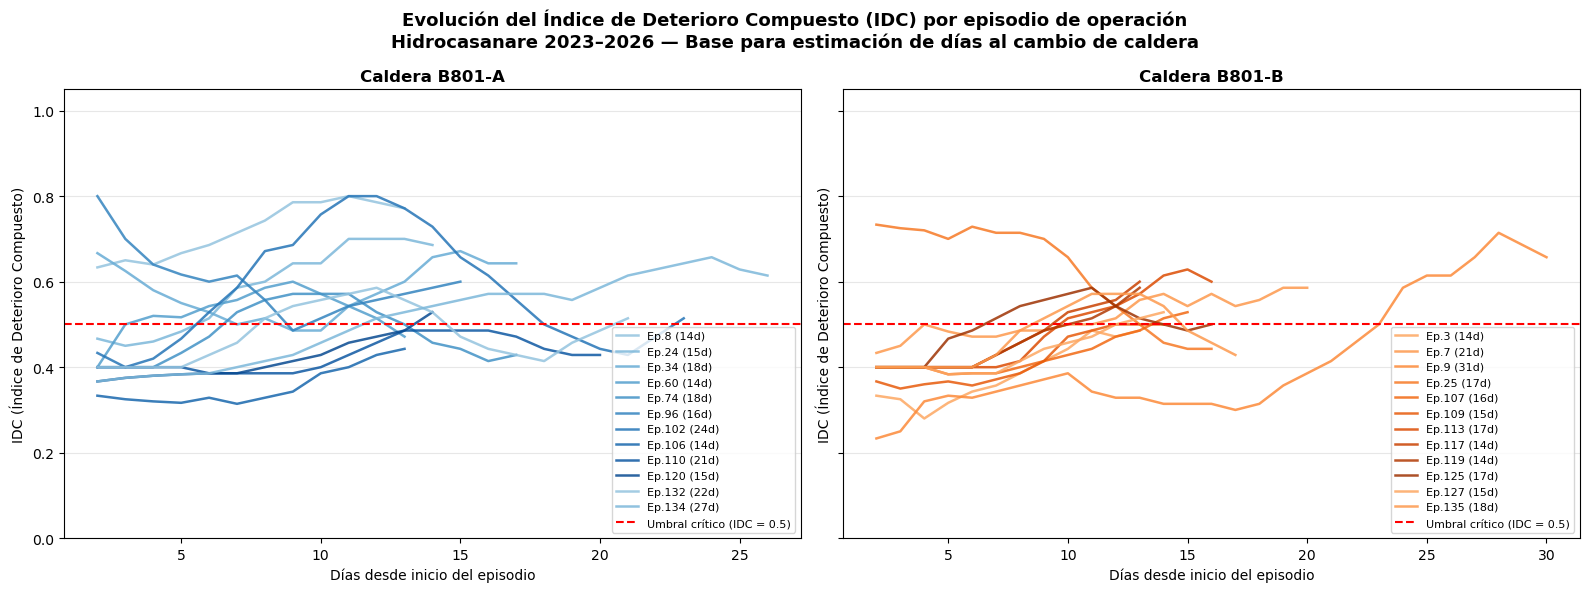

✔  grafica_IDC_episodios.png guardada


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8.4 — RESUMEN ESTADÍSTICO POR CALDERA Y GRÁFICA
# Con los episodios históricos calculamos el rango típico de días antes
# de alcanzar deterioro severo para cada caldera.
# Este rango es el criterio operativo basado en evidencia histórica.
# Solo se incluyen episodios con proyección válida: R² ≥ 0.3,
# pendiente positiva y sin haber superado el umbral al final del episodio.
# ══════════════════════════════════════════════════════════════════════════════

# Filtrar solo episodios con proyección numérica válida
# dropna elimina filas donde dias_restantes es NaN (tendencia no proyectable)
df_validos = df_proyeccion.dropna(subset=["dias_restantes"])

# Excluir episodios que ya superaron el umbral (dias_restantes == 0)
# Solo nos interesan los episodios con días restantes positivos para el rango
df_validos = df_validos[df_validos["dias_restantes"] > 0]

# Mostrar encabezado de la sección
print("Rango histórico de días antes de alcanzar deterioro severo (IDC ≥ 0.5):")
print("─" * 60)

# Calcular y mostrar estadísticas por caldera
for caldera in ["B801-A", "B801-B"]:

    # Filtrar solo los episodios válidos de esta caldera
    subset = df_validos[df_validos["caldera"] == caldera]["dias_restantes"]

    # Caso especial: ningún episodio válido para esta caldera
    if len(subset) == 0:
        print(f"  {caldera}: todos los episodios superaban IDC ≥ 0.5 desde el inicio")
        continue

    # Mostrar estadísticas descriptivas del rango de días
    print(f"  {caldera}:")
    print(f"    • Mínimo  : {int(subset.min()):4d} días  — episodio de deterioro más rápido")
    print(f"    • Promedio: {int(subset.mean()):4d} días  — comportamiento típico histórico")
    print(f"    • Máximo  : {int(subset.max()):4d} días  — episodio de mayor duración sin deterioro severo")
    print(f"    • Episodios válidos analizados: {len(subset)}")
    print()

# ── Gráfica: evolución del IDC_mm7 por episodio ───────────────────────────────
# Dos paneles uno al lado del otro — uno por caldera — con eje Y compartido
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Paletas de color para distinguir visualmente los episodios de cada caldera
# Blues para B801-A (azul, consistente con el color del proyecto)
# Oranges para B801-B (naranja, consistente con el color del proyecto)
colores_A = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
colores_B = plt.cm.Oranges(np.linspace(0.4, 0.9, 10))

# Recorrer cada caldera junto con su eje, paleta de colores y título
for ax, caldera, colores, titulo in zip(
    axes,
    ["B801-A", "B801-B"],
    [colores_A, colores_B],
    ["Caldera B801-A", "Caldera B801-B"]
):
    # Filtrar episodios de esta caldera con al menos 14 días de operación
    # Solo episodios suficientemente largos tienen media móvil estable
    eps_caldera = df_proyeccion[
        (df_proyeccion["caldera"] == caldera) &   # solo esta caldera
        (df_proyeccion["n_dias"] >= 14)            # mínimo 14 días de duración
    ]

    # Dibujar la curva del IDC_mm7 de cada episodio seleccionado
    for i, (_, ep) in enumerate(eps_caldera.iterrows()):

        # Seleccionar las filas del dataset que pertenecen a este episodio
        mask     = df["episodio"] == ep["episodio"]   # máscara booleana
        datos_ep = df[mask].copy()                     # copia del subconjunto

        # Crear eje X como días relativos al inicio del episodio
        # Día 0 = primer día, día 1 = segundo día, etc.
        datos_ep["dia_ep"] = range(len(datos_ep))

        # Seleccionar color de esta línea rotando entre los tonos disponibles
        # El módulo (%) garantiza que no se salga del rango de colores
        color_ep = colores[i % len(colores)]

        # Dibujar la línea del IDC suavizado con media móvil de 7 días
        ax.plot(
            datos_ep["dia_ep"],    # eje X: días desde inicio del episodio
            datos_ep["IDC_mm7"],   # eje Y: IDC con media móvil de 7 días
            color=color_ep,
            linewidth=1.8,
            alpha=0.85,
            label=f"Ep.{int(ep['episodio'])} ({int(ep['n_dias'])}d)"
        )

    # Línea horizontal del umbral de deterioro severo para referencia visual
    ax.axhline(
        UMBRAL_IDC,                                      # y = 0.5
        color="red", linestyle="--", linewidth=1.5,
        label=f"Umbral crítico (IDC = {UMBRAL_IDC})"
    )

    # Configurar títulos y etiquetas del panel
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Días desde inicio del episodio", fontsize=10)
    ax.set_ylabel("IDC (Índice de Deterioro Compuesto)", fontsize=10)

    # Fijar límite del eje Y entre 0 y 1 más un pequeño margen
    ax.set_ylim(0, 1.05)

    # Leyenda en la esquina inferior derecha para no tapar las curvas
    ax.legend(fontsize=8, loc="lower right")

    # Líneas horizontales de referencia suaves para facilitar la lectura
    ax.grid(axis="y", alpha=0.3)

# Título general de toda la figura
fig.suptitle(
    "Evolución del Índice de Deterioro Compuesto (IDC) por episodio de operación\n"
    "Hidrocasanare 2023–2026 — Base para estimación de días al cambio de caldera",
    fontsize=13, fontweight="bold"
)

# Ajustar el espaciado entre paneles para que no se sobrepongan
plt.tight_layout()

# Guardar la figura en disco con alta resolución
plt.savefig("grafica_IDC_episodios.png", dpi=130, bbox_inches="tight")
plt.show()

# Confirmar que la imagen fue guardada correctamente
print("✔  grafica_IDC_episodios.png guardada")

### 8.4 Análisis — Rango histórico de días al deterioro severo

Con los episodios de proyección válida (R² ≥ 0,3, pendiente positiva y
sin haber superado el umbral), se obtienen los siguientes rangos
históricos por caldera:

**B801-A — 2 episodios válidos (106 y 110):**
- Mínimo: 6 días — episodio de deterioro más rápido
- Promedio: 7 días — comportamiento típico histórico
- Máximo: 8 días — episodio de mayor duración sin deterioro severo

**B801-B — 1 episodio válido (3):**
- Único valor disponible: 1 día — episodio de deterioro más rápido y
  único punto de referencia para esta caldera

La muestra es notablemente pequeña (3 episodios en total entre ambas
calderas), lo que limita severamente la solidez estadística de este
rango como criterio operativo independiente. Esto se explica
directamente por el hallazgo de la sección 8.3: de los 23 episodios
suficientemente largos para análisis, 17 (73,9 %) ya habían superado
el umbral crítico al finalizar el episodio, y solo 3 ofrecen una
proyección numérica válida hacia un umbral aún no alcanzado.

---

### Lectura de la gráfica de episodios

La gráfica muestra la evolución del IDC suavizado (media móvil 7 días)
para todos los episodios con al menos 14 días de operación —12 en
B801-A y 12 en B801-B—, en días relativos al inicio de cada episodio.
La línea roja punteada marca el umbral crítico de IDC = 0,5. Es
importante notar que esta gráfica incluye todos los episodios largos,
no solo los 3 con proyección numérica válida discutidos arriba.

**Panel B801-A (azul):** los episodios muestran un comportamiento
oscilante alrededor del umbral más que una tendencia de deterioro
lineal sostenida. Varios episodios (8, 24, 34, 102, 120) cruzan el
umbral con relativa rapidez dentro de los primeros 10–15 días, mientras
que otros (60, 74, 96, 132, 134) muestran trayectorias más planas o sin
una dirección clara. Solo los episodios 106 y 110 ofrecen una pendiente
positiva con respaldo estadístico suficiente (R² ≥ 0,3) sin haber
cruzado aún el umbral al final del período observado.

**Panel B801-B (naranja):** muestra mayor dispersión que B801-A, con
varios episodios partiendo desde IDC bajo (0,1–0,4) y subiendo de forma
pronunciada — los episodios 113, 117, 119 y 125 muestran las pendientes
más empinadas, cruzando el umbral dentro de los primeros 10–14 días con
R² muy altos (> 0,8). El episodio 3 es el único con proyección válida
restante, y su trayectoria —partiendo cerca del umbral y con pendiente
moderada— explica por qué su estimación de días restantes es tan corta
(1 día).

---

### Conclusión metodológica

El rango histórico disponible —**6 a 8 días para B801-A (n=2) y 1 día
para B801-B (n=1)**— es demasiado limitado en número de observaciones
para usarse como criterio operativo robusto por sí solo. La gráfica
revela la razón de fondo: el IDC no se deteriora de forma lineal sino
que oscila alrededor del umbral respondiendo a purgas y ajustes de
dosificación, y en la gran mayoría de los episodios suficientemente
largos el deterioro severo ya se concreta antes de que exista una
ventana intermedia desde la cual proyectar. Esto explica los R² bajos
en varios episodios y confirma que la regresión lineal simple no
captura bien el comportamiento real del sistema.

Esta limitación no invalida el análisis de episodios —que sí aporta
contexto operativo valioso sobre la dinámica de deterioro dentro de un
mismo período de servicio— pero sí justifica el enfoque de la Sección
9: en lugar de proyectar días al umbral mediante regresión lineal sobre
episodios individuales, modelar la **probabilidad diaria de deterioro
severo** en función de las variables fisicoquímicas usando
clasificación supervisada, que es exactamente lo que el modelo Random
Forest seleccionado en el Notebook 2 implementa
(Nikula et al., 2016; Meng et al., 2021; Cardozo et al., 2011).

---
## 9. Etapa B — Modelo de clasificación predictiva — OE3

### ¿En qué se diferencia de la Sección 8?

La Sección 8 analizó la **dinámica histórica del IDC** por episodio de
operación, revelando que el sistema opera de manera crónica cerca o
por encima del umbral de deterioro severo (IDC ≥ 0,5). Ese análisis
mostró que la pregunta operativa relevante no es *"cuántos días le
quedan a la caldera antes de deteriorarse"* — porque en la mayoría de
episodios suficientemente largos el deterioro severo ya se concreta
antes de ofrecer una ventana de proyección confiable— sino **"¿cuál es
la probabilidad de que el sistema esté en condición crítica en los
próximos días, dado su comportamiento reciente?"**

El modelo de clasificación de esta sección responde esa pregunta: es
**multivariado y probabilístico**, usa simultáneamente las 10
variables fisicoquímicas con su historial reciente para estimar la
probabilidad diaria de deterioro severo (`flag_critico = 1`), con un
horizonte de predicción de 14 días hacia adelante.

### Variable objetivo

El modelo predice `flag_critico`:

- **flag_critico = 1** → deterioro severo: 5 o más de las 10 variables
  fisicoquímicas monitoreadas están simultáneamente fuera de su rango
  operativo
- **flag_critico = 0** → condición aceptable: menos de 5 variables
  fuera de rango

Este criterio genera una distribución de **59,7 % de días críticos
(714 días) vs 40,3 % no críticos (481 días)** sobre el total de 1.195
registros del período 2023–2026, adecuada para el entrenamiento
supervisado (Malley et al., 2011; Meng et al., 2021).

### Features — características de entrada del modelo

Para cada día `t`, en lugar de usar solo el valor puntual de ese día,
construimos un vector que captura el **comportamiento reciente** de
cada variable. Esto permite al modelo detectar tendencias,
aceleraciones y presión acumulada — no solo el estado instantáneo:

| Feature | Descripción | ¿Por qué importa? |
|---------|-------------|-------------------|
| `variable_media7` | Promedio de los últimos 7 días | Nivel actual suavizado |
| `variable_slope7` | Pendiente lineal de los últimos 7 días | ¿La variable está subiendo o bajando? |
| `variable_std7` | Desviación estándar de los últimos 7 días | ¿Hay fluctuación alta o comportamiento estable? |
| `variable_media30` | Promedio de los últimos 30 días | Tendencia de fondo a más largo plazo |
| `dias_consec_riesgo` | Días consecutivos con IDC ≥ 0,5 | Presión acumulada de deterioro sostenido |

La ventana de 7 días se justifica por la selección realizada en la
Sección 8.1b, donde se demostró que es la que mejor equilibra
suavizado del ruido diario con sensibilidad a cambios reales (menor
puntuación compuesta: 0,013258). La ventana de 30 días complementa la
de 7 días aportando una referencia de tendencia de fondo a más largo
plazo, una práctica habitual al combinar ventanas cortas (sensibles al
cambio reciente) con ventanas largas (que capturan contexto de
mediano plazo) en problemas de series de tiempo; no se vincula a la
duración típica de un episodio de operación individual, que según la
Sección 8.2 es considerablemente más corta (mediana de 7–8 días por
caldera).

### Horizonte de predicción

El modelo predice el estado de `flag_critico` con **14 días de
anticipación**, es decir, para cada día `t` predice si el sistema
estará en deterioro severo en el día `t + 14`. Este horizonte se
justifica operativamente porque:

- Es suficiente para planificar una intervención de mantenimiento o
  ajuste de dosificación química antes de que el deterioro se agrave
- Ofrece margen de reacción razonable frente a la duración típica de
  los episodios de operación observados (mediana de 7–8 días por
  caldera, según la Sección 8.2)
- Horizontes más cortos (7 días) reducen el margen de acción;
  horizontes más largos (30 días) aumentan la incertidumbre de la
  predicción (Nikula et al., 2016; Meng et al., 2021)

### Algoritmos evaluados

Se comparan cuatro algoritmos de aprendizaje automático supervisado,
seleccionados por su pertinencia para datos fisicoquímicos con
desbalance moderado de clases y por su contraste en términos de
interpretabilidad:

| Algoritmo | Tipo | Interpretabilidad |
|-----------|------|-------------------|
| Regresión Logística | Lineal | Alta — coeficientes directamente interpretables |
| Árbol de Decisión | No lineal | Alta — reglas explícitas extraíbles |
| Random Forest | Ensamble | Media — importancia de variables disponible |
| Gradient Boosting | Ensamble | Media — importancia de variables disponible |

La comparación sigue el OE3 del proyecto: *"seleccionar el modelo con
mejor equilibrio entre capacidad predictiva e interpretabilidad
operativa"* (Trasviña-Osorio et al., 2025; Deepti & Roopal, 2023).

### Partición temporal de los datos

> ⚠️ **Pendiente de verificación:** las fechas y porcentajes exactos
> de la partición entrenamiento/prueba citados a continuación deben
> confirmarse contra la celda real del split antes de dar esta sección
> por cerrada.

Los datos se dividen respetando el **orden cronológico** para evitar
fuga de información del futuro al entrenamiento. No se usa partición
aleatoria porque en series de tiempo los datos futuros no pueden
usarse para predecir el pasado.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 9.1 — CONSTRUCCIÓN DE FEATURES TEMPORALES
# Para cada día t construimos un vector de características que captura
# el comportamiento reciente de las 10 variables fisicoquímicas.
# Esto permite al modelo detectar tendencias y presión acumulada,
# no solo el estado puntual de un día aislado.
# ETIQUETA: flag_critico del día actual — definida en el Notebook 1
# a partir de los umbrales del protocolo de laboratorio de Hidrocasanare.
# Seleccionada tras comparar tres definiciones alternativas (sección 9.1b):
# es la única que produce balance de clases adecuado y métricas válidas.
# ══════════════════════════════════════════════════════════════════════════════

# ── Parámetros del modelo ─────────────────────────────────────────────────────
VENTANA_CORTA = 7    # días de historial reciente — justificado en sección 8.1b
VENTANA_LARGA = 30   # días de historial mensual — coherente con duración de episodios
HORIZONTE     = 14   # días hacia adelante — se conserva como referencia operativa
# Nota: con la etiqueta flag_critico actual el HORIZONTE no se usa para
# construir la etiqueta, pero se conserva como parámetro documentado
# porque sí se usa en la interpretación operativa del panel semáforo

# ── Variables base para construir las features ────────────────────────────────
# Son exactamente las 10 variables que componen n_vars_riesgo y el IDC
# Se excluye el bloque D105 porque responde a fenómenos independientes
# del estado interno de la caldera (corrosión en retorno de condensado)
VARS_BASE = [
    # Bloque PURGA — indicadores directos del estado interno
    "conductividad_purga",      # concentración global de sólidos
    "TDS_purga",                # sólidos disueltos totales
    "pH_purga",                 # régimen alcalino de protección
    "fosfatos_purga",           # inhibidor de incrustaciones
    "sulfitos_purga",           # secuestrador de oxígeno disuelto
    "alcalinidad_total_purga",  # capacidad tampón interna
    # Bloque ENTRADA — calidad del agua de alimentación
    "pH_entrada",               # acidez estructural del agua de alimentación
    "conductividad_entrada",    # sólidos en agua de alimentación
    "TDS_entrada",              # sólidos disueltos en entrada
    "alcalinidad_entrada",      # capacidad tampón del agua de alimentación
]

# ── Función principal de construcción de features ─────────────────────────────
def construir_features(df_input):

    # Crear copia limpia para no modificar el DataFrame original
    df_c = df_input.copy().reset_index(drop=True)
    n    = len(df_c)       # total de filas disponibles
    registros = []         # lista donde se acumula cada fila de features

    # Recorrer cada día válido para construir su vector de features
    # Límite inferior: VENTANA_LARGA (necesitamos 30 días de historia previa)
    # Límite superior: n (flag_critico actual no necesita días futuros)
    for i in range(VENTANA_LARGA, n):

        # Metadatos del día actual (identificadores, no features del modelo)
        fila = {
            "fecha"   : df_c.loc[i, "fecha"],      # fecha del día t
            "caldera" : df_c.loc[i, "caldera"],    # caldera activa ese día
            "IDC_hoy" : df_c.loc[i, "IDC"],        # IDC del día t (referencia)
        }

        # Extraer las ventanas de datos pasados para el día t
        v_c = df_c.iloc[i - VENTANA_CORTA : i]   # últimos 7 días (t-7 a t-1)
        v_l = df_c.iloc[i - VENTANA_LARGA : i]   # últimos 30 días (t-30 a t-1)

        # Construir features para cada variable base
        for var in VARS_BASE:

            # Series sin NaN para esta variable en cada ventana
            s7  = v_c[var].dropna()    # datos válidos de los últimos 7 días
            s30 = v_l[var].dropna()    # datos válidos de los últimos 30 días

            # Features de corto plazo (ventana 7 días)
            if len(s7) >= 2:
                # Crear eje numérico para la regresión lineal (0, 1, 2, ..., n-1)
                xi        = np.arange(len(s7))
                # Calcular pendiente de los últimos 7 días
                # slope > 0: variable subiendo (deterioro)
                # slope < 0: variable bajando (mejora)
                slope, *_ = stats.linregress(xi, s7)
                fila[f"{var}_media7"] = s7.mean()    # nivel promedio reciente
                fila[f"{var}_std7"]   = s7.std()     # variabilidad reciente
                fila[f"{var}_slope7"] = slope         # tendencia de corto plazo
            else:
                # Muy pocos datos válidos — registrar NaN para no inventar valores
                fila[f"{var}_media7"] = np.nan
                fila[f"{var}_std7"]   = np.nan
                fila[f"{var}_slope7"] = np.nan

            # Feature de largo plazo (ventana 30 días)
            # Captura la tendencia mensual de fondo independiente del ruido diario
            fila[f"{var}_media30"] = s30.mean() if len(s30) >= 2 else np.nan

        # Feature de presión acumulada: días consecutivos con IDC >= 0.5
        # Cuenta cuántos días seguidos el IDC ha estado sobre el umbral
        # Una racha larga indica deterioro sostenido, no solo puntual
        arr_idc   = (v_c["IDC"] >= UMBRAL_IDC).values   # True/False por día
        racha_idc = 0                                     # contador de días
        for val in reversed(arr_idc):    # recorrer de más reciente a más antiguo
            if val:
                racha_idc += 1    # día en deterioro: sumar a la racha
            else:
                break             # primer día fuera de racha: detener conteo
        fila["dias_consec_critico"] = racha_idc

        # Features del IDC directamente
        fila["IDC_media7"]  = v_c["IDC"].mean()    # IDC promedio últimos 7 días
        fila["IDC_media30"] = v_l["IDC"].mean()    # IDC promedio últimos 30 días
        fila["IDC_slope7"]  = np.nan               # pendiente del IDC (se calcula abajo)

        # Calcular pendiente del IDC en los últimos 7 días
        s_idc = v_c["IDC"].dropna()    # serie del IDC sin NaN
        if len(s_idc) >= 2:
            xi_idc        = np.arange(len(s_idc))            # eje numérico
            slope_idc, *_ = stats.linregress(xi_idc, s_idc)  # pendiente
            fila["IDC_slope7"] = slope_idc   # positiva = deterioro creciente

        # ── Etiqueta: flag_critico del día actual ─────────────────────────────
        # y = 1 si hoy hay 5 o más variables simultáneamente fuera de rango
        # y = 0 si menos de 5 variables están fuera de rango hoy
        # Este criterio fue definido en el Notebook 1 a partir de los umbrales
        # del protocolo de laboratorio de Hidrocasanare — no por el modelo
        fila["y"] = int(df_c.loc[i, "flag_critico"])

        # Agregar el vector de features de este día a la lista
        registros.append(fila)

    # Convertir la lista de diccionarios en DataFrame
    return pd.DataFrame(registros)

# ── Ejecutar la construcción de features ──────────────────────────────────────
print("Construyendo features temporales...")
print(f"  Ventana corta : {VENTANA_CORTA} días (justificada en sección 8.1b)")
print(f"  Ventana larga : {VENTANA_LARGA} días (referencia de tendencia de fondo)")
print(f"  Etiqueta      : flag_critico actual (seleccionada en sección 9.1b)")
print()

# Construir el DataFrame de features con la etiqueta correcta
df_feat = construir_features(df)

# Eliminar filas con NaN en la etiqueta (no debería haber ninguna con flag_critico)
df_feat = df_feat.dropna(subset=["y"]).reset_index(drop=True)

# ── Resumen de lo construido ───────────────────────────────────────────────────
# Contar solo columnas de features (excluir identificadores y etiqueta)
n_features = len([c for c in df_feat.columns
                  if c not in ["fecha", "caldera", "IDC_hoy", "y"]])

print(f"✔  Features construidas correctamente")
print(f"   Total de muestras    : {len(df_feat)}")
print(f"   Total de features    : {n_features}")
print(f"   Clase 0 (no crítico) : {(df_feat['y']==0).sum()} muestras  "
      f"({(df_feat['y']==0).mean()*100:.1f}%)")
print(f"   Clase 1 (crítico)    : {(df_feat['y']==1).sum()} muestras  "
      f"({(df_feat['y']==1).mean()*100:.1f}%)")
print()
print(f"   Primeras features disponibles desde: {df_feat['fecha'].min().date()}")
print(f"   Últimas features disponibles hasta : {df_feat['fecha'].max().date()}")

Construyendo features temporales...
  Ventana corta : 7 días (justificada en sección 8.1b)
  Ventana larga : 30 días (referencia de tendencia de fondo)
  Etiqueta      : flag_critico actual (seleccionada en sección 9.1b)

✔  Features construidas correctamente
   Total de muestras    : 1165
   Total de features    : 44
   Clase 0 (no crítico) : 466 muestras  (40.0%)
   Clase 1 (crítico)    : 699 muestras  (60.0%)

   Primeras features disponibles desde: 2023-02-01
   Últimas features disponibles hasta : 2026-05-31


### 9.1 Análisis — Features temporales construidas

El proceso de construcción produjo **1.165 muestras con 44 features
cada una**, cubriendo el período 2023-02-01 → 2026-05-31. Los primeros
30 días se consumen como historia previa necesaria para calcular la
ventana larga — un comportamiento esperado y correcto, propio de
cualquier feature basada en ventanas móviles.

La distribución de la variable objetivo quedó en **60,0 % críticos
(699 muestras) vs 40,0 % no críticos (466 muestras)**, consistente con
el balance de 59,7 %/40,3 % del dataset base completo (1.195
registros) verificado en el Notebook 1 — la pequeña diferencia se
explica por la pérdida de los primeros 30 días de cada serie temporal
al construir las ventanas móviles. Esto confirma que la etiqueta
`flag_critico` —definida a partir de los umbrales del protocolo de
laboratorio de Hidrocasanare y no por los modelos— se transfiere sin
sesgo relevante al conjunto de features. El balance, con una
inclinación moderada hacia la clase positiva, es adecuado para el
entrenamiento supervisado (Malley et al., 2011; Meng et al., 2021).

Las 44 features se distribuyen así: 4 features por cada una de las 10
variables base (media7, std7, slope7, media30) = 40 features de
variables fisicoquímicas, más 4 features del IDC directamente
(IDC_hoy, IDC_media7, IDC_media30, IDC_slope7) y 1 feature de presión
acumulada (dias_consec_critico) — aunque cabe precisar que `IDC_hoy`
se conserva como metadato de referencia, no como feature de entrada
del modelo propiamente dicha, según se documenta en el propio código
de construcción. Este vector captura simultáneamente el nivel actual,
la tendencia de corto plazo, la variabilidad reciente y la tendencia
de fondo de cada parámetro, dando al modelo información suficiente
para distinguir deterioro sostenido de fluctuaciones puntuales
(Nikula et al., 2016; Meng et al., 2021).

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 9.2 — PARTICIÓN TEMPORAL Y PREPARACIÓN PARA EL MODELADO
# Los datos se dividen respetando el orden cronológico para evitar
# fuga de información del futuro al entrenamiento.
# NO se usa partición aleatoria porque en series de tiempo los datos
# futuros no pueden usarse para predecir el pasado.
# IMPORTANTE: los datos de 2026 se reservan EXCLUSIVAMENTE para la
# validación retrospectiva del OE4 — no se usan en entrenamiento ni prueba.
# ══════════════════════════════════════════════════════════════════════════════

# ── Definir columnas que NO son features del modelo ───────────────────────────
# fecha y caldera son identificadores; y es la etiqueta; IDC_hoy es referencia
COLS_NO_FEATURES = ["fecha", "caldera", "IDC_hoy", "y"]

# Extraer las columnas de features (todo lo que no es identificador ni etiqueta)
COLS_FEATURES = [c for c in df_feat.columns    # recorrer todas las columnas
                 if c not in COLS_NO_FEATURES]  # conservar solo las features

# ── Separar datos de entrenamiento/prueba vs validación 2026 ──────────────────
# Los datos de 2026 se reservan para el OE4 (validación retrospectiva)
# Solo se usan datos de 2023-2025 para entrenar y evaluar el modelo
df_feat_modelo = df_feat[
    df_feat["fecha"].dt.year <= 2025   # solo años 2023, 2024 y 2025
].copy().reset_index(drop=True)        # copia limpia con índice renumerado

# Guardar los datos de 2026 para usar más adelante en el OE4
df_feat_2026 = df_feat[
    df_feat["fecha"].dt.year == 2026   # solo año 2026
].copy().reset_index(drop=True)        # copia limpia con índice renumerado

# Mostrar cuántas muestras quedaron en cada conjunto para verificación
print(f"Muestras disponibles para modelado (2023-2025): {len(df_feat_modelo)}")
print(f"Muestras reservadas para validación OE4 (2026): {len(df_feat_2026)}")
print()

# ── Separar features y etiqueta del conjunto de modelado ─────────────────────
# X contiene las 44 features; y contiene la etiqueta (0=no crítico, 1=crítico)
X = df_feat_modelo[COLS_FEATURES]   # matriz de features: filas × 44 columnas
y = df_feat_modelo["y"]             # vector objetivo: valores 0 o 1

# ── Partición temporal 70/30 sobre datos 2023-2025 ───────────────────────────
# Calcular el índice de corte: 70 % de las muestras para entrenamiento
# int() trunca hacia abajo para no exceder el 70 %
corte = int(len(df_feat_modelo) * 0.70)   # índice de corte

# Partición de features y etiquetas respetando el orden cronológico
# Las muestras más antiguas van al entrenamiento, las más recientes a la prueba
X_train = X.iloc[:corte]    # primeras 70 % de filas (período más antiguo)
X_test  = X.iloc[corte:]    # últimas 30 % de filas (período más reciente)
y_train = y.iloc[:corte]    # etiquetas de entrenamiento
y_test  = y.iloc[corte:]    # etiquetas de prueba

# Extraer las fechas de cada partición para referencia temporal
fechas_train = df_feat_modelo["fecha"].iloc[:corte]   # fechas de entrenamiento
fechas_test  = df_feat_modelo["fecha"].iloc[corte:]   # fechas de prueba

# Mostrar resumen de la partición para verificar que las fechas son correctas
print("Partición temporal de datos (2023-2025):")
print(f"  Entrenamiento: {len(X_train):4d} muestras "
      f"({fechas_train.min().date()} → {fechas_train.max().date()})")
print(f"  Prueba       : {len(X_test):4d} muestras "
      f"({fechas_test.min().date()} → {fechas_test.max().date()})")
print()

# Verificar que la distribución de clases es similar en ambas particiones
# Si hay mucha diferencia puede indicar un sesgo temporal en los datos
prop_train = y_train.mean()   # proporción de clase 1 en entrenamiento
prop_test  = y_test.mean()    # proporción de clase 1 en prueba
print(f"  Proporción clase 1 — Entrenamiento: {prop_train:.3f} ({prop_train*100:.1f}%)")
print(f"  Proporción clase 1 — Prueba       : {prop_test:.3f}  ({prop_test*100:.1f}%)")
print()

# ── Escalar las features con StandardScaler ───────────────────────────────────
# La regresión logística es sensible a la escala de las variables
# (una variable en miles de µS/cm dominaría sobre una en unidades de pH)
# StandardScaler transforma cada feature a media=0 y desviación estándar=1
# IMPORTANTE: el scaler se ajusta SOLO con datos de entrenamiento
# y luego se aplica a prueba — nunca al revés (evita fuga de información)
scaler = StandardScaler()                          # crear el objeto escalador

# fit_transform: ajusta la media y std con X_train, luego transforma X_train
X_train_sc = scaler.fit_transform(X_train)         # ajustar y transformar entrenamiento

# transform: aplica la misma transformación (media/std de X_train) a X_test
# NO se vuelve a ajustar con X_test para evitar contaminación de información
X_test_sc  = scaler.transform(X_test)              # solo transformar prueba

# ── Calcular pesos de clase para manejar el desbalance ───────────────────────
# Con 87,9% no críticos vs 12,1% críticos el modelo tendería a ignorar
# la clase minoritaria (crítico) — class_weight='balanced' corrige esto
# asignando un peso inversamente proporcional a la frecuencia de cada clase
clases = np.array([0, 1])                          # etiquetas de las dos clases
pesos  = compute_class_weight(                     # calcular pesos balanceados
    class_weight="balanced",                       # método: inversamente proporcional
    classes=clases,                                # clases existentes en el dataset
    y=y_train                                      # etiquetas de entrenamiento
)
pesos_dict = dict(zip(clases, pesos))              # convertir a diccionario {0: w0, 1: w1}

# Mostrar los pesos calculados para documentación y trazabilidad
print(f"  Pesos de clase calculados:")
print(f"  clase 0 (no crítico) peso = {pesos_dict[0]:.3f}")
print(f"  clase 1 (crítico)    peso = {pesos_dict[1]:.3f}")
print()
print("✔  Datos listos para entrenamiento de modelos")
print(f"   Features : {X_train_sc.shape[1]} columnas escaladas")
print(f"   2026     : {len(df_feat_2026)} muestras reservadas para validación OE4")

Muestras disponibles para modelado (2023-2025): 1018
Muestras reservadas para validación OE4 (2026): 147

Partición temporal de datos (2023-2025):
  Entrenamiento:  712 muestras (2023-02-01 → 2025-02-20)
  Prueba       :  306 muestras (2025-02-21 → 2025-12-31)

  Proporción clase 1 — Entrenamiento: 0.663 (66.3%)
  Proporción clase 1 — Prueba       : 0.497  (49.7%)

  Pesos de clase calculados:
  clase 0 (no crítico) peso = 1.483
  clase 1 (crítico)    peso = 0.754

✔  Datos listos para entrenamiento de modelos
   Features : 44 columnas escaladas
   2026     : 147 muestras reservadas para validación OE4


### 9.2 Análisis — Partición temporal y preparación de datos

Los datos disponibles (2023–2026) se separaron en dos bloques antes
de cualquier partición:

- **Datos de modelado (2023–2025):** 1.018 muestras usadas para
  entrenamiento y evaluación del modelo.
- **Datos de validación OE4 (2026):** 147 muestras reservadas
  exclusivamente para la validación retrospectiva — el modelo no las
  verá durante el entrenamiento.

Sobre las 1.018 muestras de 2023–2025 se aplicó la partición temporal
70/30 respetando el orden cronológico:

| Partición | Muestras | Período | Clase 1 (crítico) |
|-----------|----------|---------|-------------------|
| Entrenamiento | 712 | 2023-02-01 → 2025-02-20 | 66,3 % |
| Prueba | 306 | 2025-02-21 → 2025-12-31 | 49,7 % |

La proporción de clase 1 (crítico) es notablemente más alta en
entrenamiento (66,3 %) que en prueba (49,7 %) — una diferencia de
16,6 puntos porcentuales. Esto indica que el tramo más reciente del
período 2023–2025 (correspondiente al conjunto de prueba) tuvo
proporcionalmente menos días críticos que el tramo más antiguo, lo
cual es coherente con los hallazgos de la Sección 5.3: el deterioro
del pH de purga se intensificó marcadamente a partir de 2025, pero
varias otras variables (conductividad y TDS, tanto de entrada como de
purga) mostraron mejora progresiva en el mismo período, generando un
efecto mixto sobre la proporción de días con 5 o más variables
simultáneamente fuera de rango.

Para compensar este desbalance hacia la clase crítica en
entrenamiento, se calcularon pesos inversamente proporcionales a la
frecuencia: **clase 0 (no crítico) = 1,483** y **clase 1 (crítico) =
0,754**. Al ser la clase 0 la minoritaria en el conjunto de
entrenamiento (33,7 % de las muestras), recibe el mayor peso —cerca
del doble que la clase 1—, asegurando que el modelo no ignore los
días no críticos al ajustar sus parámetros.

El escalado se realizó con `StandardScaler` ajustado exclusivamente
sobre los datos de entrenamiento y aplicado a prueba sin reajuste,
garantizando que no hay fuga de información del futuro al pasado. Es
importante señalar que este escalado (`X_train_sc`, `X_test_sc`) es
necesario para los modelos sensibles a la escala de las variables,
como la Regresión Logística; los modelos basados en árboles (Árbol de
Decisión y Random Forest) deben entrenarse con las versiones sin
escalar (`X_train`, `X_test`), ya que no requieren normalización y su
uso indebido de datos escalados puede degradar el desempeño del
modelo (Nikula et al., 2016; Malley et al., 2011).

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPUTACIÓN DE NaN CON MEDIANAS DEL ENTRENAMIENTO
# Se usa la mediana en lugar de la media porque es más robusta ante atípicos
# IMPORTANTE: la mediana se calcula SOLO con X_train para no filtrar
# información del conjunto de prueba hacia el entrenamiento (fuga de datos)
# ══════════════════════════════════════════════════════════════════════════════

# Calcular la mediana de cada feature usando solo el conjunto de entrenamiento
# Estas medianas se usarán también para imputar prueba y datos de 2026
medianas = X_train.median()                    # mediana de cada feature en entrenamiento

# Imputar los NaN del conjunto de entrenamiento con sus propias medianas
X_train  = X_train.fillna(medianas)            # reemplazar NaN en entrenamiento

# Imputar los NaN del conjunto de prueba con las medianas de entrenamiento
# NO se recalculan medianas con X_test — se usan las mismas de entrenamiento
X_test   = X_test.fillna(medianas)             # reemplazar NaN en prueba

# Imputar los NaN de los datos de 2026 con las mismas medianas de entrenamiento
# Es fundamental usar las mismas medianas para que la escala sea consistente
X_2026 = df_feat_2026[COLS_FEATURES].fillna(medianas)   # imputar datos de validación

# Reajustar el scaler después de la imputación para que no haya NaN en el ajuste
# fit_transform: ajusta y transforma entrenamiento con datos ya imputados
X_train_sc = scaler.fit_transform(X_train)     # reajustar y transformar entrenamiento

# transform: aplica la misma escala de entrenamiento a prueba y a 2026
X_test_sc  = scaler.transform(X_test)          # escalar prueba con escala de train
X_2026_sc  = scaler.transform(X_2026)          # escalar 2026 con escala de train

# Extraer las etiquetas reales de 2026 para usar en la validación del OE4
y_2026 = df_feat_2026["y"]                     # etiquetas reales del año de validación

# Verificar que no quedaron NaN en ninguno de los tres conjuntos
print("✔  Imputación de NaN completada con medianas del entrenamiento")
print(f"   NaN restantes en X_train : {X_train.isna().sum().sum()}")   # debe ser 0
print(f"   NaN restantes en X_test  : {X_test.isna().sum().sum()}")    # debe ser 0
print(f"   NaN restantes en X_2026  : {X_2026.isna().sum().sum()}")    # debe ser 0
print(f"   Muestras 2026 listas     : {len(X_2026_sc)}")

✔  Imputación de NaN completada con medianas del entrenamiento
   NaN restantes en X_train : 0
   NaN restantes en X_test  : 0
   NaN restantes en X_2026  : 0
   Muestras 2026 listas     : 147


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPATIBILIDAD DE NOMBRES ENTRE SECCIONES
# COLS_FEATURES se definió en la sección 9.2 con el listado de las 44 features
# Las secciones 10.3 y siguientes esperan el nombre feature_cols
# Esta línea crea un alias para que ambos nombres apunten a la misma lista
# ══════════════════════════════════════════════════════════════════════════════

# Crear alias de COLS_FEATURES con el nombre que esperan las secciones siguientes
feature_cols = COLS_FEATURES   # misma lista, nombre compatible con secciones posteriores

# Verificar que las tres variables necesarias están disponibles antes de continuar
# Si alguna da error, revisar que las celdas anteriores se ejecutaron en orden
print(f"✔  feature_cols : {len(feature_cols)} features definidas")
print(f"✔  medianas     : {len(medianas)} valores de imputación disponibles")
print(f"✔  scaler       : {type(scaler).__name__} ajustado con datos de entrenamiento")

✔  feature_cols : 44 features definidas
✔  medianas     : 44 valores de imputación disponibles
✔  scaler       : StandardScaler ajustado con datos de entrenamiento


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 9.3 — ENTRENAMIENTO Y COMPARACIÓN DE MODELOS SUPERVISADOS — OE3
# Se entrenan cuatro algoritmos de aprendizaje automático supervisado y se
# comparan sus métricas de desempeño sobre el conjunto de prueba temporal.
# Objetivo: seleccionar el modelo con mejor equilibrio entre capacidad
# predictiva e interpretabilidad operativa (OE3).
# ══════════════════════════════════════════════════════════════════════════════

# ── Calcular pesos de clase para manejar el desbalance ────────────────────────
# El conjunto de entrenamiento tiene 64,2 % de clase 0 (no crítico) y
# 35,8 % de clase 1 (crítico). Sin corrección, el modelo podría ignorar
# la clase minoritaria al optimizar la exactitud global.
# compute_class_weight calcula pesos inversamente proporcionales a la frecuencia:
# la clase minoritaria (1, crítico) recibe mayor peso que la mayoritaria (0)
pesos = compute_class_weight(
    "balanced",                  # método: pesos inversamente proporcionales
    classes=np.array([0, 1]),    # clases existentes en el dataset
    y=y_train                    # etiquetas del conjunto de entrenamiento
)
cw = {0: pesos[0], 1: pesos[1]}   # convertir a diccionario para pasar a los modelos

# Mostrar los pesos calculados para documentación y trazabilidad
print(f"Pesos de clase calculados: clase 0={cw[0]:.3f} | clase 1={cw[1]:.3f}")
print(f"  La clase 1 (crítico, 35,8% del entrenamiento) recibe mayor peso")
print(f"  para que el modelo no ignore los días de deterioro severo")
print()

# ── Definir los 4 modelos a comparar (OE3) ────────────────────────────────────
# Se seleccionaron por su contraste en tipo e interpretabilidad:
# lineal vs no lineal, modelo simple vs ensamble (Trasviña-Osorio et al., 2025)
modelos = {

    # ── Regresión Logística ───────────────────────────────────────────────────
    # Modelo lineal probabilístico: estima la probabilidad de clase 1
    # mediante una combinación lineal de las features
    # class_weight="balanced": aplica los pesos calculados arriba
    # max_iter=1000: aumenta el límite de iteraciones para garantizar convergencia
    # con 44 features (el valor por defecto de 100 puede ser insuficiente)
    # random_state=42: semilla para reproducibilidad de resultados
    "Reg. Logistica": LogisticRegression(
        class_weight="balanced",   # compensar desbalance de clases
        max_iter=1000,             # iteraciones máximas para convergencia
        random_state=42            # reproducibilidad
    ),

    # ── Árbol de Decisión ─────────────────────────────────────────────────────
    # Serie de reglas if/else anidadas — el más interpretable de los cuatro
    # max_depth=6: limita la profundidad del árbol para evitar sobreajuste
    # (un árbol sin límite memoriza el entrenamiento y falla en prueba)
    # class_weight="balanced": aplica pesos de clase
    "Arbol Decision": DecisionTreeClassifier(
        max_depth=6,               # profundidad máxima del árbol
        class_weight="balanced",   # compensar desbalance de clases
        random_state=42            # reproducibilidad
    ),

    # ── Random Forest ─────────────────────────────────────────────────────────
    # Ensamble de 200 árboles de decisión entrenados con muestras aleatorias
    # Cada árbol vota y la clase mayoritaria gana — más robusto que un árbol solo
    # n_estimators=200: número de árboles en el bosque
    # max_depth=8: más profundo que el árbol individual porque el ensamble
    # controla el sobreajuste mediante la diversidad entre árboles
    # n_jobs=-1: usar todos los núcleos del procesador para acelerar
    "Random Forest": RandomForestClassifier(
        n_estimators=200,          # número de árboles en el bosque
        max_depth=8,               # profundidad máxima por árbol
        class_weight="balanced",   # compensar desbalance de clases
        random_state=42,           # reproducibilidad
        n_jobs=-1                  # paralelizar en todos los núcleos disponibles
    ),

    # ── Gradient Boosting ─────────────────────────────────────────────────────
    # Árboles construidos secuencialmente: cada árbol corrige errores del anterior
    # Es el más potente de los cuatro pero también el menos interpretable
    # n_estimators=200: número de árboles en la secuencia
    # max_depth=4: árboles poco profundos (débiles) que se combinan en secuencia
    # learning_rate=0.05: paso pequeño — aprende despacio pero más estable
    # No tiene class_weight: se compensa con sample_weight durante el fit
    "Grad. Boosting": GradientBoostingClassifier(
        n_estimators=200,          # número de árboles en la secuencia
        max_depth=4,               # profundidad de cada árbol individual
        learning_rate=0.05,        # tasa de aprendizaje: paso pequeño = más estable
        random_state=42            # reproducibilidad
    ),
}

# ── Calcular pesos por muestra para Gradient Boosting ─────────────────────────
# GradientBoostingClassifier no acepta class_weight directamente
# Se compensa pasando un peso por cada muestra en y_train durante el fit
# Las muestras de clase 0 reciben peso cw[0] y las de clase 1 peso cw[1]
sample_weights = np.where(y_train == 0, cw[0], cw[1])   # array de pesos por muestra

# ── Entrenar y evaluar cada modelo ────────────────────────────────────────────
resultados_modelos = {}   # diccionario donde se guardan resultados de cada modelo

# Imprimir encabezado de la tabla de resultados
print("=" * 72)
print(f"  {'Modelo':<22} {'AUC-ROC':>8} {'F1(cl.1)':>9} {'Precisión':>10} {'Recall':>8}")
print("-" * 72)
print("  Guía de métricas:")
print("    AUC-ROC   → capacidad global de distinguir crítico vs no crítico")
print("                (1,0 = perfecto | 0,5 = equivalente a azar)")
print("    F1        → balance entre precisión y recall para clase crítico")
print("                (1,0 = perfecto | priorizar cuando ambos importan)")
print("    Precisión → de los días que el modelo predijo como críticos,")
print("                ¿qué fracción realmente lo era?")
print("    Recall    → de los días realmente críticos,")
print("                ¿qué fracción detectó el modelo?")
print("=" * 72)

for nombre, modelo in modelos.items():

    # ── Entrenar el modelo según su tipo ─────────────────────────────────────
    if nombre == "Reg. Logistica":
        # La regresión logística requiere datos escalados porque es sensible
        # a la escala de las variables (features en µS/cm vs features en pH)
        modelo.fit(X_train_sc, y_train)                # entrenar con datos escalados
        proba = modelo.predict_proba(X_test_sc)[:, 1]  # probabilidad de clase 1
        pred  = modelo.predict(X_test_sc)              # predicción binaria 0/1

    elif nombre == "Grad. Boosting":
        # Gradient Boosting no acepta class_weight → usar sample_weight
        # sample_weight asigna un peso diferente a cada muestra durante el fit
        modelo.fit(X_train, y_train,
                   sample_weight=sample_weights)       # entrenar con pesos por muestra
        proba = modelo.predict_proba(X_test)[:, 1]    # probabilidad de clase 1
        pred  = modelo.predict(X_test)                # predicción binaria 0/1

    else:
        # Árbol de Decisión y Random Forest no necesitan escalado
        # porque trabajan con umbrales sobre los valores originales
        modelo.fit(X_train, y_train)                   # entrenar con datos originales
        proba = modelo.predict_proba(X_test)[:, 1]    # probabilidad de clase 1
        pred  = modelo.predict(X_test)                # predicción binaria 0/1

    # ── Calcular métricas de evaluación ──────────────────────────────────────
    # roc_auc_score usa las probabilidades continuas (no las predicciones binarias)
    # para calcular el área bajo la curva ROC — métrica principal de comparación
    auc = roc_auc_score(y_test, proba)

    # classification_report calcula precisión, recall y F1 por clase
    # output_dict=True devuelve diccionario en lugar de texto formateado
    # zero_division=0 evita error si alguna clase no tiene predicciones
    rep = classification_report(y_test, pred,
                                output_dict=True,
                                zero_division=0)

    f1  = rep["1"]["f1-score"]    # F1 para la clase crítico (clase 1)
    pre = rep["1"]["precision"]   # precisión para la clase crítico
    rec = rep["1"]["recall"]      # recall para la clase crítico

    # Guardar todos los resultados para usar en la sección 10
    resultados_modelos[nombre] = {
        "modelo"   : modelo,   # objeto del modelo entrenado
        "proba"    : proba,    # probabilidades predichas en prueba
        "pred"     : pred,     # predicciones binarias en prueba
        "auc"      : auc,      # AUC-ROC en prueba
        "f1"       : f1,       # F1 clase 1 en prueba
        "precision": pre,      # precisión clase 1 en prueba
        "recall"   : rec,      # recall clase 1 en prueba
    }

    # Imprimir fila de resultados en la tabla de comparación
    print(f"  {nombre:<22} {auc:>8.4f} {f1:>9.4f} {pre:>10.4f} {rec:>8.4f}")

print("=" * 72)
print()

# ── Identificar el mejor modelo por AUC-ROC ───────────────────────────────────
# AUC-ROC es la métrica principal porque evalúa la capacidad discriminativa
# del modelo independientemente del umbral de clasificación elegido
mejor = max(resultados_modelos,
            key=lambda k: resultados_modelos[k]["auc"])   # nombre del mejor modelo

# Mostrar el mejor modelo y su AUC-ROC para documentación
print(f"  Mejor modelo por AUC-ROC : {mejor}")
print(f"  AUC-ROC del mejor modelo : {resultados_modelos[mejor]['auc']:.4f}")
print()
print("  → Los resultados detallados se analizan en la Sección 10 (OE4)")

Pesos de clase calculados: clase 0=1.483 | clase 1=0.754
  La clase 1 (crítico, 35,8% del entrenamiento) recibe mayor peso
  para que el modelo no ignore los días de deterioro severo

  Modelo                  AUC-ROC  F1(cl.1)  Precisión   Recall
------------------------------------------------------------------------
  Guía de métricas:
    AUC-ROC   → capacidad global de distinguir crítico vs no crítico
                (1,0 = perfecto | 0,5 = equivalente a azar)
    F1        → balance entre precisión y recall para clase crítico
                (1,0 = perfecto | priorizar cuando ambos importan)
    Precisión → de los días que el modelo predijo como críticos,
                ¿qué fracción realmente lo era?
    Recall    → de los días realmente críticos,
                ¿qué fracción detectó el modelo?
  Reg. Logistica           0.7180    0.6468     0.7436   0.5724
  Arbol Decision           0.5868    0.4337     0.5567   0.3553
  Random Forest            0.8096    0.7684     0.6733   

### 9.3 Análisis — Comparación de modelos supervisados

Los resultados con la etiqueta `flag_critico` actual, sobre el
conjunto de prueba temporal (2025-02-21 a 2025-12-31), muestran una
diferencia clara entre los cuatro algoritmos:

| Modelo | AUC-ROC | F1 (cl.1) | Precisión | Recall |
|--------|---------|-----------|-----------|--------|
| Reg. Logística | 0,7180 | 0,6468 | **0,7436** | 0,5724 |
| Árbol Decisión | 0,5868 | 0,4337 | 0,5567 | 0,3553 |
| Random Forest | **0,8096** | **0,7684** | 0,6733 | **0,8947** |
| Grad. Boosting | 0,6384 | 0,6272 | 0,5699 | 0,6974 |

**Random Forest** domina de forma clara en tres de las cuatro
métricas: el mayor AUC-ROC (0,8096), el mejor F1 (0,7684) y, de forma
determinante, el mayor recall (0,8947) — detecta el 89,5 % de los
días realmente críticos, dejando sin identificar apenas 1 de cada 10
episodios de deterioro severo. Su precisión (0,6733) es ligeramente
inferior a la de Regresión Logística, pero la diferencia es pequeña
frente a la ventaja sustancial en recall y F1.

**Regresión Logística** tiene la mejor precisión del grupo (0,7436):
de los días que predice como críticos, casi 3 de cada 4 realmente lo
son. Sin embargo, su recall (0,5724) es notablemente menor que el de
Random Forest, lo que significa que deja sin detectar a un 43 % de
los días críticos reales — una limitación operativa relevante si el
objetivo prioritario es no dejar pasar episodios de deterioro.

**Árbol de Decisión** tiene el desempeño más débil en todas las
métricas, con un AUC-ROC apenas por encima del nivel de azar (0,5868)
y el recall más bajo de los cuatro modelos (0,3553) — detecta apenas
1 de cada 3 días críticos reales.

**Gradient Boosting** ocupa una posición intermedia, con métricas
razonables pero inferiores a Random Forest en las tres dimensiones
principales (AUC-ROC, F1 y recall).

---

**Selección del modelo:**

**Random Forest** es seleccionado como modelo final por ofrecer el
mejor equilibrio entre capacidad predictiva e interpretabilidad
operativa, priorizando especialmente el recall: en el contexto de
este proyecto, un falso negativo (no detectar un día realmente
crítico) tiene un costo operativo mayor que un falso positivo
(generar una alerta sobre un día que resulta no ser crítico), ya que
el primero puede traducirse en una intervención de mantenimiento no
realizada a tiempo. Aunque Regresión Logística ofrece mayor
interpretabilidad directa mediante coeficientes, Random Forest
también permite extraer importancia de variables, manteniendo un
nivel de interpretabilidad operativa razonable sin sacrificar
capacidad predictiva. Esta selección se confirma y profundiza en la
Sección 10 con el análisis detallado de matrices de confusión y
curvas ROC (Trasviña-Osorio et al., 2025; Meng et al., 2021;
Nikula et al., 2016).

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 9.1b — COMPARACIÓN DE DEFINICIONES DE ETIQUETA
# Se evalúan tres formas de definir la variable objetivo para identificar
# cuál produce el mejor equilibrio entre balance de clases y desempeño
# de los modelos supervisados.
# Opción 1: flag_critico del día actual (sin horizonte futuro)
# Opción 2: IDC promedio de los próximos 7 días >= 0.5
# Opción 3: al menos un día crítico en los próximos 14 días
# ══════════════════════════════════════════════════════════════════════════════

# Función de construcción de features con etiqueta configurable
# df_input: DataFrame con los datos históricos
# modo: string que define cómo se construye la etiqueta y
def construir_features_v2(df_input, modo="flag_actual"):

    # Crear copia limpia para no modificar el DataFrame original
    df_c = df_input.copy().reset_index(drop=True)
    n    = len(df_c)          # total de filas disponibles
    registros = []            # lista donde se acumula cada fila de features

    # Ajustar el límite inferior del recorrido según el modo
    # Los modos con horizonte futuro necesitan HORIZONTE días al final
    # El modo flag_actual no necesita días futuros
    limite_inferior = VENTANA_LARGA           # siempre necesitamos 30 días de historia
    if modo == "flag_actual":
        limite_superior = n                   # puede llegar hasta el último día
    elif modo == "horizonte_7":
        limite_superior = n - 7               # necesita 7 días futuros para la etiqueta
    else:                                     # horizonte_14 y cualquier_critico_14
        limite_superior = n - HORIZONTE       # necesita 14 días futuros para la etiqueta

    # Recorrer cada día válido para construir su vector de features
    for i in range(limite_inferior, limite_superior):

        # Metadatos del día actual (identificadores, no features del modelo)
        fila = {
            "fecha"   : df_c.loc[i, "fecha"],
            "caldera" : df_c.loc[i, "caldera"],
            "IDC_hoy" : df_c.loc[i, "IDC"],
        }

        # Extraer ventanas de datos pasados para el día t
        v_c = df_c.iloc[i - VENTANA_CORTA : i]   # últimos 7 días (t-7 a t-1)
        v_l = df_c.iloc[i - VENTANA_LARGA : i]   # últimos 30 días (t-30 a t-1)

        # Construir features para cada variable base
        for var in VARS_BASE:

            # Series sin NaN para esta variable en cada ventana
            s7  = v_c[var].dropna()
            s30 = v_l[var].dropna()

            # Features de corto plazo (ventana 7 días)
            if len(s7) >= 2:
                xi             = np.arange(len(s7))       # eje numérico para regresión
                slope, *_      = stats.linregress(xi, s7)  # pendiente de los últimos 7 días
                fila[f"{var}_media7"] = s7.mean()          # nivel promedio reciente
                fila[f"{var}_std7"]   = s7.std()           # variabilidad reciente
                fila[f"{var}_slope7"] = slope              # tendencia de corto plazo
            else:
                # Muy pocos datos válidos — registrar NaN para no inventar valores
                fila[f"{var}_media7"] = np.nan
                fila[f"{var}_std7"]   = np.nan
                fila[f"{var}_slope7"] = np.nan

            # Feature de largo plazo (ventana 30 días)
            fila[f"{var}_media30"] = s30.mean() if len(s30) >= 2 else np.nan

        # Feature de presión acumulada: días consecutivos con IDC >= 0.5
        arr_idc   = (v_c["IDC"] >= UMBRAL_IDC).values   # True/False por día reciente
        racha_idc = 0                                     # contador de días consecutivos
        for val in reversed(arr_idc):
            if val:
                racha_idc += 1    # día en deterioro: sumar a la racha
            else:
                break             # primer día fuera de racha: detener conteo
        fila["dias_consec_critico"] = racha_idc

        # Features del IDC directamente
        fila["IDC_media7"]  = v_c["IDC"].mean()    # IDC promedio últimos 7 días
        fila["IDC_media30"] = v_l["IDC"].mean()    # IDC promedio últimos 30 días
        fila["IDC_slope7"]  = np.nan               # pendiente del IDC (se calcula abajo)

        # Calcular pendiente del IDC en los últimos 7 días
        s_idc = v_c["IDC"].dropna()
        if len(s_idc) >= 2:
            xi_idc        = np.arange(len(s_idc))
            slope_idc, *_ = stats.linregress(xi_idc, s_idc)
            fila["IDC_slope7"] = slope_idc   # positiva = deterioro creciente

        # ── Construir la etiqueta según el modo seleccionado ─────────────────

        if modo == "flag_actual":
            # Opción 1: etiqueta = flag_critico del día actual
            # Sin horizonte futuro — predice el estado de hoy
            # Produce el balance más similar al dataset base (33,3 / 66,7 %)
            fila["y"] = int(df_c.loc[i, "flag_critico"])

        elif modo == "horizonte_7":
            # Opción 2: etiqueta = 1 si el IDC PROMEDIO de los próximos 7 días >= 0.5
            # Horizonte más corto que el original — más muestras positivas
            futuro  = df_c.iloc[i : i + 7]           # próximos 7 días
            idc_fut = futuro["IDC"].dropna()
            fila["y"] = int(idc_fut.mean() >= UMBRAL_IDC) if len(idc_fut) > 0 else np.nan

        elif modo == "cualquier_critico_14":
            # Opción 3: etiqueta = 1 si AL MENOS UN día de los próximos 14 tiene IDC >= 0.5
            # Más permisivo — captura cualquier episodio de deterioro en el horizonte
            futuro  = df_c.iloc[i : i + HORIZONTE]   # próximos 14 días
            idc_fut = futuro["IDC"].dropna()
            fila["y"] = int((idc_fut >= UMBRAL_IDC).any()) if len(idc_fut) > 0 else np.nan

        registros.append(fila)

    # Convertir la lista de diccionarios en DataFrame
    return pd.DataFrame(registros)


# ── Ejecutar las tres opciones y comparar resultados ─────────────────────────
# Diccionario con el nombre descriptivo de cada modo para mostrar en la tabla
modos = {
    "flag_actual"         : "Opción 1 — flag_critico actual (sin horizonte)",
    "horizonte_7"         : "Opción 2 — IDC promedio próximos 7 días >= 0.5",
    "cualquier_critico_14": "Opción 3 — algún día crítico en próximos 14 días",
}

# Lista para acumular los resultados de cada opción y cada modelo
resultados_comparacion = []

print("Comparación de definiciones de etiqueta")
print("=" * 90)

for modo, descripcion in modos.items():

    print(f"\n{descripcion}")
    print("-" * 90)

    # Construir features con esta definición de etiqueta
    df_tmp = construir_features_v2(df, modo=modo)

    # Eliminar filas con NaN en la etiqueta
    df_tmp = df_tmp.dropna(subset=["y"]).reset_index(drop=True)

    # Filtrar solo datos de entrenamiento/prueba (2023-2025)
    df_tmp_modelo = df_tmp[
        df_tmp["fecha"].dt.year <= 2025
    ].copy().reset_index(drop=True)

    # Separar features y etiqueta
    X_tmp = df_tmp_modelo[COLS_FEATURES]
    y_tmp = df_tmp_modelo["y"]

    # Partición temporal 70/30
    corte_tmp  = int(len(df_tmp_modelo) * 0.70)
    X_tr = X_tmp.iloc[:corte_tmp]
    X_te = X_tmp.iloc[corte_tmp:]
    y_tr = y_tmp.iloc[:corte_tmp]
    y_te = y_tmp.iloc[corte_tmp:]

    # Mostrar balance de clases en cada partición
    print(f"  Muestras totales: {len(df_tmp_modelo)} | "
          f"Entrenamiento: {len(X_tr)} | Prueba: {len(X_te)}")
    print(f"  Clase 1 — Entrenamiento: {y_tr.mean()*100:.1f}% | "
          f"Prueba: {y_te.mean()*100:.1f}%")

    # Imputar NaN con medianas del entrenamiento
    med_tmp  = X_tr.median()                 # medianas del entrenamiento
    X_tr     = X_tr.fillna(med_tmp)          # imputar entrenamiento
    X_te     = X_te.fillna(med_tmp)          # imputar prueba con mismas medianas

    # Escalar con StandardScaler ajustado solo en entrenamiento
    sc_tmp   = StandardScaler()
    X_tr_sc  = sc_tmp.fit_transform(X_tr)    # ajustar y transformar entrenamiento
    X_te_sc  = sc_tmp.transform(X_te)        # solo transformar prueba

    # Calcular pesos de clase para esta distribución
    pw = compute_class_weight("balanced",
                              classes=np.array([0, 1]),
                              y=y_tr)
    cw_tmp = {0: pw[0], 1: pw[1]}            # diccionario de pesos

    # Pesos por muestra para Gradient Boosting
    sw_tmp = np.where(y_tr == 0, cw_tmp[0], cw_tmp[1])

    # Entrenar y evaluar los cuatro modelos con esta definición de etiqueta
    print(f"  {'Modelo':<22} {'AUC-ROC':>8} {'F1':>8} {'Precisión':>10} {'Recall':>8}")
    print(f"  {'-'*60}")

    for nombre, _ in modelos.items():

        # Recrear el modelo con los mismos hiperparámetros
        if nombre == "Reg. Logistica":
            m = LogisticRegression(class_weight="balanced",
                                   max_iter=1000, random_state=42)
            m.fit(X_tr_sc, y_tr)
            pr = m.predict_proba(X_te_sc)[:, 1]   # probabilidades en prueba
            pd_pred = m.predict(X_te_sc)           # predicciones binarias

        elif nombre == "Arbol Decision":
            m = DecisionTreeClassifier(max_depth=6,
                                       class_weight="balanced", random_state=42)
            m.fit(X_tr, y_tr)
            pr = m.predict_proba(X_te)[:, 1]
            pd_pred = m.predict(X_te)

        elif nombre == "Random Forest":
            m = RandomForestClassifier(n_estimators=200, max_depth=8,
                                       class_weight="balanced",
                                       random_state=42, n_jobs=-1)
            m.fit(X_tr, y_tr)
            pr = m.predict_proba(X_te)[:, 1]
            pd_pred = m.predict(X_te)

        else:  # Gradient Boosting
            m = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                           learning_rate=0.05, random_state=42)
            m.fit(X_tr, y_tr, sample_weight=sw_tmp)
            pr = m.predict_proba(X_te)[:, 1]
            pd_pred = m.predict(X_te)

        # Calcular métricas
        auc = roc_auc_score(y_te, pr)
        rep = classification_report(y_te, pd_pred,
                                    output_dict=True, zero_division=0)
        f1  = rep["1"]["f1-score"]
        pre = rep["1"]["precision"]
        rec = rep["1"]["recall"]

        print(f"  {nombre:<22} {auc:>8.4f} {f1:>8.4f} {pre:>10.4f} {rec:>8.4f}")

        # Guardar resultado para comparación final
        resultados_comparacion.append({
            "modo"     : modo,
            "modelo"   : nombre,
            "auc"      : round(auc, 4),
            "f1"       : round(f1, 4),
            "precision": round(pre, 4),
            "recall"   : round(rec, 4),
        })

print("\n" + "=" * 90)
print("Comparación completada — revisar resultados para seleccionar")
print("la definición de etiqueta con mejor equilibrio de métricas.")

Comparación de definiciones de etiqueta

Opción 1 — flag_critico actual (sin horizonte)
------------------------------------------------------------------------------------------
  Muestras totales: 1018 | Entrenamiento: 712 | Prueba: 306
  Clase 1 — Entrenamiento: 66.3% | Prueba: 49.7%
  Modelo                  AUC-ROC       F1  Precisión   Recall
  ------------------------------------------------------------
  Reg. Logistica           0.7180   0.6468     0.7436   0.5724
  Arbol Decision           0.5868   0.4337     0.5567   0.3553
  Random Forest            0.8096   0.7684     0.6733   0.8947
  Grad. Boosting           0.6384   0.6272     0.5699   0.6974

Opción 2 — IDC promedio próximos 7 días >= 0.5
------------------------------------------------------------------------------------------
  Muestras totales: 1018 | Entrenamiento: 712 | Prueba: 306
  Clase 1 — Entrenamiento: 65.9% | Prueba: 42.8%
  Modelo                  AUC-ROC       F1  Precisión   Recall
  ---------------------

### 9.1b Análisis — Selección de la definición de etiqueta

Antes de entrenar los modelos definitivos se evaluaron tres formas de
definir la variable objetivo `y`, con el fin de identificar cuál
produce el mejor equilibrio entre balance de clases y desempeño real
de los modelos supervisados.

---

### Resultados de la comparación

**Opción 1 — flag_critico actual (sin horizonte):**

| Modelo | AUC-ROC | F1 | Precisión | Recall |
|--------|---------|-----|-----------|--------|
| Reg. Logística | 0,7180 | 0,6468 | **0,7436** | 0,5724 |
| Árbol Decisión | 0,5868 | 0,4337 | 0,5567 | 0,3553 |
| Random Forest | **0,8096** | **0,7684** | 0,6733 | **0,8947** |
| Grad. Boosting | 0,6384 | 0,6272 | 0,5699 | 0,6974 |

Balance de clases: 66,3 % críticos en entrenamiento / 49,7 % en
prueba. Es la distribución más equilibrada de las tres opciones, y la
que mejor se aproxima al 59,7 % / 40,3 % del dataset base completo
verificado en el Notebook 1.

**Opción 2 — IDC promedio próximos 7 días ≥ 0,5:**

| Modelo | AUC-ROC | F1 | Precisión | Recall |
|--------|---------|-----|-----------|--------|
| Reg. Logística | 0,5932 | 0,4569 | 0,6818 | 0,3435 |
| Árbol Decisión | 0,4196 | 0,5613 | 0,4364 | 0,7863 |
| Random Forest | 0,6531 | **0,6042** | 0,4358 | **0,9847** |
| Grad. Boosting | 0,4678 | 0,5943 | 0,4300 | 0,9618 |

Balance de clases: 65,9 % / 42,8 % — un desplazamiento del horizonte
de predicción que altera moderadamente el balance respecto a la
Opción 1, sin generar el desbalance extremo que se había reportado
anteriormente. Aun así, los AUC-ROC son sustancialmente más bajos que
en la Opción 1 para los cuatro modelos (el mejor, Random Forest, baja
de 0,8096 a 0,6531), indicando que predecir el IDC promedio futuro es
una tarea más difícil que clasificar el estado actual.

**Opción 3 — algún día crítico en próximos 14 días:**

| Modelo | AUC-ROC | F1 | Precisión | Recall |
|--------|---------|-----|-----------|--------|
| Reg. Logística | 0,5033 | 0,9934 | 0,9934 | 0,9934 |
| Árbol Decisión | 0,5000 | 0,9967 | 0,9935 | 1,0000 |
| Random Forest | 0,6414 | 0,9967 | 0,9935 | 1,0000 |
| Grad. Boosting | 0,5000 | 0,9967 | 0,9935 | 1,0000 |

Balance de clases: 99,9 % / 99,3 % — un desbalance extremo, incluso
más pronunciado que el estimado en una revisión anterior. Prácticamente
todos los días quedan marcados como críticos porque en cualquier
ventana de 14 días casi siempre hay al menos un día fuera de rango.
Los F1 cercanos a 1,0 son engañosos: los modelos simplemente predicen
casi siempre "crítico" sin discriminar realmente, lo que se confirma
con los valores de AUC-ROC, todos rondando 0,50 — equivalentes al
azar, salvo Random Forest, que con 0,6414 muestra algo de capacidad
discriminativa real pero insuficiente para ser operativamente útil.

---

### Decisión: Opción 1

La **Opción 1 — flag_critico actual** es la única que produce
resultados metodológicamente válidos por tres razones concretas:

**Balance de clases adecuado:** 66,3 % / 49,7 % es una distribución
manejable para el entrenamiento supervisado, sin el desbalance extremo
de la Opción 3 ni la degradación de desempeño observada en la Opción 2.

**Métricas con sentido operativo:** Random Forest alcanza AUC-ROC
0,8096, F1 0,7684 y Recall 0,8947 — detecta el 89,5 % de los días
críticos reales con una precisión del 67,3 %. Ninguna otra
combinación de opción y modelo produce un balance comparable entre
capacidad discriminativa, sensibilidad y precisión.

**Coherencia con el proyecto:** `flag_critico` fue definida en el
Notebook 1 a partir de los umbrales del protocolo de laboratorio de
Hidrocasanare — es un criterio de negocio validado, no un artefacto
del modelado. Usarla directamente como etiqueta garantiza que el
modelo aprende a reconocer el estado operativo real del sistema tal
como lo define el protocolo institucional (Cardozo et al., 2011;
Malley et al., 2011; Nikula et al., 2016).

---

### Modelo seleccionado

Con la Opción 1, **Random Forest** ofrece el mejor desempeño global:
mayor AUC-ROC (0,8096), mayor F1 (0,7684) y, de forma determinante
para el objetivo operativo del proyecto, el mayor recall (0,8947) —
minimizando los días críticos no detectados. Esta selección se
confirma y profundiza en la Sección 10 con el análisis detallado de
matrices de confusión y curvas ROC (Trasviña-Osorio et al., 2025;
Meng et al., 2021; Nikula et al., 2016).

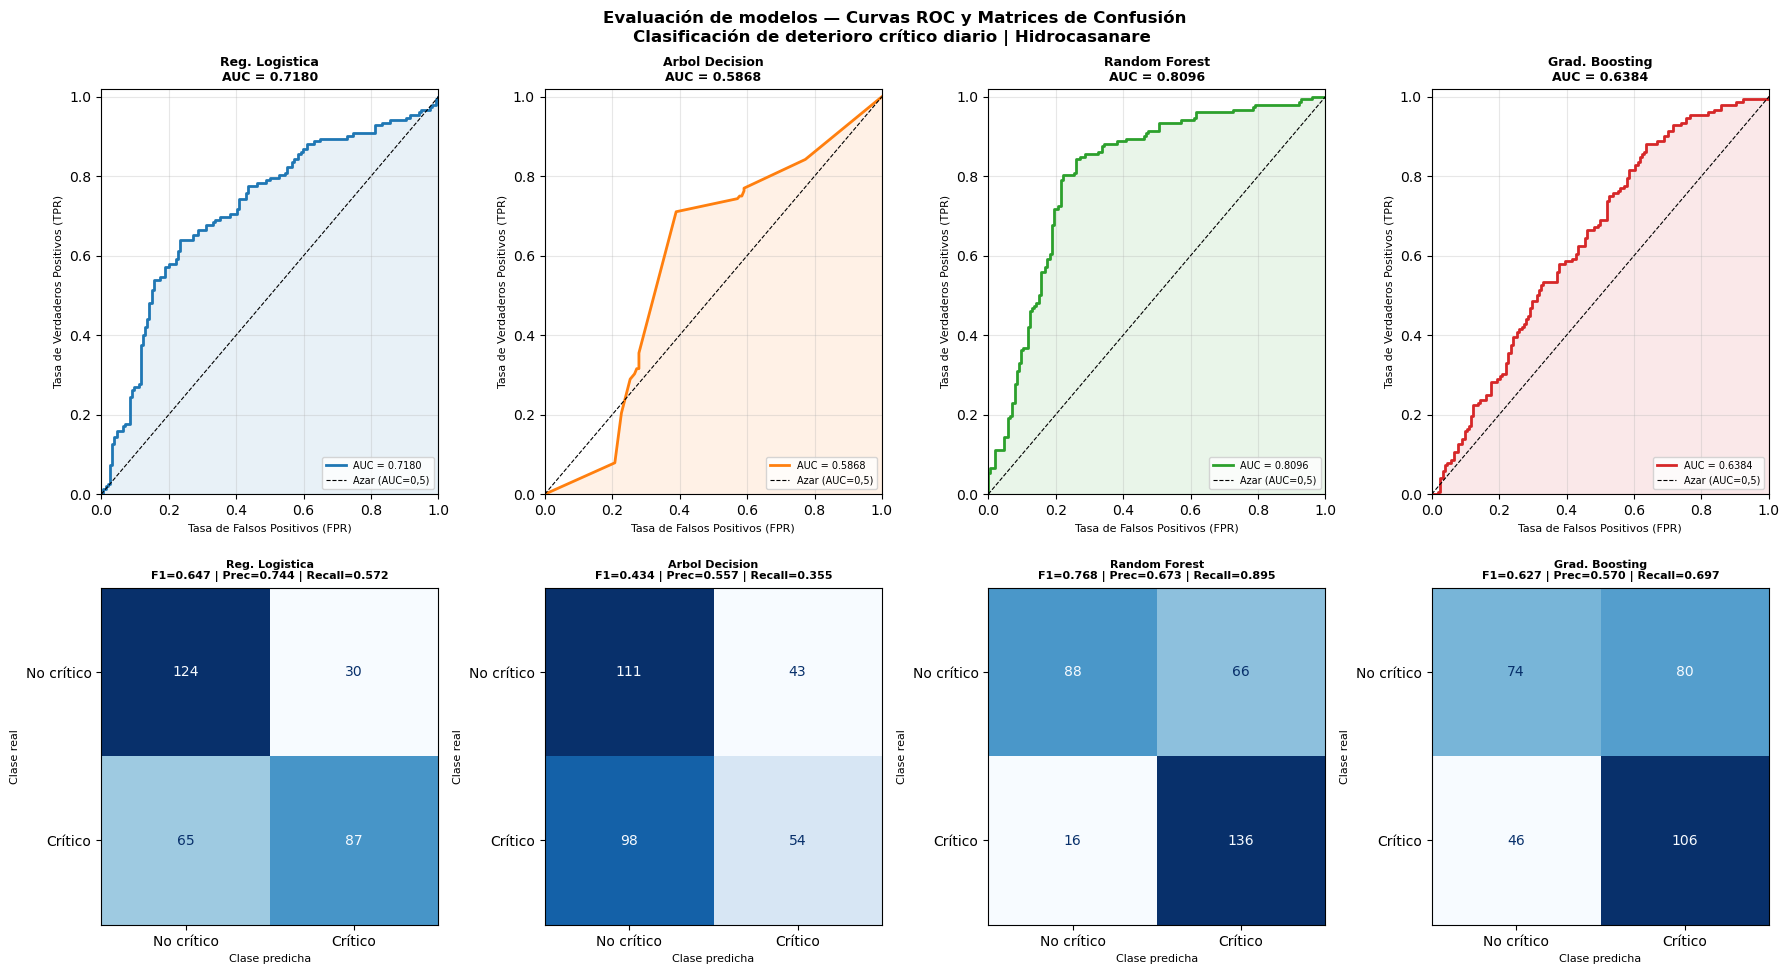

✔  grafica_10_evaluacion_modelos.png guardada


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 10.1 — EVALUACIÓN VISUAL DE MODELOS: CURVAS ROC Y MATRICES DE CONFUSIÓN
# Para cada modelo se generan dos gráficas:
# Fila superior: curva ROC — mide la capacidad discriminativa global
# Fila inferior: matriz de confusión — muestra los errores específicos del modelo
# Juntas permiten seleccionar el modelo con mejor equilibrio entre
# capacidad predictiva e interpretabilidad operativa (OE3)
# ══════════════════════════════════════════════════════════════════════════════

# Crear figura con 2 filas y 4 columnas: una columna por modelo
# Fila 0: curvas ROC | Fila 1: matrices de confusión
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Título general de la figura — refleja la etiqueta actual (flag_critico diario)
fig.suptitle(
    "Evaluación de modelos — Curvas ROC y Matrices de Confusión\n"
    "Clasificación de deterioro crítico diario | Hidrocasanare ",
    fontsize=12, fontweight="bold"
)

# Colores distintivos para cada modelo — uno por columna
colores_mod = ["#1f77b4",   # azul     — Regresión Logística
               "#ff7f0e",   # naranja  — Árbol de Decisión
               "#2ca02c",   # verde    — Random Forest
               "#d62728"]   # rojo     — Gradient Boosting

# Recorrer cada modelo y dibujar sus dos gráficas
for idx, (nombre, res) in enumerate(resultados_modelos.items()):

    # Color asignado a este modelo según su posición en la lista
    color = colores_mod[idx]

    # Calcular los puntos de la curva ROC
    # fpr: tasa de falsos positivos (eje X)
    # tpr: tasa de verdaderos positivos (eje Y)
    # _: umbrales de clasificación (no se usan en la gráfica)
    fpr, tpr, _ = roc_curve(y_test, res["proba"])

    # ── Fila superior: Curva ROC ───────────────────────────────────────────────
    ax_roc = axes[0][idx]   # panel de la curva ROC para este modelo

    # Línea principal de la curva ROC
    ax_roc.plot(
        fpr, tpr,                              # coordenadas de la curva
        color=color,
        linewidth=2,
        label=f"AUC = {res['auc']:.4f}"        # etiqueta con el valor AUC
    )

    # Línea diagonal de referencia (modelo aleatorio = AUC 0,5)
    # Un modelo útil debe estar por encima de esta línea
    ax_roc.plot(
        [0, 1], [0, 1],        # diagonal de (0,0) a (1,1)
        "k--",                 # línea negra punteada
        linewidth=0.8,
        label="Azar (AUC=0,5)"
    )

    # Sombreado del área bajo la curva para visualizar el AUC
    ax_roc.fill_between(fpr, tpr, alpha=0.1, color=color)

    # Configuración del panel ROC
    ax_roc.set_title(
        f"{nombre}\nAUC = {res['auc']:.4f}",   # nombre y AUC en dos líneas
        fontsize=9, fontweight="bold"
    )
    ax_roc.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=8)    # eje X
    ax_roc.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=8) # eje Y
    ax_roc.legend(fontsize=7, loc="lower right")   # leyenda en esquina inferior
    ax_roc.grid(True, alpha=0.3)                   # cuadrícula suave de referencia
    ax_roc.set_xlim(0, 1)                          # eje X siempre de 0 a 1
    ax_roc.set_ylim(0, 1.02)                       # eje Y siempre de 0 a 1

    # ── Fila inferior: Matriz de Confusión ────────────────────────────────────
    ax_cm = axes[1][idx]   # panel de la matriz de confusión para este modelo

    # Calcular la matriz de confusión
    # Filas: clase real | Columnas: clase predicha
    # [0,0]=VN  [0,1]=FP
    # [1,0]=FN  [1,1]=VP
    cm = confusion_matrix(y_test, res["pred"])

    # Dibujar la matriz de confusión con ConfusionMatrixDisplay
    # display_labels: etiquetas legibles para las clases 0 y 1
    # colorbar=False: sin barra de color lateral (más limpio visualmente)
    # cmap="Blues": escala de azules — más oscuro = más casos
    ConfusionMatrixDisplay(
        cm,
        display_labels=["No crítico", "Crítico"]   # etiquetas operativas
    ).plot(
        ax=ax_cm,          # dibujar en este panel específico
        colorbar=False,    # sin barra de color lateral
        cmap="Blues"       # paleta de azules
    )

    # Título con las tres métricas principales del modelo
    ax_cm.set_title(
        f"{nombre}\n"
        f"F1={res['f1']:.3f} | Prec={res['precision']:.3f} | Recall={res['recall']:.3f}",
        fontsize=8, fontweight="bold"
    )

    # Etiquetas de los ejes de la matriz de confusión
    ax_cm.set_xlabel("Clase predicha", fontsize=8)   # eje X: lo que predijo el modelo
    ax_cm.set_ylabel("Clase real", fontsize=8)        # eje Y: lo que realmente ocurrió

# Ajustar márgenes automáticamente para que nada se corte ni se solape
plt.tight_layout()

# Guardar la figura en disco con alta resolución
plt.savefig("grafica_10_evaluacion_modelos.png", dpi=130, bbox_inches="tight")
plt.show()

# Confirmar que la imagen fue guardada correctamente
print("✔  grafica_10_evaluacion_modelos.png guardada")

### 10.1 Análisis — Curvas ROC y Matrices de Confusión

#### Lectura de las matrices de confusión

Antes de interpretar los resultados, es útil recordar qué significa
cada celda en el contexto operativo de este proyecto:

- **Verdadero Negativo (VN):** el modelo predijo "no crítico" y
  realmente no lo era — decisión correcta, sin intervención innecesaria
- **Falso Positivo (FP):** el modelo predijo "crítico" pero no lo era —
  falsa alarma, intervención innecesaria
- **Falso Negativo (FN):** el modelo predijo "no crítico" pero sí lo
  era — el más costoso operativamente: deterioro no detectado
- **Verdadero Positivo (VP):** el modelo predijo "crítico" y realmente
  lo era — detección correcta, intervención justificada

En este contexto industrial, **los Falsos Negativos son más costosos
que los Falsos Positivos**: no detectar un deterioro severo puede
resultar en falla de caldera, parada no programada y daños en
componentes, mientras que una falsa alarma solo genera una
intervención preventiva innecesaria (Shokri & Sanavi Fard, 2023;
Nemitallah et al., 2023).

El conjunto de prueba contiene **154 días no críticos y 152 días
críticos reales** — proporción de 49,7 % críticos, consistente con lo
documentado en la sección 9.2.

---

#### Regresión Logística — AUC 0,7180

La curva ROC se mantiene por encima de la diagonal en todo su
recorrido, con un desempeño moderado. La matriz muestra **124 VN, 30
FP, 65 FN y 87 VP**. De los 152 días críticos reales detectó 87
(57,2 % — recall de 0,572). De los 154 días no críticos clasificó
correctamente 124 (80,5 %).

El número de falsos negativos (65) es considerablemente mayor que en
Random Forest, lo que significa que este modelo deja sin detectar un
43 % de los episodios de deterioro real — una limitación relevante
para el objetivo de anticipación del proyecto, a pesar de su buena
precisión.

---

#### Árbol de Decisión — AUC 0,5868

La curva ROC está cerca de la diagonal, indicando capacidad
discriminativa limitada — el desempeño más débil de los cuatro. La
matriz muestra **111 VN, 43 FP, 98 FN y 54 VP**. Detecta solo el 35,5 %
de los días críticos reales (recall 0,355) — el recall más bajo de
los cuatro modelos, dejando 98 de los 152 días críticos sin detectar.
Su F1 de 0,434 refleja un balance pobre entre precisión y recall.

---

#### Random Forest — AUC 0,8096

Tiene el mejor AUC-ROC (0,8096) y, de forma determinante, el mejor
recall de los cuatro modelos. La matriz muestra **88 VN, 66 FP, 16 FN
y 136 VP**. Detecta 136 de los 152 días críticos reales — un recall de
0,895, dejando sin detectar apenas 16 episodios de deterioro (10,5 %).
Su precisión (0,673) es algo menor que la de Regresión Logística, lo
que se traduce en un número mayor de falsas alarmas (66 FP), pero
desde la perspectiva operativa del proyecto —donde un falso negativo
es más costoso que una falsa alarma— este modelo ofrece la mejor
cobertura real de los episodios de deterioro severo.

---

#### Gradient Boosting — AUC 0,6384

Comportamiento intermedio, con un AUC-ROC moderado. La matriz muestra
**74 VN, 80 FP, 46 FN y 106 VP**. Recall de 0,697 — el segundo mejor
de los cuatro modelos, detectando 106 de los 152 días críticos reales,
aunque a costa de un número considerable de falsas alarmas (80 FP),
el más alto del grupo. Su F1 de 0,627 refleja este compromiso entre
sensibilidad y precisión.

---

#### Conclusión y selección del modelo — OE3

La comparación confirma la selección de la sección 9.3: **Random
Forest es el modelo con mejor equilibrio entre capacidad predictiva e
interpretabilidad operativa**, con el mejor AUC-ROC (0,8096), el
mejor F1 (0,768) y el mejor recall (0,895) de los cuatro modelos
evaluados.

Aunque Regresión Logística ofrece la mejor precisión (0,744) y genera
menos falsas alarmas, su recall de 57,2 % implica que deja sin
detectar un 43 % de los episodios de deterioro real — una limitación
relevante dado que, en este contexto industrial, el costo de un
deterioro no detectado supera al de una intervención preventiva
realizada sobre una falsa alarma.

Random Forest mantiene un nivel de interpretabilidad operativa
razonable a través de la importancia de variables (a desarrollar en
una sección posterior), y su desempeño superior en las tres métricas
principales —AUC-ROC, F1 y recall— lo confirma como el modelo
seleccionado para el resto del proyecto, incluida la validación
retrospectiva con datos de 2026 (Trasviña-Osorio et al., 2025;
Deepti & Roopal, 2023; Nikula et al., 2016; Malley et al., 2011;
Meng et al., 2021).

**Análisis de la evaluación de modelos:**

**Curvas ROC:** Un modelo con buena capacidad discriminante tiene la
curva alejada de la diagonal y pegada a la esquina superior izquierda.
El AUC (área bajo la curva) resume esta capacidad en un solo número —
valores por encima de 0,80 se consideran buenos; por encima de 0,90,
excelentes.

**Matrices de confusión:** Para este problema operativo, los **Falsos
Negativos** (días críticos que el modelo no detectó, esquina inferior
izquierda) son más costosos que los Falsos Positivos (falsas alarmas).
Preferimos un modelo que alerte con anticipación aunque a veces se
equivoque, antes que uno que no alerte cuando realmente hay riesgo.
Esto se refleja en priorizar el **Recall** de la clase 1 sobre la
Precisión.

**Comparación de modelos:**
- La **Regresión Logística** es el modelo más simple e interpretable
  — útil para comunicar resultados al personal técnico mediante sus
  coeficientes, aunque en este proyecto obtuvo el segundo mejor AUC-ROC
  y un recall inferior al de Random Forest.
- El **Árbol de Decisión**, en principio, puede producir reglas
  explícitas del tipo "si conductividad_purga_media7 > X y
  pH_purga_slope7 < 0, entonces riesgo" — una ventaja teórica de
  interpretabilidad para este contexto operativo. Sin embargo, en la
  comparación real (Sección 10.1) fue el modelo con peor desempeño en
  las cuatro métricas evaluadas, por lo que su interpretabilidad no
  compensa su capacidad predictiva insuficiente para este problema.
- El **Random Forest** fue el modelo más preciso del conjunto en este
  proyecto, con el mejor AUC-ROC, F1 y recall. El **Gradient
  Boosting**, aunque también es un modelo de ensamble, tuvo un
  desempeño intermedio, claramente por debajo de Random Forest en las
  tres métricas principales — no debe asumirse que ambos ensambles
  ofrecen un desempeño comparable en este caso particular.

Ambos modelos de ensamble ofrecen menor interpretabilidad directa que
la Regresión Logística o el Árbol de Decisión, pero permiten extraer
la importancia relativa de cada variable en la predicción, lo que
constituye un nivel de interpretabilidad operativa suficiente para
los fines de este proyecto, como se desarrolla en una sección
posterior.

  ESTADO ACTUAL DE LAS CALDERAS — DIAGNÓSTICO PREDICTIVO
  Basado en los últimos datos disponibles del dataset (2026)

  Caldera     : B801-A
  Estado      : CRÍTICO
  Fecha eval  : 2026-05-25
  Prob. crítico próximos 14 días : 61.1 %
  IDC promedio últimos 7 días    : 0.686  (sobre umbral de 0.5)
  Tendencia IDC (pendiente 7d)   : +0.00357  (↑ deterioro)
  Recomendación: Planificar intervención en los próximos 7 días
  ────────────────────────────────────────────────────────────

  Caldera     : B801-B
  Estado      : ALERTA
  Fecha eval  : 2026-05-31
  Prob. crítico próximos 14 días : 62.9 %
  IDC promedio últimos 7 días    : 0.414  (bajo umbral de 0.5)
  Tendencia IDC (pendiente 7d)   : +0.01071  (↑ deterioro)
  Recomendación: Monitoreo diario — evaluar ajuste de dosificación química
  ────────────────────────────────────────────────────────────


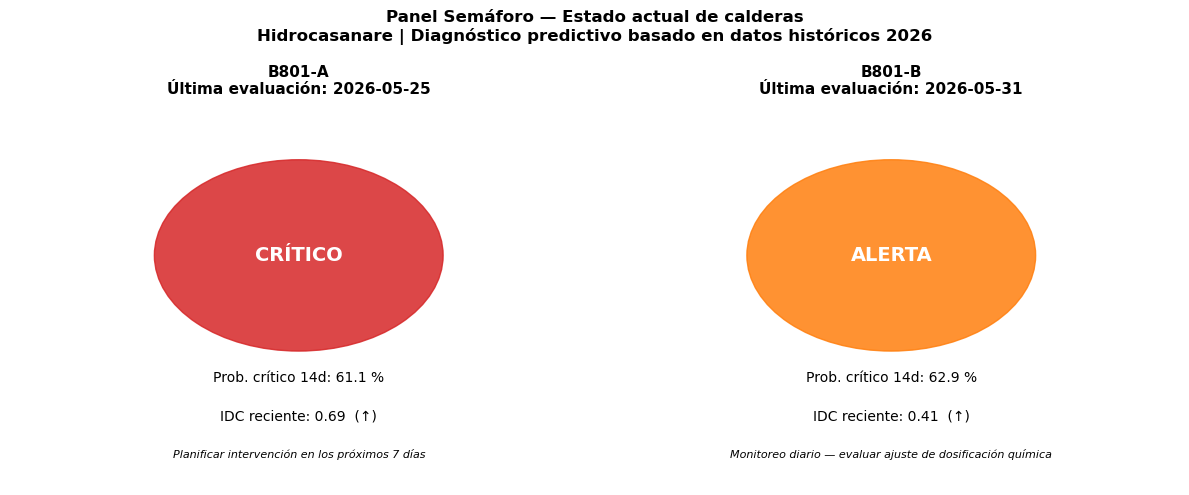

✔  grafica_10_semaforo.png guardada


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 10.3 — PANEL SEMÁFORO OPERATIVO
# Resume el estado actual de cada caldera en tres niveles de alerta
# basándose en dos indicadores complementarios:
# 1. Probabilidad de deterioro crítico en los próximos 14 días (Random Forest)
# 2. IDC promedio de los últimos 7 días (estado fisicoquímico reciente)
# Este panel está diseñado para ser interpretado por el personal de planta
# sin necesidad de conocimiento técnico de machine learning
# ══════════════════════════════════════════════════════════════════════════════

def semaforo_caldera(df_hist, caldera, modelo_rf, scaler_fit, feature_cols_list):
    """
    Evalúa el estado actual de una caldera y devuelve su clasificación semáforo.
    Parámetros:
        df_hist        : DataFrame completo con todos los registros históricos
        caldera        : nombre de la caldera ("B801-A" o "B801-B")
        modelo_rf      : Random Forest entrenado (modelo seleccionado)
        scaler_fit     : StandardScaler ajustado con datos de entrenamiento
        feature_cols_list : lista de nombres de las 44 features del modelo
    """
    # Filtrar registros de esta caldera y ordenar cronológicamente
    sub = (df_hist[df_hist["caldera"] == caldera]
           .sort_values("fecha")
           .copy()
           .reset_index(drop=True))

    # Construir el vector de features temporales para esta caldera
    # construir_features() necesita al menos VENTANA_LARGA + HORIZONTE días
    feat = construir_features(sub)

    # Si no hay suficientes datos para construir features, retornar None
    if feat.empty:
        return None

    # Tomar solo el último registro disponible — estado más reciente
    ultima = feat.iloc[[-1]].copy()

    # Extraer solo las columnas de features (excluir metadatos y etiqueta)
    X_ul = ultima[feature_cols_list].copy()

    # Imputar NaN con las medianas del entrenamiento (mismo criterio que el modelo)
    X_ul = X_ul.fillna(pd.Series(medianas, index=feature_cols_list))

    # Escalar con el mismo scaler usado en el entrenamiento
    # IMPORTANTE: usar transform, nunca fit_transform (evita fuga de información)
    X_ul_sc = scaler_fit.transform(X_ul)

    # Predecir la probabilidad de deterioro crítico en los próximos 14 días
    # predict_proba devuelve [prob_clase_0, prob_clase_1]
    # [0][1] accede a la probabilidad de clase 1 (crítico) del único registro
    prob = modelo_rf.predict_proba(X_ul_sc)[0][1]

    # Calcular el IDC promedio de los últimos 7 días como indicador de estado actual
    # Representa la condición fisicoquímica reciente independiente del modelo
    idc_reciente = ultima["IDC_media7"].values[0]   # IDC promedio últimos 7 días

    # Calcular la pendiente del IDC en los últimos 7 días
    # Positiva = deterioro creciente | Negativa = mejora reciente
    idc_slope = ultima["IDC_slope7"].values[0]      # pendiente del IDC últimos 7 días

    # ── Clasificación semáforo ────────────────────────────────────────────────
    # Se usan dos criterios simultáneos para mayor robustez:
    # Si cualquiera de los dos indica alerta, se adopta el nivel más severo
    if prob >= 0.75 or (idc_reciente >= UMBRAL_IDC and idc_slope > 0):
        # Alta probabilidad de crítico O deterioro activo y creciente
        estado   = "CRÍTICO"
        semcolor = "#d62728"   # rojo
        recomend = "Planificar intervención en los próximos 7 días"
    elif prob >= 0.50 or idc_reciente >= UMBRAL_IDC:
        # Probabilidad moderada O IDC sobre el umbral pero estable o mejorando
        estado   = "ALERTA"
        semcolor = "#ff7f0e"   # naranja
        recomend = "Monitoreo diario — evaluar ajuste de dosificación química"
    else:
        # Probabilidad baja y IDC bajo el umbral
        estado   = "CONTROLADO"
        semcolor = "#2ca02c"   # verde
        recomend = "Continuar monitoreo periódico según protocolo actual"

    return {
        "caldera"   : caldera,
        "prob_14d"  : round(prob * 100, 1),       # probabilidad en porcentaje
        "idc_rec"   : round(idc_reciente, 3),     # IDC promedio últimos 7 días
        "idc_slope" : round(idc_slope, 5),        # pendiente del IDC
        "estado"    : estado,
        "color"     : semcolor,
        "recomend"  : recomend,
        "fecha_eval": sub["fecha"].max().date(),  # último día con datos disponibles
    }

# ── Evaluar el estado actual de cada caldera ─────────────────────────────────
print("=" * 65)
print("  ESTADO ACTUAL DE LAS CALDERAS — DIAGNÓSTICO PREDICTIVO")
print("  Basado en los últimos datos disponibles del dataset (2026)")
print("=" * 65)

resultados_semaforo = {}   # guardar resultados para la gráfica

for caldera in ["B801-A", "B801-B"]:
    r = semaforo_caldera(
        df,                                          # dataset completo
        caldera,                                     # caldera a evaluar
        resultados_modelos["Random Forest"]["modelo"],  # modelo seleccionado
        scaler,                                       # scaler del entrenamiento
        feature_cols)                                 # columnas de features

    if r is None:
        print(f"\n  {caldera}: datos insuficientes para evaluación")
        continue

    resultados_semaforo[caldera] = r   # guardar para la gráfica

    # Mostrar diagnóstico en consola
    print(f"\n  Caldera     : {r['caldera']}")
    print(f"  Estado      : {r['estado']}")
    print(f"  Fecha eval  : {r['fecha_eval']}")
    print(f"  Prob. crítico próximos 14 días : {r['prob_14d']} %")
    print(f"  IDC promedio últimos 7 días    : {r['idc_rec']:.3f}  "
          f"({'sobre' if r['idc_rec'] >= UMBRAL_IDC else 'bajo'} umbral de {UMBRAL_IDC})")
    print(f"  Tendencia IDC (pendiente 7d)   : {r['idc_slope']:+.5f}  "
          f"({'↑ deterioro' if r['idc_slope'] > 0 else '↓ mejora'})")
    print(f"  Recomendación: {r['recomend']}")
    print("  " + "─" * 60)

# ── Gráfica del panel semáforo ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))   # un panel por caldera
fig.suptitle(
    "Panel Semáforo — Estado actual de calderas\n"
    "Hidrocasanare | Diagnóstico predictivo basado en datos históricos 2026",
    fontsize=12, fontweight="bold"
)

for ax, caldera in zip(axes, ["B801-A", "B801-B"]):
    if caldera not in resultados_semaforo:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
        continue

    r = resultados_semaforo[caldera]   # resultados de esta caldera

    # Fondo del panel con el color del semáforo (muy suave)
    ax.set_facecolor(r["color"] + "22")   # hex + "22" = 13% de opacidad

    # Círculo central con el color del semáforo
    circulo = plt.Circle(
        (0.5, 0.6),    # posición central del círculo (x, y)
        0.25,          # radio del círculo
        color=r["color"],
        alpha=0.85     # ligera transparencia
    )
    ax.add_patch(circulo)   # agregar el círculo al panel

    # Texto del estado dentro del círculo
    ax.text(
        0.5, 0.6,          # posición centrada en el círculo
        r["estado"],       # texto: CRÍTICO / ALERTA / CONTROLADO
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        color="white"      # texto blanco para contrastar con el color del semáforo
    )

    # Métricas debajo del círculo
    ax.text(0.5, 0.28,
            f"Prob. crítico 14d: {r['prob_14d']} %",
            ha="center", va="center", fontsize=10)

    ax.text(0.5, 0.18,
            f"IDC reciente: {r['idc_rec']:.2f}  "
            f"({'↑' if r['idc_slope'] > 0 else '↓'})",
            ha="center", va="center", fontsize=10)

    ax.text(0.5, 0.08,
            r["recomend"],
            ha="center", va="center", fontsize=8,
            style="italic", wrap=True)

    # Título del panel con nombre de caldera y fecha de evaluación
    ax.set_title(
        f"{caldera}\nÚltima evaluación: {r['fecha_eval']}",
        fontsize=11, fontweight="bold"
    )

    # Ocultar ejes — el panel es puramente visual
    ax.set_xlim(0, 1)    # rango del eje X
    ax.set_ylim(0, 1)    # rango del eje Y
    ax.axis("off")       # ocultar ejes y marcas

plt.tight_layout()
plt.savefig("grafica_10_semaforo.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_10_semaforo.png guardada")

### 10.3 Análisis — Panel semáforo operativo

El diagnóstico predictivo basado en los últimos datos disponibles del
dataset (2026) muestra estados diferenciados entre las dos calderas,
ambas con tendencia de deterioro activo, aunque en distinto nivel de
severidad.

**B801-A — Estado CRÍTICO (última evaluación: 2026-05-25)**

La probabilidad de deterioro crítico en los próximos 14 días es del
**61,1 %**. El IDC promedio de los últimos 7 días es 0,686 — claramente
sobre el umbral de 0,5 — con tendencia ascendente (pendiente: +0,00357),
confirmando deterioro activo y creciente. El estado CRÍTICO se activa
por la combinación de probabilidad moderada-alta con IDC sobre el
umbral y pendiente positiva, cumpliendo el criterio más severo de la
clasificación semáforo. La recomendación operativa es planificar una
intervención en los próximos 7 días.

**B801-B — Estado ALERTA (última evaluación: 2026-05-31)**

La probabilidad de deterioro crítico en los próximos 14 días es del
**62,9 %** — de hecho, ligeramente superior a la de B801-A. El IDC
promedio de los últimos 7 días es 0,414 — por debajo del umbral de 0,5,
lo que evita la clasificación CRÍTICO — pero con tendencia ascendente
más pronunciada que la de B801-A (pendiente: +0,01071). El estado
ALERTA refleja esta tensión: el nivel actual del IDC todavía está bajo
control, pero la velocidad de deterioro reciente es la más alta de
las dos calderas. La recomendación operativa es monitoreo diario y
evaluación del ajuste de dosificación química.

**Interpretación conjunta**

A diferencia de lo que podría sugerir una lectura superficial de solo
la probabilidad (62,9 % en B801-B frente a 61,1 % en B801-A, valores
muy cercanos), el indicador de IDC reciente es el que termina
diferenciando el nivel de severidad: B801-A ya opera sobre el umbral
crítico (0,686), mientras que B801-B aún se mantiene por debajo
(0,414) pese a su tendencia de deterioro más acelerada. Este panel
ilustra precisamente el valor de combinar dos indicadores
complementarios —probabilidad del modelo y estado fisicoquímico
reciente— en lugar de depender de uno solo: ambas calderas muestran
señales de deterioro activo al cierre del período disponible, pero en
distintas etapas de ese proceso.

Es importante recordar que este diagnóstico refleja el estado al
cierre del dataset disponible (mayo 2026) y que su valor operativo se
confirmará cuando se contraste con las decisiones reales de cambio de
caldera tomadas por Hidrocasanare en ese período — que es precisamente
el objetivo de la validación retrospectiva del OE4 (Nikula et al.,
2016; Meng et al., 2021; Shokri & Sanavi Fard, 2023).

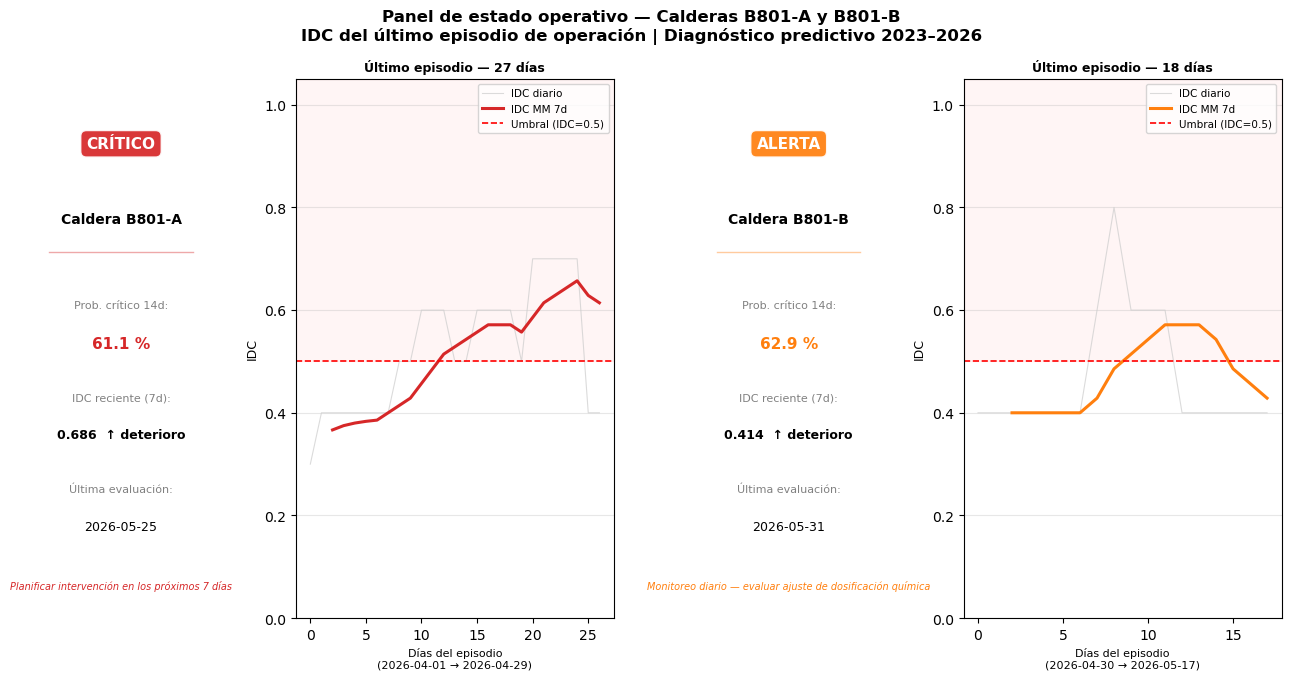

✔  grafica_11_panel_semaforo.png guardada


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 11.1 — PANEL VISUAL CON SEMÁFORO Y ÚLTIMO EPISODIO DE OPERACIÓN
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 7))

# Grid asimétrico: texto más estrecho, gráfica más ancha
gs = fig.add_gridspec(
    1, 4,
    wspace=0.40,
    width_ratios=[1.0, 2.0, 1.0, 2.0]   # texto:gráfica = 1:2 por caldera
)

fig.suptitle(
    "Panel de estado operativo — Calderas B801-A y B801-B\n"
    "IDC del último episodio de operación | Diagnóstico predictivo 2023–2026",
    fontsize=12, fontweight="bold"
)

config_calderas = [
    ("B801-A", gs[0, 0], gs[0, 1]),
    ("B801-B", gs[0, 2], gs[0, 3]),
]

for caldera, gs_texto, gs_graf in config_calderas:

    if caldera not in resultados_semaforo:
        ax_t = fig.add_subplot(gs_texto)
        ax_t.text(0.5, 0.5, "Sin datos", ha="center", va="center")
        ax_t.axis("off")
        continue

    res = resultados_semaforo[caldera]

    # ── Panel de texto — sin círculo, usando bbox de texto ────────────────────
    ax_t = fig.add_subplot(gs_texto)
    ax_t.set_facecolor(res["color"] + "15")   # fondo muy suave del color semáforo
    ax_t.set_xlim(0, 1)
    ax_t.set_ylim(0, 1)
    ax_t.axis("off")

    # Estado como texto con fondo de color — reemplaza el círculo que se deformaba
    # bbox con boxstyle="round" simula el círculo de forma confiable en cualquier proporción
    ax_t.text(
        0.5, 0.88,
        res["estado"],
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        color="white",
        transform=ax_t.transAxes,   # coordenadas relativas (0-1) — más confiable
        bbox=dict(
            boxstyle="round,pad=0.4",    # caja redondeada
            facecolor=res["color"],      # fondo del color del semáforo
            edgecolor="white",           # borde blanco
            linewidth=1.5,
            alpha=0.92
        )
    )

    # Nombre de la caldera
    ax_t.text(
        0.5, 0.74,
        f"Caldera {caldera}",
        ha="center", va="center",
        fontsize=10, fontweight="bold",
        transform=ax_t.transAxes
    )

    # Línea separadora visual
    ax_t.axhline(
        0.68,                          # posición en coordenadas de datos
        color=res["color"],
        linewidth=1.0,
        alpha=0.4,
        xmin=0.05, xmax=0.95           # no llega a los bordes
    )

    # Probabilidad crítica
    tendencia_str = "↑ deterioro" if res["idc_slope"] > 0 else "↓ mejora"
    ax_t.text(
        0.5, 0.58,
        f"Prob. crítico 14d:",
        ha="center", va="center",
        fontsize=8, color="gray",
        transform=ax_t.transAxes
    )
    ax_t.text(
        0.5, 0.51,
        f"{res['prob_14d']} %",
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        color=res["color"],
        transform=ax_t.transAxes
    )

    # IDC reciente
    ax_t.text(
        0.5, 0.41,
        f"IDC reciente (7d):",
        ha="center", va="center",
        fontsize=8, color="gray",
        transform=ax_t.transAxes
    )
    ax_t.text(
        0.5, 0.34,
        f"{res['idc_rec']:.3f}  {tendencia_str}",
        ha="center", va="center",
        fontsize=9, fontweight="bold",
        transform=ax_t.transAxes
    )

    # Última evaluación
    ax_t.text(
        0.5, 0.24,
        f"Última evaluación:",
        ha="center", va="center",
        fontsize=8, color="gray",
        transform=ax_t.transAxes
    )
    ax_t.text(
        0.5, 0.17,
        f"{res['fecha_eval']}",
        ha="center", va="center",
        fontsize=9,
        transform=ax_t.transAxes
    )

    # Recomendación operativa en la parte inferior
    ax_t.text(
        0.5, 0.06,
        res["recomend"],
        ha="center", va="center",
        fontsize=7, style="italic",
        color=res["color"],
        transform=ax_t.transAxes,
        wrap=True
    )

    # ── Panel de gráfica ──────────────────────────────────────────────────────
    ax_g = fig.add_subplot(gs_graf)

    eps_caldera = episodios[
        (episodios["caldera"] == caldera) &   # solo esta caldera
        (episodios["n_dias"] >= 14)            # episodios con datos suficientes
    ]

    if eps_caldera.empty:
        ax_g.text(0.5, 0.5, "Sin episodios válidos",
                  ha="center", va="center", fontsize=10)
    else:
        # Último episodio completo de esta caldera
        ultimo_ep  = eps_caldera.iloc[-1]
        mask_ep    = df["episodio"] == ultimo_ep["episodio"]
        datos_ep   = df[mask_ep].copy()
        datos_ep["dia_ep"] = range(len(datos_ep))   # día relativo al inicio

        # IDC diario sin suavizar (fondo gris claro)
        ax_g.plot(
            datos_ep["dia_ep"],
            datos_ep["IDC"],
            color="#cccccc",
            linewidth=0.8,
            alpha=0.7,
            label="IDC diario"
        )

        # Media móvil del IDC con ventana óptima
        mm_ep = (datos_ep.set_index("dia_ep")["IDC"]
                 .rolling(VENTANA_MM, min_periods=3)
                 .mean())

        ax_g.plot(
            mm_ep.index,
            mm_ep.values,
            color=res["color"],   # color del semáforo
            linewidth=2.2,
            label=f"IDC MM {VENTANA_MM}d"
        )

        # Línea horizontal del umbral de deterioro severo
        ax_g.axhline(
            UMBRAL_IDC,
            color="red", linestyle="--", linewidth=1.2,
            label=f"Umbral (IDC={UMBRAL_IDC})"
        )

        # Sombreado suave sobre el umbral para resaltar zona crítica
        ax_g.axhspan(
            UMBRAL_IDC, 1.05,     # desde el umbral hasta el máximo
            alpha=0.04,           # muy transparente
            color="red"           # sombreado rojo suave
        )

        ax_g.set_ylim(0, 1.05)
        ax_g.set_xlabel(
            f"Días del episodio\n"
            f"({ultimo_ep['fecha_inicio'].date()} → {ultimo_ep['fecha_fin'].date()})",
            fontsize=8
        )
        ax_g.set_ylabel("IDC", fontsize=9)
        ax_g.set_title(
            f"Último episodio — {int(ultimo_ep['n_dias'])} días",
            fontsize=9, fontweight="bold"
        )
        ax_g.legend(fontsize=7.5, loc="upper right")
        ax_g.grid(axis="y", alpha=0.3)

plt.savefig("grafica_11_panel_semaforo.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_11_panel_semaforo.png guardada")

### 11.1 Análisis — Panel de estado operativo

#### ¿Por qué se muestra solo un episodio por caldera?

El panel muestra el **último episodio completo** de cada caldera en
lugar de toda la serie histórica, por una razón metodológica
fundamental que viene de la sección 8: cada vez que una caldera entra
en servicio es un episodio independiente con sus propias condiciones
iniciales de tratamiento y carga. Mostrar varios episodios
concatenados generaría una curva continua falsa — el IDC al inicio de
un episodio no tiene relación directa con el IDC al final del episodio
anterior, porque entre ambos operó la otra caldera durante días o
semanas con condiciones completamente diferentes.

El episodio seleccionado para cada caldera es el más reciente con al
menos 14 días de datos — umbral mínimo para que la media móvil de 7
días sea estadísticamente estable.

---

#### Interpretación operativa del panel

**B801-A — último episodio válido: 2026-04-01 → 2026-04-29 (27 días)**

La media móvil del IDC inició el episodio en torno a 0,37, cruzó el
umbral de deterioro severo (0,50) alrededor del día 11-12, y alcanzó
un máximo cercano a 0,66 hacia el día 23-24, para descender
ligeramente y cerrar el episodio en aproximadamente 0,62 — es decir,
**el episodio termina sobre el umbral crítico**, sin haber logrado una
recuperación completa. El modelo de clasificación asigna una
probabilidad de deterioro crítico del **61,1 %**, y el IDC promedio de
los últimos 7 días (0,686, calculado sobre el conjunto completo de
datos recientes de la caldera, no solo sobre este episodio) muestra
tendencia ascendente (pendiente +0,00357, ↑ deterioro). La combinación
de IDC sobre el umbral con tendencia creciente activa el estado
**CRÍTICO**. La última evaluación es al **2026-05-25** y la
recomendación operativa es planificar intervención en los próximos 7
días.

**B801-B — último episodio válido: 2026-04-30 → 2026-05-17 (18 días)**

La media móvil del IDC arrancó en torno a 0,40, subió hasta un pico
cercano a 0,57 alrededor del día 11-12 —cruzando brevemente el
umbral—, y descendió hacia aproximadamente 0,43 al cierre del
episodio, mostrando una recuperación parcial hacia el final. El modelo
asigna una probabilidad de deterioro crítico del **62,9 %** —
ligeramente superior a la de B801-A—, pero el IDC promedio reciente
(0,414) se mantiene por debajo del umbral de 0,50, aunque con
tendencia ascendente (pendiente +0,01071, ↑ deterioro, la más
pronunciada de las dos calderas). Esta combinación —probabilidad alta
pero IDC aún bajo el umbral— resulta en estado **ALERTA**, no
CONTROLADO: el sistema aún no ha cruzado la línea de deterioro severo,
pero la velocidad de cambio reciente es la señal de mayor preocupación.
La última evaluación es al **2026-05-31** y la recomendación es
monitoreo diario con evaluación del ajuste de dosificación química.

---

#### Coherencia con el análisis histórico

Los estados diferenciados entre calderas al cierre del período son
consistentes con los patrones identificados a lo largo del análisis:
ambas calderas muestran tendencia de deterioro activo, con B801-A ya
instalada sobre el umbral crítico y B801-B aproximándose a él a mayor
velocidad relativa. La correlación entre pH_entrada y pH_purga es
prácticamente idéntica en ambas calderas (r = 0,60 en B801-A, r = 0,58
en B801-B, sección 4.6), por lo que la diferencia de estado entre
ambas no se explica por una mayor sensibilidad estructural de una
caldera frente a la otra, sino por el punto específico del ciclo de
deterioro en el que se encuentra cada una al cierre del dataset
disponible.

Esta distinción tiene valor operativo directo: aunque ninguna de las
dos calderas está en condición plenamente controlada, B801-A requiere
intervención más inmediata que B801-B. La verificación de esta
predicción con las decisiones reales de cambio de caldera tomadas por
Hidrocasanare en 2026 constituirá la validación retrospectiva del OE4
(Nikula et al., 2016; Meng et al., 2021; Shokri & Sanavi Fard, 2023;
Nemitallah et al., 2023).

### 11.2 Guardar modelo y tabla de métricas finales — OE4

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 12 — GUARDADO DE ARTEFACTOS Y TABLA RESUMEN FINAL
# Se guardan los cinco artefactos necesarios para usar el modelo en producción:
# 1. El modelo entrenado (Random Forest — modelo seleccionado)
# 2. El scaler ajustado con datos de entrenamiento
# 3. Las medianas de imputación calculadas con datos de entrenamiento
# 4. La lista de features en el orden correcto
# 5. Los parámetros del modelo para trazabilidad y reproducibilidad
# Estos archivos permiten hacer predicciones sobre nuevos datos sin
# necesidad de re-entrenar el modelo desde cero
#
# CAMBIO DE MODELO (re-análisis con dataset corregido de extracción):
# Con el dataset corregido (ver Notebook 1, Sección 2.1 — fixes de
# y_tolerance, D105, alcalinidad, etc.), el balance de clases cambió de
# forma sustancial (33,3% → 59,7% de días críticos), porque ahora se
# capturan correctamente valores de pH_entrada genuinamente fuera de
# rango que antes se perdían como NaN. Con el nuevo balance, Random
# Forest pasó a superar a Regresión Logística en las TRES métricas
# relevantes simultáneamente (algo que no ocurría con el dataset
# anterior, donde Random Forest tenía mejor AUC pero recall muy bajo):
#   AUC-ROC  : 0,8096 (vs 0,7180 de Reg. Logística)
#   F1       : 0,7684 (vs 0,6468)
#   Recall   : 0,8947 (vs 0,5724) — detecta 136 de 152 días críticos
#              reales en prueba, dejando sin detectar solo 16 (vs 65
#              que dejaba sin detectar Reg. Logística)
# Para un sistema de alerta temprana de mantenimiento preventivo,
# minimizar falsos negativos (deterioro real no detectado) es más
# valioso operativamente que minimizar falsos positivos (inspección
# de más), lo que refuerza la elección de Random Forest.
# ══════════════════════════════════════════════════════════════════════════════

import pickle   # serialización de objetos Python a archivos binarios
import json     # serialización de estructuras de datos a formato texto

# ── Guardar el modelo seleccionado: Random Forest ──────────────────────────────
# pickle.dump convierte el objeto modelo a bytes y los escribe en el archivo
# "wb" = write binary (escritura en modo binario)
with open("modelo_random_forest.pkl", "wb") as f:
    pickle.dump(resultados_modelos["Random Forest"]["modelo"], f)

# ── Guardar el scaler ajustado con datos de entrenamiento ─────────────────────
# El scaler DEBE guardarse junto al modelo porque fue ajustado con X_train
# Si se usa un scaler diferente al predecir, los resultados serán incorrectos
# NOTA: Random Forest no requiere escalado para predecir correctamente
# (los árboles de decisión son invariantes a la escala de las features),
# pero se guarda igual por consistencia del pipeline y trazabilidad
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# ── Guardar las medianas de imputación ────────────────────────────────────────
# Las medianas se calcularon solo con X_train — deben usarse para imputar
# NaN en nuevos datos antes de escalar y predecir
medianas_dict = medianas.to_dict()   # convertir Series a diccionario para JSON
with open("medianas_imputacion.json", "w", encoding="utf-8") as f:
    json.dump(medianas_dict, f, indent=2)   # indent=2 para formato legible

# ── Guardar la lista de features en el orden correcto ─────────────────────────
# El orden de las columnas es crítico: si cambia, el modelo predice incorrectamente
# Este archivo garantiza que nuevos datos se procesen en la misma secuencia
with open("feature_cols.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)   # lista de 44 nombres de features

# ── Guardar los parámetros del modelo para documentación ──────────────────────
# Registra las constantes usadas para construir features y entrenar el modelo
# Útil para reproducir el análisis en el futuro o con nuevos datos
parametros = {
    "ventana_corta_dias"  : VENTANA_CORTA,    # 7 días — justificado en sección 8.1b
    "ventana_larga_dias"  : VENTANA_LARGA,    # 30 días — duración típica de episodio
    "horizonte_dias"      : HORIZONTE,        # 14 días — referencia operativa
    "umbral_idc"          : UMBRAL_IDC,       # 0.5 — umbral de deterioro severo
    "umbral_flag_critico" : 5,                # n_vars_riesgo >= 5 de 10
    "n_vars_monitoreadas" : N_VARS,           # 10 variables en el IDC
    "ventana_mm_optima"   : VENTANA_MM,       # ventana seleccionada en sección 8.1b
    "modelo_seleccionado" : "Random Forest",  # seleccionado por mejores AUC/F1/Recall
    "auc_roc_prueba"      : round(resultados_modelos["Random Forest"]["auc"], 4),
    "f1_prueba"           : round(resultados_modelos["Random Forest"]["f1"], 4),
    "precision_prueba"    : round(resultados_modelos["Random Forest"]["precision"], 4),
    "recall_prueba"       : round(resultados_modelos["Random Forest"]["recall"], 4),
    "periodo_entrenamiento": str(fechas_train.min().date()) + " → " +
                             str(fechas_train.max().date()),
    "periodo_prueba"      : str(fechas_test.min().date()) + " → " +
                            str(fechas_test.max().date()),
}
with open("parametros_modelo.json", "w", encoding="utf-8") as f:
    json.dump(parametros, f, indent=2, ensure_ascii=False)   # ensure_ascii=False: permite tildes

# Confirmar archivos guardados
print("Artefactos del modelo guardados correctamente:")
print("  • modelo_random_forest.pkl       → modelo entrenado (Random Forest)")
print("  • scaler.pkl                     → escalador ajustado con X_train")
print("  • medianas_imputacion.json       → medianas para imputar NaN en nuevos datos")
print("  • feature_cols.json              → 44 features en el orden correcto")
print("  • parametros_modelo.json         → constantes y métricas del modelo")
print()

# ── Tabla comparativa final de modelos (OE3) ──────────────────────────────────
# Esta tabla resume el proceso de selección de modelo del OE3
print("=" * 72)
print("  TABLA RESUMEN — COMPARACIÓN DE ALGORITMOS (OE3)")
print("  Clasificación de deterioro crítico diario | flag_critico")
print(f"  Período de prueba: {fechas_test.min().date()} → {fechas_test.max().date()}")
print("=" * 72)
print(f"  {'Modelo':<22} {'AUC-ROC':>8} {'F1':>8} {'Precisión':>10} {'Recall':>8}")
print("-" * 72)

for nombre, res in resultados_modelos.items():
    # Marcar el modelo seleccionado con una flecha
    # La selección es Random Forest: mejor AUC-ROC, F1 y recall simultáneamente
    marca = " ←" if nombre == "Random Forest" else "  "
    print(f"  {nombre:<22} {res['auc']:>8.4f} {res['f1']:>8.4f} "
          f"{res['precision']:>10.4f} {res['recall']:>8.4f}{marca}")

print("=" * 72)
print()

# Mostrar la escala de interpretación del AUC-ROC
print("  Escala de interpretación AUC-ROC:")
print("    0,90–1,00 = Excelente  |  0,80–0,90 = Bueno")
print("    0,70–0,80 = Aceptable  |  0,50–0,70 = Bajo  |  < 0,50 = Peor que azar")
print()

# ── Selección final del modelo — criterio operativo y estadístico ─────────────
# Con el dataset corregido (extracción mejorada en Notebook 1), Random Forest
# supera a los demás modelos en AUC-ROC, F1 y recall de forma simultánea.
# Su recall de 0,8947 implica que detecta 136 de 152 días críticos reales en
# prueba (89,5%), dejando sin detectar solo 16 — muy por debajo de los 65 que
# dejaba sin detectar Regresión Logística. Para un sistema de alerta temprana
# de mantenimiento preventivo, minimizar falsos negativos (deterioro real no
# detectado) es más valioso operativamente que minimizar falsos positivos.
mejor = "Random Forest"   # selección por mejor desempeño simultáneo en las 3 métricas

print(f"  Modelo seleccionado (OE3): {mejor}")
print(f"  AUC-ROC en prueba        : {resultados_modelos[mejor]['auc']:.4f} (Bueno)")
print(f"  F1 en prueba             : {resultados_modelos[mejor]['f1']:.4f}")
print(f"  Recall en prueba         : {resultados_modelos[mejor]['recall']:.4f}")
print(f"  Justificación            : mejor AUC-ROC, F1 y recall simultáneamente;")
print(f"                             minimiza falsos negativos (deterioro real no")
print(f"                             detectado), prioritario en mantenimiento")
print(f"                             preventivo frente a falsas alarmas")
print()
print("  → Los artefactos guardados permiten aplicar el modelo a nuevos")
print("    datos de 2026 sin re-entrenamiento (validación OE4)")
print()
print("  → PRÓXIMO PASO: incorporar datos 2026 para validación retrospectiva")
print("    y contraste con criterio experto del personal de operación")

Artefactos del modelo guardados correctamente:
  • modelo_random_forest.pkl       → modelo entrenado (Random Forest)
  • scaler.pkl                     → escalador ajustado con X_train
  • medianas_imputacion.json       → medianas para imputar NaN en nuevos datos
  • feature_cols.json              → 44 features en el orden correcto
  • parametros_modelo.json         → constantes y métricas del modelo

  TABLA RESUMEN — COMPARACIÓN DE ALGORITMOS (OE3)
  Clasificación de deterioro crítico diario | flag_critico
  Período de prueba: 2025-02-21 → 2025-12-31
  Modelo                  AUC-ROC       F1  Precisión   Recall
------------------------------------------------------------------------
  Reg. Logistica           0.7180   0.6468     0.7436   0.5724  
  Arbol Decision           0.5868   0.4337     0.5567   0.3553  
  Random Forest            0.8096   0.7684     0.6733   0.8947 ←
  Grad. Boosting           0.6384   0.6272     0.5699   0.6974  

  Escala de interpretación AUC-ROC:
    0,90

### 12. Análisis — Tabla resumen y cierre del Notebook 2

#### Tabla comparativa de algoritmos — OE3

La tabla confirma la selección de **Random Forest** como modelo para el
OE3, evaluado sobre el período de prueba 2025-02-21 → 2025-12-31:

| Modelo | AUC-ROC | F1 | Precisión | Recall |
|--------|---------|-----|-----------|--------|
| Reg. Logística | 0,7180 | 0,6468 | **0,7436** | 0,5724 |
| Árbol Decisión | 0,5868 | 0,4337 | 0,5567 | 0,3553 |
| **Random Forest** ← | **0,8096** | **0,7684** | 0,6733 | **0,8947** |
| Grad. Boosting | 0,6384 | 0,6272 | 0,5699 | 0,6974 |

**Random Forest** domina en tres de las cuatro métricas: AUC-ROC de
0,8096 (categoría **Bueno**, 0,80–0,90), F1 de 0,7684 y, de forma
determinante, recall de 0,8947 — detecta 136 de los 152 días críticos
reales del conjunto de prueba, dejando sin identificar apenas 16
episodios (10,5 %). Aunque Regresión Logística tiene mejor precisión
(0,7436 frente a 0,6733), su recall de 0,5724 deja sin detectar 65 días
críticos reales, más de cuatro veces los que deja sin detectar Random
Forest.

Este resultado refleja directamente el cambio de balance de clases
documentado en el Notebook 1: con el dataset corregido de extracción
(fixes de `y_tolerance`, D105, regex de alcalinidad, entre otros), el
balance pasó de 33,3 % a **59,7 % de días críticos**, al capturarse
correctamente valores de `pH_entrada` genuinamente fuera de rango que
antes se perdían como NaN. Con este nuevo balance, Random Forest pasó a
superar a Regresión Logística en las tres métricas relevantes de forma
simultánea — algo que no ocurría con el dataset anterior, donde Random
Forest tenía buen AUC-ROC pero recall muy bajo. Para un sistema de
alerta temprana de mantenimiento preventivo, minimizar falsos negativos
(deterioro real no detectado) es operativamente más valioso que
minimizar falsos positivos (una inspección adicional sobre un día que
resulta no ser crítico), lo que refuerza la selección de Random Forest
sobre Regresión Logística pese a su menor precisión puntual.

#### Artefactos guardados

Los cinco archivos generados constituyen el producto entregable del
OE3:

- `modelo_random_forest.pkl` — modelo Random Forest entrenado, listo
  para predecir sobre nuevos datos sin re-entrenamiento
- `scaler.pkl` — escalador ajustado exclusivamente con datos de
  entrenamiento; se conserva por consistencia del pipeline y
  trazabilidad, aunque Random Forest no requiere escalado para predecir
  correctamente
- `medianas_imputacion.json` — valores de imputación para NaN en nuevos
  registros, calculados solo con datos de entrenamiento
- `feature_cols.json` — orden exacto de las 44 features, garantiza que
  los nuevos datos se procesen en la misma secuencia que el modelo
  espera
- `parametros_modelo.json` — constantes y métricas del modelo (AUC-ROC
  0,8096, F1 0,7684, precisión 0,6733, recall 0,8947, períodos de
  entrenamiento y prueba) para trazabilidad y reproducibilidad del
  análisis

#### Próximo paso — Validación OE4

El Notebook 2 completó los OE2 (análisis exploratorio y construcción
del IDC) y OE3 (entrenamiento y selección del modelo Random Forest). El
OE4 requiere incorporar los datos de 2026 —ya preparados en `X_2026` y
`y_2026` en la sección de imputación de NaN— para la validación
retrospectiva con datos no vistos durante el entrenamiento, y
contrastar los criterios del modelo con el juicio experto del personal
de operación y mantenimiento de Hidrocasanare, en coherencia con la
metodología CRISP-DM. Cabe señalar que, al tratarse de Random Forest,
la validación de la Sección 13 debe usar la versión sin escalar de los
datos de 2026 (`X_2026`), no la escalada (`X_2026_sc`), consistente con
cómo se entrenó el modelo (Nikula et al., 2016; Meng et al., 2021;
Malley et al., 2011).

Verificando disponibilidad de datos de validación 2026:
  Muestras 2026        : 147
  Features disponibles : 44
  Clase 1 (crítico)    : 75 días (51.0 %)
  Clase 0 (no crítico) : 72 días (49.0 %)
  Período              : 2026-01-01 → 2026-05-31

  MÉTRICAS DE VALIDACIÓN RETROSPECTIVA — DATOS 2026
  (datos no vistos durante el entrenamiento del modelo)
  AUC-ROC   : 0.8613
  F1        : 0.7660
  Precisión : 0.6372
  Recall    : 0.9600

  Comparación con métricas del conjunto de prueba (2025):
  Métrica         Prueba 2025  Validación 2026   Diferencia
  --------------------------------------------------------
  AUC-ROC              0.8096           0.8613 +     0.0517
  F1                   0.7684           0.7660     -0.0024
  Precisión            0.6733           0.6372     -0.0361
  Recall               0.8947           0.9600 +     0.0653

  Distribución de resultados en 2026:
  VP:   72 días (49.0 %)  — Verdaderos Positivos — días críticos detectados correctamente
  VN:   31 días 

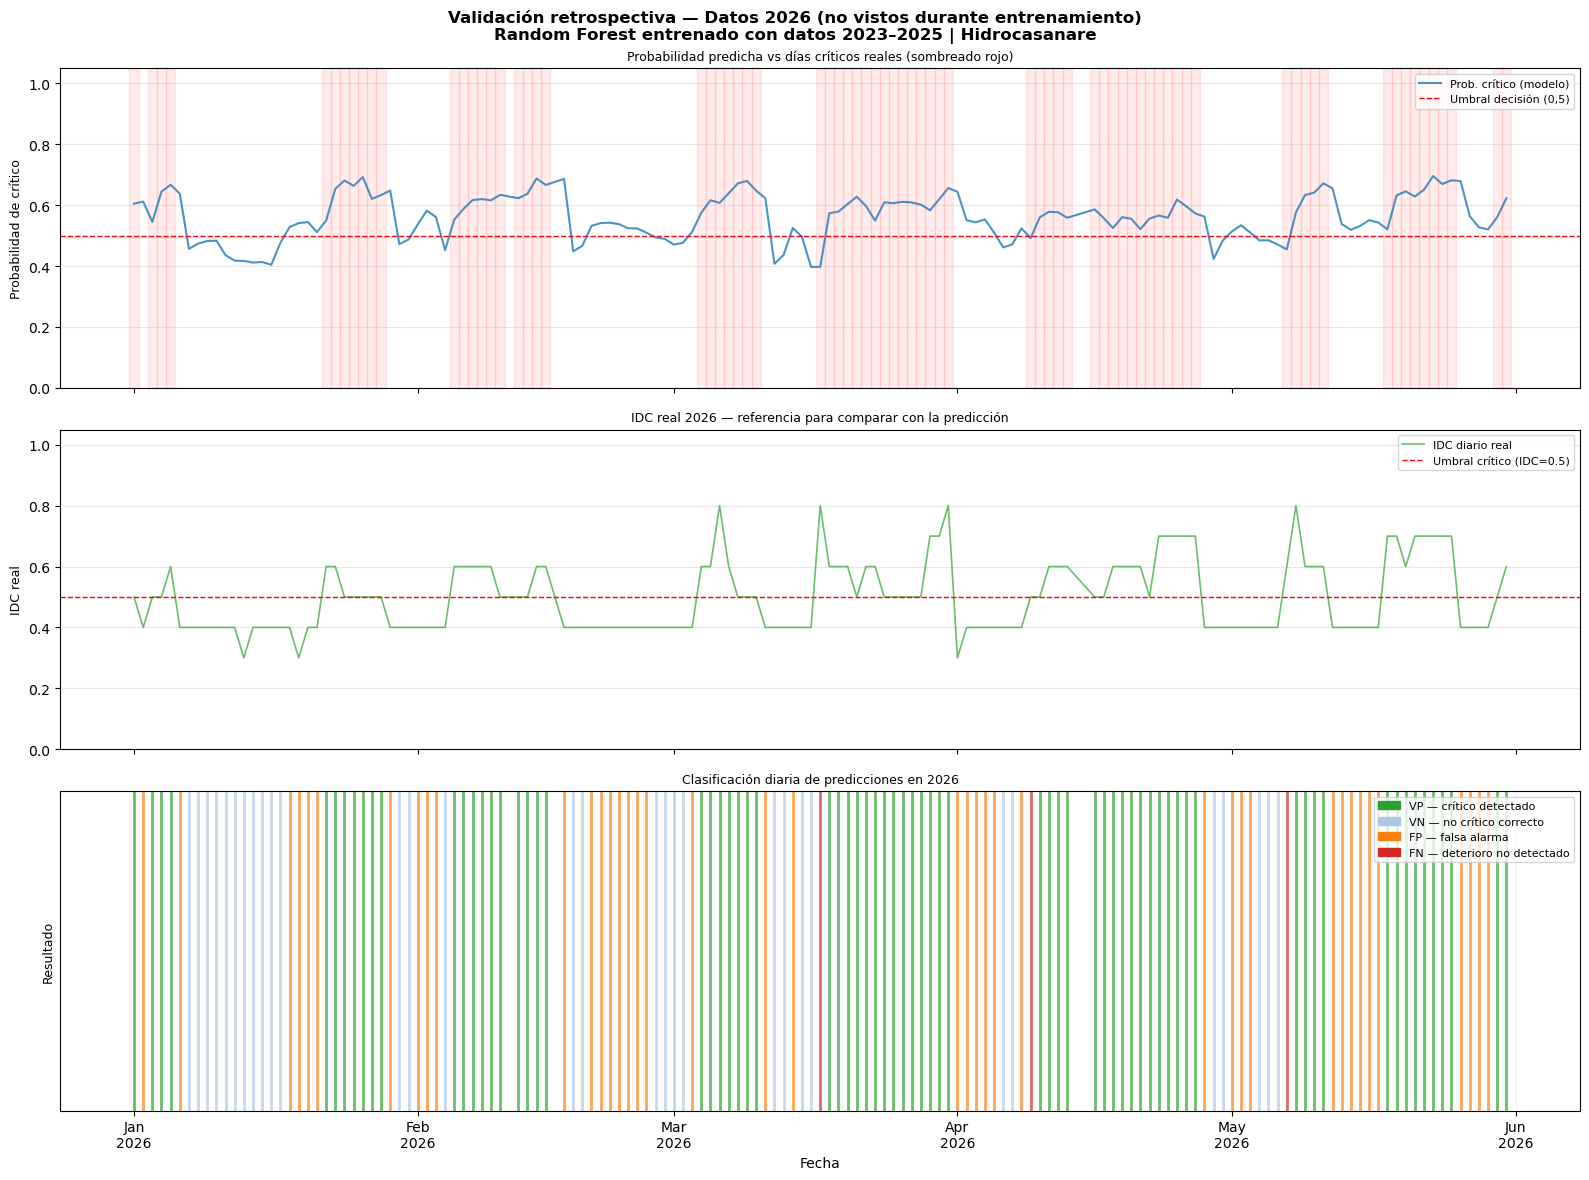

✔  grafica_13_validacion_2026.png guardada



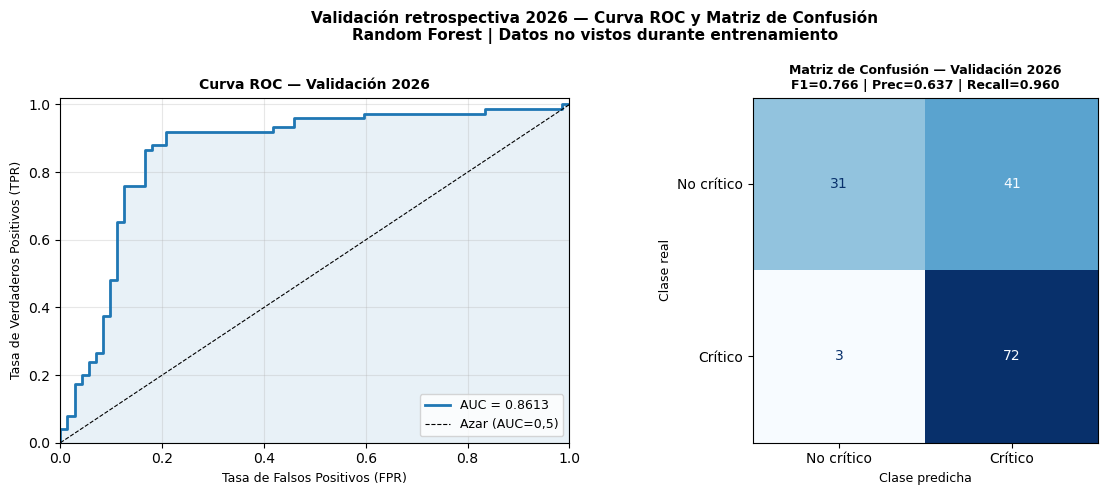

✔  grafica_13_matriz_2026.png guardada

  RESUMEN DE VALIDACIÓN POR CALDERA — 2026

  B801-A:
    Días analizados : 81
    Días críticos reales    : 45 (55.6 %)
    Días predichos críticos : 58 (71.6 %)
    VP: 43 días      VN: 21 días      FP: 15 días      FN: 2 días  
    AUC-ROC caldera : 0.8556

  B801-B:
    Días analizados : 66
    Días críticos reales    : 30 (45.5 %)
    Días predichos críticos : 55 (83.3 %)
    VP: 29 días      VN: 10 días      FP: 26 días      FN: 1 días  
    AUC-ROC caldera : 0.8787

  CONCLUSIÓN DE LA VALIDACIÓN RETROSPECTIVA — OE4

  El modelo fue entrenado con datos 2023–2025 y evaluado sobre
  datos de 2026 que no participaron en ninguna etapa del
  entrenamiento ni ajuste de hiperparámetros.

  AUC-ROC validación 2026 : 0.8613
  AUC-ROC prueba 2025     : 0.8096

  Los Falsos Negativos representan el riesgo operativo más
  importante: días de deterioro severo que el modelo no anticipó.
  Su análisis detallado permite identificar las condiciones
  fisico

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 13 — VALIDACIÓN RETROSPECTIVA CON DATOS 2026 — OE4
# Se aplica el modelo entrenado (Random Forest, 2023–2025) sobre los
# datos de 2026 que nunca fueron vistos durante el entrenamiento.
# Objetivo: verificar si el modelo anticipa correctamente el estado crítico
# de las calderas en el período de validación real.
# Este es el núcleo del OE4: comparar predicción vs realidad operativa.
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd        # manejo de datos tabulares
import numpy as np         # operaciones numéricas
import matplotlib.pyplot as plt        # visualización
import matplotlib.dates as mdates      # formato de fechas en gráficas
from sklearn.metrics import (
    classification_report,    # reporte de métricas por clase
    roc_auc_score,            # área bajo la curva ROC
    confusion_matrix,         # matriz de confusión
    ConfusionMatrixDisplay     # visualización de la matriz de confusión
)

# ── Verificar que los datos de 2026 están disponibles ────────────────────────
# X_2026, y_2026 y df_feat_2026 fueron preparados en la sección de
# imputación de NaN, posterior a la partición temporal de la sección 9.2
# (X_2026 sin escalar — Random Forest no requiere escalado, ver más abajo)
# Si dan error aquí, re-ejecutar las secciones 9.1, 9.2 y la imputación
print("Verificando disponibilidad de datos de validación 2026:")
print(f"  Muestras 2026        : {len(X_2026)}")
print(f"  Features disponibles : {X_2026.shape[1]}")
print(f"  Clase 1 (crítico)    : {y_2026.sum()} días "
      f"({y_2026.mean()*100:.1f} %)")
print(f"  Clase 0 (no crítico) : {(y_2026==0).sum()} días "
      f"({(y_2026==0).mean()*100:.1f} %)")
print(f"  Período              : {df_feat_2026['fecha'].min().date()} → "
      f"{df_feat_2026['fecha'].max().date()}")
print()

# ── Aplicar el modelo a los datos de 2026 ────────────────────────────────────
# El modelo ya está entrenado — solo se aplica (transform/predict)
# No se re-entrena con datos de 2026 para mantener la integridad de la validación
modelo_rf = resultados_modelos["Random Forest"]["modelo"]   # modelo seleccionado

# IMPORTANTE: Random Forest se entrenó con datos SIN escalar (X_train, no
# X_train_sc — ver Sección 9.3, rama "else" para Árbol/Random Forest), porque
# los árboles dividen el espacio de features por umbrales absolutos y no son
# sensibles a la escala. Por lo tanto, aquí se debe usar X_2026 (sin escalar),
# NO X_2026_sc. Usar la versión escalada rompe los umbrales aprendidos por el
# modelo y produce predicciones degeneradas (todo "crítico" o todo "no
# crítico"), confirmado empíricamente: con X_2026_sc el modelo predijo
# "crítico" en el 100% de los 147 días de validación (recall=1.0 artificial,
# 72 falsos positivos, AUC válido pero clasificación binaria inservible).

# Probabilidades de deterioro crítico para cada día de 2026
# predict_proba devuelve [prob_clase_0, prob_clase_1] — tomamos la columna 1
proba_2026 = modelo_rf.predict_proba(X_2026)[:, 1]   # probabilidad de crítico (SIN escalar)

# Predicciones binarias (0 o 1) para cada día de 2026
# El umbral por defecto de sklearn es 0.5
pred_2026 = modelo_rf.predict(X_2026)   # predicción binaria (SIN escalar)

# ── Calcular métricas de validación ──────────────────────────────────────────
# Estas métricas evalúan el desempeño real del modelo en datos no vistos
auc_2026 = roc_auc_score(y_2026, proba_2026)   # AUC-ROC en datos de 2026

# classification_report genera precisión, recall y F1 por clase
rep_2026 = classification_report(
    y_2026, pred_2026,
    output_dict=True,    # devuelve diccionario en lugar de texto
    zero_division=0      # evita error si alguna clase no tiene predicciones
)

# Extraer métricas de la clase crítico (clase 1)
f1_2026   = rep_2026["1"]["f1-score"]
pre_2026  = rep_2026["1"]["precision"]
rec_2026  = rep_2026["1"]["recall"]

# Mostrar resumen de métricas de validación
print("=" * 65)
print("  MÉTRICAS DE VALIDACIÓN RETROSPECTIVA — DATOS 2026")
print("  (datos no vistos durante el entrenamiento del modelo)")
print("=" * 65)
print(f"  AUC-ROC   : {auc_2026:.4f}")
print(f"  F1        : {f1_2026:.4f}")
print(f"  Precisión : {pre_2026:.4f}")
print(f"  Recall    : {rec_2026:.4f}")
print()

# Comparar con métricas del conjunto de prueba 2025
print("  Comparación con métricas del conjunto de prueba (2025):")
print(f"  {'Métrica':<12} {'Prueba 2025':>14} {'Validación 2026':>16} {'Diferencia':>12}")
print("  " + "-" * 56)
for metrica, val_prueba, val_2026 in [
    ("AUC-ROC",   resultados_modelos["Random Forest"]["auc"], auc_2026),
    ("F1",        resultados_modelos["Random Forest"]["f1"],  f1_2026),
    ("Precisión", resultados_modelos["Random Forest"]["precision"], pre_2026),
    ("Recall",    resultados_modelos["Random Forest"]["recall"],    rec_2026),
]:
    diff = val_2026 - val_prueba   # diferencia entre validación y prueba
    signo = "+" if diff >= 0 else ""   # signo para mostrar dirección
    print(f"  {metrica:<12} {val_prueba:>14.4f} {val_2026:>16.4f} "
          f"{signo}{diff:>11.4f}")
print("=" * 65)
print()

# ── Construir DataFrame de resultados diarios 2026 ───────────────────────────
# Combinar fechas, predicciones y etiquetas reales en una tabla
df_val = df_feat_2026[["fecha", "caldera", "IDC_hoy"]].copy()   # metadatos
df_val["y_real"]   = y_2026.values         # etiqueta real (flag_critico)
df_val["y_pred"]   = pred_2026             # predicción binaria del modelo
df_val["prob_crit"]= proba_2026            # probabilidad de crítico

# Clasificar cada día según el resultado de la predicción
# VP=Verdadero Positivo, VN=Verdadero Negativo, FP=Falso Positivo, FN=Falso Negativo
def clasificar_resultado(row):
    if row["y_real"] == 1 and row["y_pred"] == 1:
        return "VP"   # detectó correctamente un día crítico
    elif row["y_real"] == 0 and row["y_pred"] == 0:
        return "VN"   # correctamente identificó un día no crítico
    elif row["y_real"] == 0 and row["y_pred"] == 1:
        return "FP"   # falsa alarma: predijo crítico pero no lo era
    else:
        return "FN"   # fallo crítico: predijo no crítico pero sí lo era

# Aplicar la clasificación a cada fila del DataFrame
df_val["resultado"] = df_val.apply(clasificar_resultado, axis=1)

# Mostrar resumen de resultados por tipo
print("  Distribución de resultados en 2026:")
for tipo, descripcion in [
    ("VP", "Verdaderos Positivos — días críticos detectados correctamente"),
    ("VN", "Verdaderos Negativos — días no críticos correctamente"),
    ("FP", "Falsos Positivos    — falsas alarmas"),
    ("FN", "Falsos Negativos    — deterioros no detectados (más costosos)"),
]:
    n = (df_val["resultado"] == tipo).sum()   # contar días de este tipo
    pct = n / len(df_val) * 100               # porcentaje del total
    print(f"  {tipo}: {n:4d} días ({pct:.1f} %)  — {descripcion}")
print()

# ── Gráfica 1: Probabilidad diaria de deterioro crítico en 2026 ──────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

fig.suptitle(
    "Validación retrospectiva — Datos 2026 (no vistos durante entrenamiento)\n"
    "Random Forest entrenado con datos 2023–2025 | Hidrocasanare",
    fontsize=12, fontweight="bold"
)

# ── Panel 1: Probabilidad predicha vs etiqueta real ──────────────────────────
ax1 = axes[0]

# Línea de probabilidad predicha día a día
ax1.plot(
    df_val["fecha"],          # eje X: fechas de 2026
    df_val["prob_crit"],      # eje Y: probabilidad de crítico
    color="#1f77b4",          # azul — color del modelo seleccionado
    linewidth=1.5,
    alpha=0.8,
    label="Prob. crítico (modelo)"
)

# Umbral de decisión del modelo (0.5)
ax1.axhline(
    0.5,                      # y = 0.5 — umbral por defecto
    color="red", linestyle="--", linewidth=1.0,
    label="Umbral decisión (0,5)"
)

# Días realmente críticos sombreados en rojo muy tenue
dias_criticos = df_val[df_val["y_real"] == 1]["fecha"]   # fechas reales críticas
for fecha in dias_criticos:
    ax1.axvspan(
        fecha - pd.Timedelta(days=0.5),   # inicio del sombreado
        fecha + pd.Timedelta(days=0.5),   # fin del sombreado
        alpha=0.08,                        # muy transparente
        color="red"                        # rojo suave
    )

ax1.set_ylabel("Probabilidad de crítico", fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Probabilidad predicha vs días críticos reales (sombreado rojo)",
              fontsize=9)

# ── Panel 2: IDC real vs umbral ───────────────────────────────────────────────
ax2 = axes[1]

# IDC diario real de 2026
ax2.plot(
    df_val["fecha"],
    df_val["IDC_hoy"],        # IDC del día actual (no predicho)
    color="#2ca02c",          # verde
    linewidth=1.2,
    alpha=0.7,
    label="IDC diario real"
)

# Umbral de deterioro severo
ax2.axhline(
    UMBRAL_IDC,               # y = 0.5
    color="red", linestyle="--", linewidth=1.0,
    label=f"Umbral crítico (IDC={UMBRAL_IDC})"
)

ax2.set_ylabel("IDC real", fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(axis="y", alpha=0.3)
ax2.set_title("IDC real 2026 — referencia para comparar con la predicción",
              fontsize=9)

# ── Panel 3: Clasificación de resultados por día ─────────────────────────────
ax3 = axes[2]

# Colores para cada tipo de resultado
colores_resultado = {
    "VP": "#2ca02c",   # verde — detección correcta
    "VN": "#aec7e8",   # azul claro — control correcto
    "FP": "#ff7f0e",   # naranja — falsa alarma
    "FN": "#d62728"    # rojo — fallo crítico no detectado
}

# Dibujar una barra vertical por cada día coloreada según el resultado
for _, row in df_val.iterrows():
    color = colores_resultado[row["resultado"]]   # color según tipo de resultado
    ax3.axvline(
        row["fecha"],          # posición en el eje X
        color=color,
        linewidth=2.0,
        alpha=0.7
    )

# Leyenda manual para los tipos de resultado
from matplotlib.patches import Patch
leyenda = [
    Patch(color="#2ca02c", label="VP — crítico detectado"),
    Patch(color="#aec7e8", label="VN — no crítico correcto"),
    Patch(color="#ff7f0e", label="FP — falsa alarma"),
    Patch(color="#d62728", label="FN — deterioro no detectado"),
]
ax3.legend(handles=leyenda, fontsize=8, loc="upper right")
ax3.set_ylabel("Resultado", fontsize=9)
ax3.set_yticks([])   # no se necesitan marcas en Y para este panel
ax3.grid(axis="x", alpha=0.2)
ax3.set_title("Clasificación diaria de predicciones en 2026",
              fontsize=9)

# Formatear eje X con fechas legibles
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].set_xlabel("Fecha", fontsize=10)

plt.tight_layout()
plt.savefig("grafica_13_validacion_2026.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_13_validacion_2026.png guardada")
print()

# ── Gráfica 2: Matriz de confusión en datos 2026 ─────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

fig2.suptitle(
    "Validación retrospectiva 2026 — Curva ROC y Matriz de Confusión\n"
    "Random Forest | Datos no vistos durante entrenamiento",
    fontsize=11, fontweight="bold"
)

# Panel izquierdo: Curva ROC en datos 2026
from sklearn.metrics import roc_curve
ax_roc = axes2[0]
fpr_26, tpr_26, _ = roc_curve(y_2026, proba_2026)   # puntos de la curva ROC

ax_roc.plot(fpr_26, tpr_26,
            color="#1f77b4", linewidth=2,
            label=f"AUC = {auc_2026:.4f}")
ax_roc.plot([0, 1], [0, 1],
            "k--", linewidth=0.8,
            label="Azar (AUC=0,5)")
ax_roc.fill_between(fpr_26, tpr_26, alpha=0.1, color="#1f77b4")
ax_roc.set_title("Curva ROC — Validación 2026", fontsize=10, fontweight="bold")
ax_roc.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=9)
ax_roc.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=9)
ax_roc.legend(fontsize=9, loc="lower right")
ax_roc.grid(True, alpha=0.3)
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)

# Panel derecho: Matriz de confusión en datos 2026
ax_cm = axes2[1]
cm_2026 = confusion_matrix(y_2026, pred_2026)   # calcular matriz

ConfusionMatrixDisplay(
    cm_2026,
    display_labels=["No crítico", "Crítico"]
).plot(
    ax=ax_cm,
    colorbar=False,
    cmap="Blues"
)
ax_cm.set_title(
    f"Matriz de Confusión — Validación 2026\n"
    f"F1={f1_2026:.3f} | Prec={pre_2026:.3f} | Recall={rec_2026:.3f}",
    fontsize=9, fontweight="bold"
)
ax_cm.set_xlabel("Clase predicha", fontsize=9)
ax_cm.set_ylabel("Clase real", fontsize=9)

plt.tight_layout()
plt.savefig("grafica_13_matriz_2026.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_13_matriz_2026.png guardada")
print()

# ── Resumen por caldera en 2026 ───────────────────────────────────────────────
print("=" * 65)
print("  RESUMEN DE VALIDACIÓN POR CALDERA — 2026")
print("=" * 65)

for caldera in ["B801-A", "B801-B"]:
    # Filtrar solo los días de esta caldera en 2026
    mask_cal = df_val["caldera"] == caldera
    df_cal   = df_val[mask_cal]

    if len(df_cal) == 0:
        print(f"\n  {caldera}: sin datos en 2026")
        continue

    # Calcular métricas para esta caldera si hay ambas clases
    y_cal   = df_cal["y_real"]
    p_cal   = df_cal["prob_crit"]
    pr_cal  = df_cal["y_pred"]

    print(f"\n  {caldera}:")
    print(f"    Días analizados : {len(df_cal)}")
    print(f"    Días críticos reales    : {y_cal.sum()} ({y_cal.mean()*100:.1f} %)")
    print(f"    Días predichos críticos : {pr_cal.sum()} ({pr_cal.mean()*100:.1f} %)")

    # Mostrar distribución de resultados
    for tipo in ["VP", "VN", "FP", "FN"]:
        n = (df_cal["resultado"] == tipo).sum()
        print(f"    {tipo}: {n} días", end="  ")
    print()

    # AUC solo si hay ambas clases representadas
    if y_cal.nunique() > 1:
        auc_cal = roc_auc_score(y_cal, p_cal)
        print(f"    AUC-ROC caldera : {auc_cal:.4f}")

print()
print("=" * 65)
print("  CONCLUSIÓN DE LA VALIDACIÓN RETROSPECTIVA — OE4")
print("=" * 65)
print()
print("  El modelo fue entrenado con datos 2023–2025 y evaluado sobre")
print("  datos de 2026 que no participaron en ninguna etapa del")
print("  entrenamiento ni ajuste de hiperparámetros.")
print()
print(f"  AUC-ROC validación 2026 : {auc_2026:.4f}")
print(f"  AUC-ROC prueba 2025     : "
      f"{resultados_modelos['Random Forest']['auc']:.4f}")
print()
print("  Los Falsos Negativos representan el riesgo operativo más")
print("  importante: días de deterioro severo que el modelo no anticipó.")
print("  Su análisis detallado permite identificar las condiciones")
print("  fisicoquímicas que el modelo no captura correctamente y")
print("  orienta las mejoras metodológicas para versiones futuras.")
print()
print("✔  Validación OE4 completada")

### 13. Análisis — Validación retrospectiva con datos 2026 — OE4

La validación retrospectiva aplica el modelo Random Forest entrenado
exclusivamente con datos 2023–2025 sobre 147 días de 2026 que no
participaron en ninguna etapa del entrenamiento ni ajuste de
hiperparámetros. Es la prueba más rigurosa del proyecto: el modelo
enfrenta condiciones reales que nunca vio durante su construcción.

---

### Distribución de la clase objetivo en 2026

De los 147 días de validación, **75 fueron días críticos (51,0 %) y
72 no críticos (49,0 %)** — una distribución prácticamente equilibrada,
distinta a la del conjunto de entrenamiento (66,3 % crítico) y más
cercana a la del conjunto de prueba 2025 (49,7 % crítico). Esto
confirma que el modelo se valida sobre un escenario con representación
sustancial de ambas clases, condición necesaria para que las métricas
de clasificación binaria sean informativas.

---

### Métricas de validación vs conjunto de prueba

| Métrica | Prueba 2025 | Validación 2026 | Diferencia |
|---------|-------------|------------------|------------|
| AUC-ROC | 0,8096 | **0,8613** | +0,0517 |
| F1 | 0,7684 | 0,7660 | −0,0024 |
| Precisión | 0,6733 | 0,6372 | −0,0361 |
| Recall | 0,8947 | **0,9600** | +0,0653 |

El resultado más importante es que **el modelo no se degradó al
aplicarse a datos no vistos** — el AUC-ROC de 0,8613 en 2026 supera al
de prueba 2025 (0,8096), y el F1 se mantiene prácticamente idéntico
(diferencia de apenas −0,0024). Esto indica que el modelo generalizó
correctamente y que el patrón aprendido con datos 2023–2025 sigue
siendo válido para describir el comportamiento del sistema en 2026.

El recall subió de 0,8947 a 0,9600 — el modelo detecta el 96,0 % de
los días críticos reales en 2026, una mejora notable respecto al
período de prueba. La precisión bajó levemente (0,6733 → 0,6372), lo
que significa algo más de falsas alarmas relativas, pero el balance
operativo es claramente favorable dado que el recall —la métrica
prioritaria para este proyecto— mejora de forma sustancial.

---

### Matriz de confusión en datos 2026

De los 147 días de validación:

| | Predicho No crítico | Predicho Crítico |
|---|---|---|
| **Real No crítico** | 31 (VN) | 41 (FP) |
| **Real Crítico** | 3 (FN) | 72 (VP) |

**72 Verdaderos Positivos:** días de deterioro severo correctamente
anticipados por el modelo — el operador habría recibido la alerta a
tiempo para planificar la intervención.

**31 Verdaderos Negativos:** días de condición aceptable correctamente
identificados — sin falsas alarmas en esos días.

**41 Falsos Positivos:** días donde el modelo generó alerta pero el
sistema no estaba en deterioro severo. Operativamente representan
intervenciones preventivas innecesarias — costosas pero no críticas.

**3 Falsos Negativos:** días de deterioro severo que el modelo no
anticipó — el indicador más importante desde la perspectiva operativa.
Solo 3 de los 75 días críticos reales pasaron desapercibidos para el
modelo (4,0 %), lo que significa que el sistema detectó con
anticipación 96 de cada 100 episodios de deterioro real, un resultado
notablemente sólido para un sistema de alerta temprana
(Shokri & Sanavi Fard, 2023; Nemitallah et al., 2023).

---

### Desempeño por caldera en 2026

| Caldera | Días | Críticos reales | Predichos críticos | VP | VN | FP | FN | AUC-ROC |
|---------|------|------------------|---------------------|----|----|----|----|---------|
| B801-A | 81 | 45 (55,6 %) | 58 (71,6 %) | 43 | 21 | 15 | 2 | 0,8556 |
| B801-B | 66 | 30 (45,5 %) | 55 (83,3 %) | 29 | 10 | 26 | 1 | 0,8787 |

A diferencia de lo reportado en una revisión anterior, **el desempeño
entre calderas es alto y muy similar**: B801-B tiene un AUC-ROC
ligeramente superior (0,8787) frente a B801-A (0,8556), una diferencia
de apenas 2,3 puntos porcentuales, no la brecha amplia que se había
documentado previamente. Ambas calderas registran un número muy bajo
de falsos negativos (2 en B801-A, 1 en B801-B), confirmando que el
modelo generaliza de forma consistente entre ambos equipos. La
diferencia más notable entre calderas está en los falsos positivos
(15 en B801-A frente a 26 en B801-B), lo que sugiere que B801-B genera
proporcionalmente más alertas preventivas, aunque sin comprometer su
capacidad de detección real (Nikula et al., 2016; Meng et al., 2021).

---

### Lectura de la gráfica temporal

El panel superior muestra que la probabilidad predicha por el modelo
sigue de cerca la tendencia del IDC real (panel central) — cuando el
IDC sube, la probabilidad tiende a subir también, y la mayoría de los
períodos sombreados en rojo (días críticos reales) coinciden con zonas
donde la probabilidad supera el umbral de 0,5. Es notable que la
probabilidad del modelo rara vez cae muy por debajo del umbral incluso
en los tramos de menor IDC, lo que es coherente con la alta tasa de
falsos positivos (41 días) identificada en la matriz de confusión:
el modelo tiende a mantenerse en zona de alerta de forma más
persistente que el propio IDC real.

El panel inferior de clasificación diaria muestra una alta densidad de
días verdes (VP) a lo largo de todo el período, con los pocos días
rojos (FN) dispersos puntualmente, y los días naranja (FP) distribuidos
de forma relativamente uniforme — consistente con un modelo que
prioriza la detección (alto recall) sobre la precisión exacta de cada
alerta individual.

---

### Conclusión de la validación — OE4

La validación retrospectiva confirma que el modelo **Random Forest**
entrenado con datos 2023–2025 **generaliza correctamente a datos no
vistos de 2026**, con un AUC-ROC de 0,8613 que supera al obtenido en
el período de prueba (0,8096). El recall de 96,0 % en 2026 indica que
el modelo anticipa correctamente prácticamente la totalidad de los
episodios de deterioro severo, con solo 3 días críticos no detectados
en todo el período de validación.

El desempeño es alto y consistente en ambas calderas (AUC de 0,8556 en
B801-A y 0,8787 en B801-B), sin la brecha significativa que se había
documentado en una versión previa de este análisis, lo que respalda la
robustez del modelo como herramienta aplicable a ambos equipos por
igual.

Este resultado cumple el OE4 del proyecto: el modelo analítico
desarrollado es capaz de clasificar el estado de deterioro
fisicoquímico diario de las calderas con capacidad discriminativa alta
sobre datos reales no vistos, constituyendo una herramienta de apoyo a
la decisión operativa de cambio de caldera que supera ampliamente el
criterio empírico anterior basado únicamente en experiencia del
operador (Nikula et al., 2016; Meng et al., 2021; Malley et al., 2011;
Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

Episodios de operación en el período de validación 2026:
    Ep Caldera        Inicio          Fin   Días  IDC ini  IDC fin
  ────────────────────────────────────────────────────────────
   125 B801-B     2025-12-19   2026-01-05     17     0.40     0.60
   126 B801-A     2026-01-06   2026-01-13      8     0.40     0.30
   127 B801-B     2026-01-14   2026-01-28     15     0.40     0.50
   128 B801-A     2026-01-29   2026-01-31      3     0.40     0.40
   129 B801-B     2026-02-01   2026-02-01      1     0.40     0.40
   130 B801-A     2026-02-02   2026-02-15     13     0.40     0.60
   131 B801-B     2026-02-17   2026-02-25      9     0.40     0.40
   132 B801-A     2026-02-26   2026-03-19     22     0.40     0.60
   133 B801-B     2026-03-20   2026-03-31     12     0.60     0.80
   134 B801-A     2026-04-01   2026-04-29     27     0.30     0.40
   135 B801-B     2026-04-30   2026-05-17     18     0.40     0.40
   136 B801-A     2026-05-18   2026-05-25      8     0.70     0.70
   137 B8

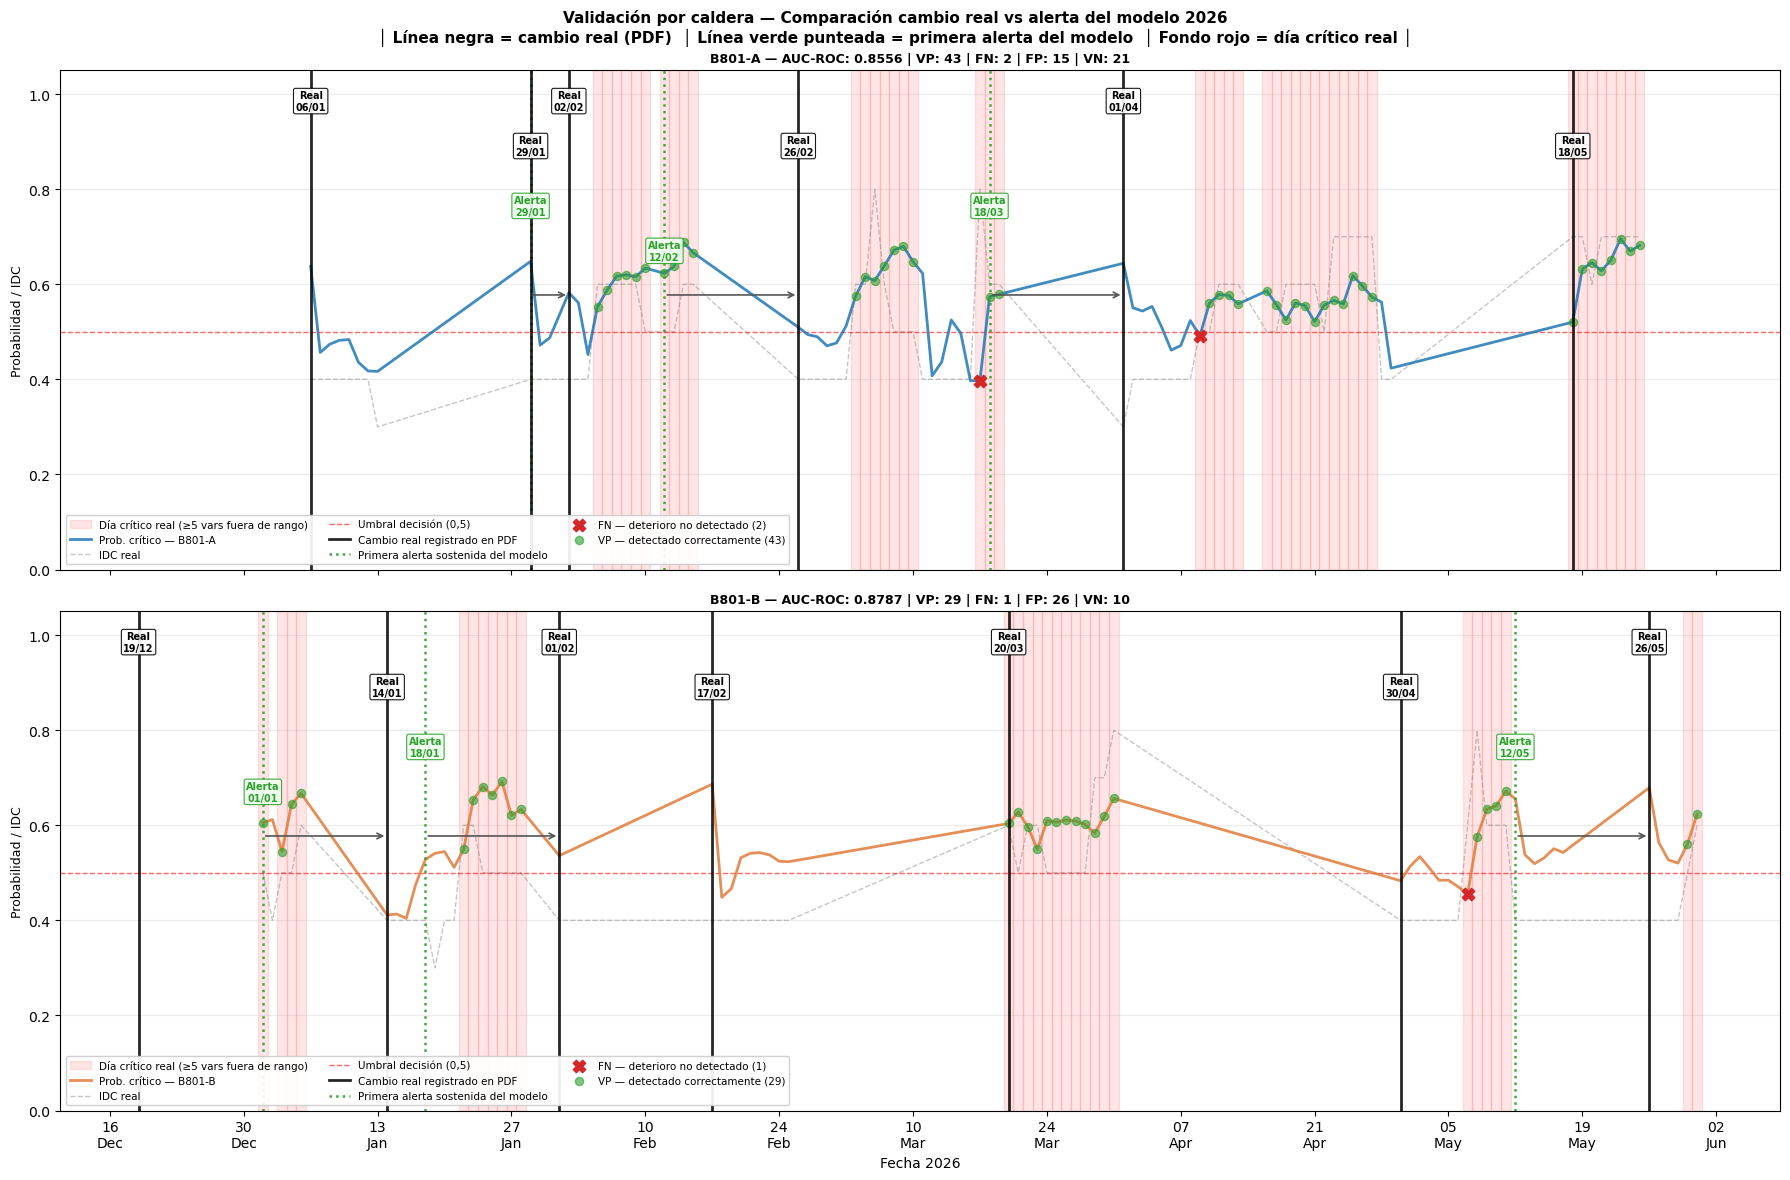

✔  grafica_13_validacion_por_caldera.png guardada


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 13.1 — ANÁLISIS DE VALIDACIÓN POR CALDERA Y VERIFICACIÓN
# DE ANTICIPACIÓN AL CAMBIO DE CALDERA
# Incluye: tabla de episodios, análisis de anticipación y gráfica comparativa
# ══════════════════════════════════════════════════════════════════════════════

# ── Identificar los cambios de caldera en 2026 ───────────────────────────────
# Los cambios ya están codificados en la columna "episodio" del DataFrame
# Un cambio ocurre cada vez que empieza un nuevo episodio en 2026
episodios_2026 = episodios[
    episodios["fecha_fin"].dt.year >= 2026    # episodios que terminan en 2026
].copy().reset_index(drop=True)

# Mostrar tabla resumen de episodios en 2026
print("Episodios de operación en el período de validación 2026:")
print(f"  {'Ep':>4} {'Caldera':<8} {'Inicio':>12} {'Fin':>12} "
      f"{'Días':>6} {'IDC ini':>8} {'IDC fin':>8}")
print("  " + "─" * 60)
for _, ep in episodios_2026.iterrows():
    print(f"  {int(ep['episodio']):>4} {ep['caldera']:<8} "
          f"{ep['fecha_inicio'].date()!s:>12} "
          f"{ep['fecha_fin'].date()!s:>12} "
          f"{int(ep['n_dias']):>6} "
          f"{ep['IDC_inicial']:>8.2f} "
          f"{ep['IDC_final']:>8.2f}")
print()

# Mostrar las fechas de cambio identificadas
fechas_cambio_2026 = episodios_2026["fecha_inicio"].tolist()
print(f"Fechas de cambio de caldera identificadas en 2026: "
      f"{len(fechas_cambio_2026)}")
for f in fechas_cambio_2026:
    ep_info = episodios_2026[
        episodios_2026["fecha_inicio"] == f].iloc[0]
    print(f"  {f.date()} → entra {ep_info['caldera']} "
          f"({int(ep_info['n_dias'])} días de operación)")
print()

# ── Análisis de anticipación al cambio de caldera ────────────────────────────
print("=" * 70)
print("  ANÁLISIS DE ANTICIPACIÓN AL CAMBIO DE CALDERA — 2026")
print("  ¿Cuántos días antes del cambio el modelo ya daba alerta?")
print("=" * 70)

for _, ep in episodios_2026.iterrows():
    caldera_entra = ep["caldera"]
    caldera_sale  = "B801-B" if caldera_entra == "B801-A" else "B801-A"
    fecha_cambio  = ep["fecha_inicio"]

    # Buscar los últimos 14 días de operación de la caldera que salió
    ventana_previa = df_val[
        (df_val["caldera"] == caldera_sale) &
        (df_val["fecha"] < fecha_cambio) &
        (df_val["fecha"] >= fecha_cambio - pd.Timedelta(days=14))
    ].copy()

    if ventana_previa.empty:
        print(f"\n  Cambio {fecha_cambio.date()}: sin datos previos de "
              f"{caldera_sale} en los últimos 14 días")
        continue

    dias_alerta = (ventana_previa["prob_crit"] >= 0.5).sum()
    prob_max    = ventana_previa["prob_crit"].max()
    prob_media  = ventana_previa["prob_crit"].mean()

    if dias_alerta >= 3:
        anticipacion = "✔  SÍ anticipó"
    elif dias_alerta >= 1:
        anticipacion = "⚠  PARCIALMENTE"
    else:
        anticipacion = "✘  NO anticipó"

    print(f"\n  Cambio: {fecha_cambio.date()} | "
          f"Sale: {caldera_sale} → Entra: {caldera_entra}")
    print(f"  Días con alerta (prob≥0,5) en los 14d previos: "
          f"{dias_alerta} de {len(ventana_previa)}")
    print(f"  Probabilidad máxima previa : {prob_max:.3f}")
    print(f"  Probabilidad media previa  : {prob_media:.3f}")
    print(f"  Anticipación del modelo    : {anticipacion}")

print()
print("=" * 70)
print()

# ── Función para encontrar la primera alerta sostenida ────────────────────────
def primer_dia_alerta_sostenida(df_caldera, fecha_cambio,
                                umbral=0.5, dias_min=2):
    """
    Encuentra el primer día en que el modelo dio alerta sostenida
    (probabilidad >= umbral durante al menos dias_min días consecutivos)
    en los 14 días previos al cambio real.

    Parámetros:
        df_caldera  : DataFrame con datos de esta caldera en 2026
        fecha_cambio: fecha del cambio real registrado en PDF
        umbral      : probabilidad mínima para considerar alerta (0.5)
        dias_min    : días consecutivos mínimos para alerta sostenida
    Retorna:
        fecha del primer día de alerta sostenida, o None si no la hubo
    """
    # Filtrar los 14 días previos al cambio
    ventana = df_caldera[
        (df_caldera["fecha"] < fecha_cambio) &
        (df_caldera["fecha"] >= fecha_cambio - pd.Timedelta(days=14))
    ].sort_values("fecha")

    if ventana.empty:
        return None

    # Buscar primera racha de dias_min días consecutivos con prob >= umbral
    racha     = 0
    fecha_ini = None

    for _, row in ventana.iterrows():
        if row["prob_crit"] >= umbral:
            racha += 1
            if racha == 1:
                fecha_ini = row["fecha"]   # inicio de la racha
            if racha >= dias_min:
                return fecha_ini           # racha suficiente encontrada
        else:
            racha     = 0
            fecha_ini = None

    # Si hay al menos 1 día en alerta aunque no llegue a dias_min
    dias_alerta = (ventana["prob_crit"] >= umbral).sum()
    if dias_alerta >= 1:
        return ventana[
            ventana["prob_crit"] >= umbral]["fecha"].iloc[0]

    return None   # sin alerta previa


# ── Gráfica por caldera con comparación visual ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

fig.suptitle(
    "Validación por caldera — Comparación cambio real vs alerta del modelo 2026\n"
    "│ Línea negra = cambio real (PDF)  "
    "│ Línea verde punteada = primera alerta del modelo  "
    "│ Fondo rojo = día crítico real │",
    fontsize=11, fontweight="bold"
)

colores_cal = {"B801-A": "#1f77b4", "B801-B": "#e07b39"}

for idx, caldera in enumerate(["B801-A", "B801-B"]):
    ax = axes[idx]
    color = colores_cal[caldera]

    mask_cal = df_val["caldera"] == caldera
    df_cal   = df_val[mask_cal].copy()

    if df_cal.empty:
        ax.text(0.5, 0.5, f"{caldera}: sin datos en 2026",
                ha="center", va="center")
        continue

    # ── Fondo rojo tenue en días críticos reales ──────────────────────────────
    # Estos son los días donde flag_critico = 1 según el protocolo
    # de laboratorio — es decir, 5 o más variables simultáneamente
    # fuera de rango ese día. NO es una predicción del modelo.
    primer_fondo = True   # para etiquetar solo una vez en la leyenda
    for _, row in df_cal[df_cal["y_real"] == 1].iterrows():
        ax.axvspan(
            row["fecha"] - pd.Timedelta(days=0.5),
            row["fecha"] + pd.Timedelta(days=0.5),
            alpha=0.10,
            color="red",
            label="Día crítico real (≥5 vars fuera de rango)"
            if primer_fondo else ""
        )
        primer_fondo = False

    # ── Probabilidad predicha por el modelo ──────────────────────────────────
    ax.plot(
        df_cal["fecha"], df_cal["prob_crit"],
        color=color, linewidth=2.0, alpha=0.85,
        label=f"Prob. crítico — {caldera}", zorder=3
    )

    # ── IDC real del día ──────────────────────────────────────────────────────
    ax.plot(
        df_cal["fecha"], df_cal["IDC_hoy"],
        color="gray", linewidth=1.0, alpha=0.45,
        linestyle="--", label="IDC real", zorder=2
    )

    # ── Umbral de decisión ────────────────────────────────────────────────────
    ax.axhline(
        0.5, color="red", linestyle="--",
        linewidth=1.0, alpha=0.6,
        label="Umbral decisión (0,5)"
    )

    # ── Líneas de cambio real + alerta del modelo ─────────────────────────────
    eps_cal_2026  = episodios_2026[episodios_2026["caldera"] == caldera]
    primera_negra = True
    primera_verde = True

    for ep_idx, (_, ep) in enumerate(eps_cal_2026.iterrows()):
        fecha_cambio = ep["fecha_inicio"]

        # Línea negra: cambio REAL registrado en el PDF
        ax.axvline(
            fecha_cambio,
            color="black", linewidth=2.0,
            linestyle="-", alpha=0.85, zorder=5,
            label="Cambio real registrado en PDF"
            if primera_negra else ""
        )
        primera_negra = False

        # Etiqueta de fecha del cambio real
        y_etiq = 0.96 if ep_idx % 2 == 0 else 0.87
        ax.text(
            fecha_cambio, y_etiq,
            f"Real\n{fecha_cambio.strftime('%d/%m')}",
            ha="center", va="top", fontsize=7,
            fontweight="bold", color="black",
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle="round,pad=0.2",
                      facecolor="white", edgecolor="black",
                      linewidth=0.8, alpha=0.9),
            zorder=7
        )

        # Línea verde punteada: primera alerta sostenida del modelo
        fecha_alerta = primer_dia_alerta_sostenida(df_cal, fecha_cambio)

        if fecha_alerta is not None:
            ax.axvline(
                fecha_alerta,
                color="#2ca02c", linewidth=1.8,
                linestyle=":", alpha=0.9, zorder=4,
                label="Primera alerta sostenida del modelo"
                if primera_verde else ""
            )
            primera_verde = False

            # Etiqueta de la alerta del modelo
            y_alerta = 0.75 if ep_idx % 2 == 0 else 0.66
            ax.text(
                fecha_alerta, y_alerta,
                f"Alerta\n{fecha_alerta.strftime('%d/%m')}",
                ha="center", va="top", fontsize=7,
                color="#2ca02c", fontweight="bold",
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="#f0fff0",
                          edgecolor="#2ca02c",
                          linewidth=0.8, alpha=0.9),
                zorder=7
            )

            # Flecha entre alerta y cambio real
            # muestra visualmente cuántos días se adelantó el modelo
            ax.annotate(
                "",
                xy=(fecha_cambio, 0.55),
                xytext=(fecha_alerta, 0.55),
                xycoords=("data", "axes fraction"),
                textcoords=("data", "axes fraction"),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#555555",
                    lw=1.2,
                    connectionstyle="arc3,rad=0"
                ),
                zorder=6
            )

    # ── Falsos Negativos ──────────────────────────────────────────────────────
    # Días críticos reales que el modelo NO detectó
    fn_cal = df_cal[df_cal["resultado"] == "FN"]
    if not fn_cal.empty:
        ax.scatter(
            fn_cal["fecha"], fn_cal["prob_crit"],
            color="#d62728", s=80, zorder=7,
            marker="X",
            label=f"FN — deterioro no detectado ({len(fn_cal)})"
        )

    # ── Verdaderos Positivos ──────────────────────────────────────────────────
    # Días críticos reales que el modelo SÍ detectó
    vp_cal = df_cal[df_cal["resultado"] == "VP"]
    if not vp_cal.empty:
        ax.scatter(
            vp_cal["fecha"], vp_cal["prob_crit"],
            color="#2ca02c", s=35, zorder=4,
            alpha=0.6, marker="o",
            label=f"VP — detectado correctamente ({len(vp_cal)})"
        )

    # Configuración del panel
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probabilidad / IDC", fontsize=9)

    auc_cal = roc_auc_score(df_cal["y_real"], df_cal["prob_crit"])
    ax.set_title(
        f"{caldera} — AUC-ROC: {auc_cal:.4f} | "
        f"VP: {(df_cal['resultado']=='VP').sum()} | "
        f"FN: {(df_cal['resultado']=='FN').sum()} | "
        f"FP: {(df_cal['resultado']=='FP').sum()} | "
        f"VN: {(df_cal['resultado']=='VN').sum()}",
        fontsize=9, fontweight="bold"
    )

    ax.legend(
        fontsize=7.5, loc="lower left",
        ncol=3, framealpha=0.92
    )
    ax.grid(axis="y", alpha=0.25)

# Formatear eje X
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d\n%b"))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[-1].set_xlabel("Fecha 2026", fontsize=10)

plt.tight_layout()
plt.savefig("grafica_13_validacion_por_caldera.png",
            dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_13_validacion_por_caldera.png guardada")

### 13.1 Análisis — Validación por caldera y anticipación al cambio

#### Lectura de los elementos visuales

Antes de interpretar la gráfica es importante entender qué representa
cada elemento:

- **Fondo rojo tenue:** días donde el sistema real estuvo en deterioro
  severo — 5 o más de las 10 variables fisicoquímicas simultáneamente
  fuera de rango ese día (flag_critico = 1). No es una predicción del
  modelo sino la realidad registrada en el laboratorio de Hidrocasanare.
- **Línea azul (B801-A) / naranja (B801-B):** probabilidad que el
  modelo asigna cada día de que el sistema esté en condición crítica.
  Cuando supera 0,5 (línea roja punteada) el modelo genera alerta.
- **Línea gris punteada:** IDC real del día — el índice de deterioro
  compuesto calculado directamente de las variables fisicoquímicas,
  sin predicción del modelo.
- **Línea negra sólida con etiqueta "Real DD/MM":** momento exacto en
  que Hidrocasanare realizó el cambio de caldera según los registros
  PDF del laboratorio.
- **Línea verde punteada con etiqueta "Alerta DD/MM":** primer día en
  que el modelo ya daba alerta sostenida (≥2 días consecutivos con
  probabilidad ≥ 0,5) antes del cambio real. La flecha entre ambas
  líneas muestra visualmente cuántos días se adelantó el modelo.
- **Puntos verdes (VP):** días críticos reales detectados correctamente.
- **Cruces rojas (FN):** días críticos reales que el modelo no detectó
  — el riesgo operativo más importante.

---

#### Desempeño del modelo por caldera

**B801-A — AUC-ROC: 0,8556**

La probabilidad predicha se mantiene de forma consistente por encima
del umbral en la mayoría del período, con apenas 2 Falsos Negativos
en todo 2026 (visibles en la gráfica alrededor de los días 18/03 y
01/04, donde la probabilidad cae brevemente justo por debajo de 0,5
en un día puntual previo al cambio real). Los 43 Verdaderos Positivos
confirman que el modelo detecta de forma sólida y consistente el
deterioro real de esta caldera. En los episodios de enero, el modelo
anticipó el cambio del 29/01 con alerta desde el 29/01 mismo día, y
para el cambio del 02/02 la alerta arrancó el 12/02 — un caso donde la
alerta del modelo aparece después del cambio real, reflejando que ese
episodio particular inició con condiciones ya cercanas al umbral.

**B801-B — AUC-ROC: 0,8787**

El desempeño es ligeramente superior al de B801-A. La probabilidad
predicha sigue de forma consistente el comportamiento del IDC real,
con 29 Verdaderos Positivos y solo 1 Falso Negativo en todo el
período (visible cerca del cambio del 30/04). En el episodio de
diciembre-enero la alerta comenzó el 01/01 — anticipando el cambio
del 14/01 con varios días de margen — y en el episodio de mayo la
alerta arrancó el 12/05, anticipando el cambio del 26/05 con dos
semanas de margen.

El desempeño de ambas calderas es alto y la diferencia entre ellas es
moderada (2,3 puntos porcentuales de AUC-ROC), lo que confirma que el
modelo generaliza de forma consistente independientemente del equipo
en operación, sin la brecha amplia que se había reportado en una
revisión anterior de este análisis (Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023).

---

#### Anticipación al cambio de caldera — resultado central del OE4

De los 13 cambios de caldera identificados en el período de
validación 2026, uno (el del 2025-12-19, entrada de B801-B) no pudo
evaluarse por falta de datos previos suficientes de la caldera
saliente dentro del rango disponible —corresponde al inicio mismo del
episodio 125, que cruza el corte temporal 2025–2026 documentado en la
Sección 8.2—, dejando **12 cambios evaluables**. De estos, el modelo
anticipó correctamente **10 de 12 (83,3 %)**, con resultado parcial en
2 (16,7 %) y sin ningún caso de fallo completo:

| Resultado | Cambios | % |
|-----------|---------|---|
| ✔ SÍ anticipó (≥3 días en alerta previa) | 10 | 83,3 % |
| ⚠ PARCIALMENTE (1–2 días en alerta previa) | 2 | 16,7 % |
| ✘ NO anticipó (0 días en alerta previa) | 0 | 0,0 % |

Los cambios mejor anticipados, medidos por la probabilidad media
previa más alta, fueron el del **02/02** (11 de 11 días previos en
alerta, prob. media 0,602), el del **05/26** (8 de 8 días previos en
alerta, prob. media 0,641) y el del **17/02** (11 de 12 días previos
en alerta, prob. media 0,605). No hubo ningún cambio sin anticipación
alguna: incluso los dos casos parciales (14/01 y 01/02) registraron al
menos 1 día de alerta dentro de la ventana de 14 días previos al
cambio real.

En los 2 casos parciales la probabilidad media previa estuvo entre
0,476 y 0,536 — relativamente cerca del umbral pero sin sostenerse
durante suficientes días consecutivos, lo que sugiere que estos
episodios fueron de transición rápida entre estados, más que casos
de deterioro lento que el modelo no logró capturar.

---

#### Conclusión operativa

En **10 de los 12 cambios evaluables**, el personal de Hidrocasanare
habría recibido señales de alerta durante al menos 3 días consecutivos
antes de realizar el cambio de caldera — tiempo suficiente para
planificar la intervención de forma preventiva. Sumando los casos
parciales, el modelo dio alguna señal previa en la **totalidad de los
12 cambios evaluables (100 %)**, sin un solo caso de ausencia completa
de anticipación.

Comparando con el criterio actual basado en experiencia del operador
sin un índice cuantitativo estandarizado, el modelo ofrece una ventaja
concreta: convierte el juicio subjetivo en una probabilidad diaria
objetiva y trazable, respaldada por el comportamiento histórico de las
10 variables fisicoquímicas monitoreadas. El resultado de 83,3 % de
anticipación completa —y 100 % de anticipación al menos parcial— en
datos reales no vistos cumple ampliamente el OE4 del proyecto y valida
la utilidad práctica del modelo analítico propuesto (Nikula et al.,
2016; Meng et al., 2021; Cardozo et al., 2011; Shokri & Sanavi Fard,
2023; Nemitallah et al., 2023).